This is the code used to analyse simulations for the modelling paper.

In [22]:
import numpy as np
from matplotlib import pyplot as plt
from numba import njit, prange
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib as mpl
import pandas as pd
from sklearn.multiclass import OneVsRestClassifier as classifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import MultiLabelBinarizer, LabelBinarizer
from sklearn.metrics import log_loss, roc_curve
import optuna
from scipy.stats import pearsonr, ranksums, false_discovery_control, linregress, ttest_1samp
from sklearn.cluster import AgglomerativeClustering as clustering
from scipy.interpolate import CubicSpline as spl
import seaborn as sns
from lifelines import CoxPHFitter
import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

base_filepath = "/Users/44749/Documents/PhD_work/chapter_2_sims/"
stats_filepath = "/Users/44749/Documents/PhD_work/datasets_for_analysis/"
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 15


Establish the range of selection strengths used to test models.

In [23]:
max_sel = 0.1
gran=100
repeats = 20 #bear in mind each of these will be repeated, in simulations, 5 times-- so if we want 100 repeats we only need 20 here

base_sel = np.linspace(0, 0.1, num=gran+1)

selections = []

for sel in base_sel:
    for r in range(repeats):
        selections.append(sel)
    sel += gran

#remember each is repeated for 5 simulations within that-- because of the batching

Plot the variation of summary statistics with selection strength for all models.

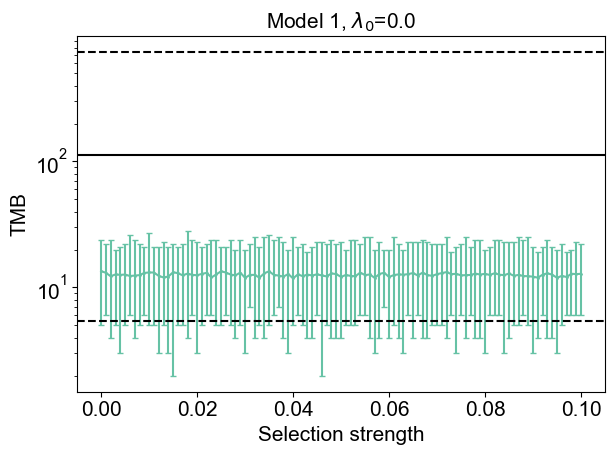

<Figure size 640x480 with 0 Axes>

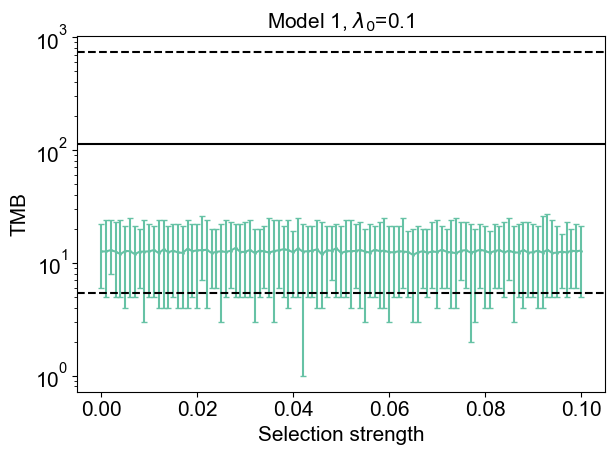

<Figure size 640x480 with 0 Axes>

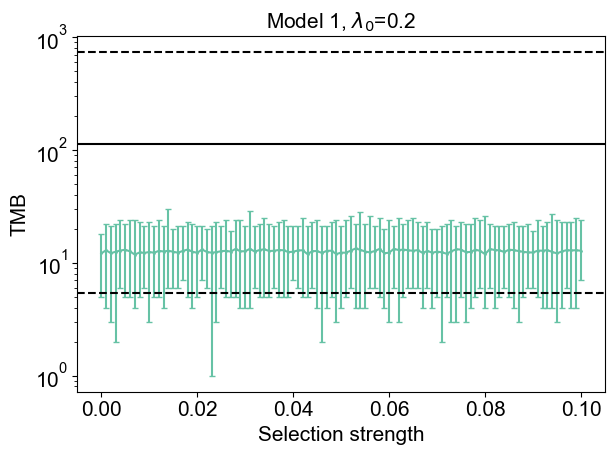

<Figure size 640x480 with 0 Axes>

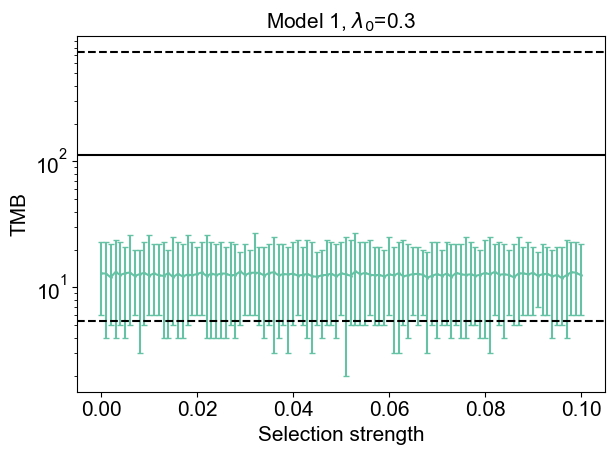

<Figure size 640x480 with 0 Axes>

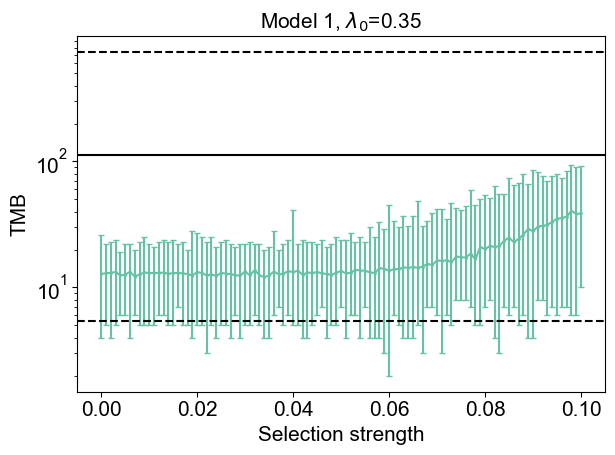

<Figure size 640x480 with 0 Axes>

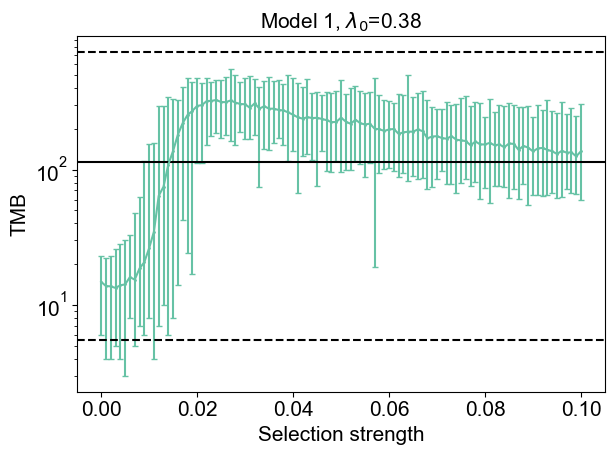

<Figure size 640x480 with 0 Axes>

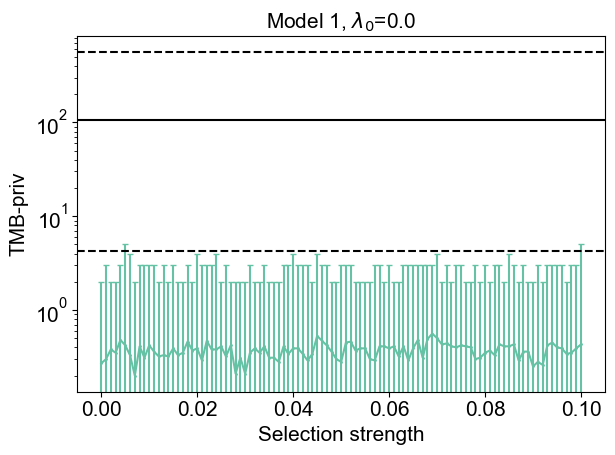

<Figure size 640x480 with 0 Axes>

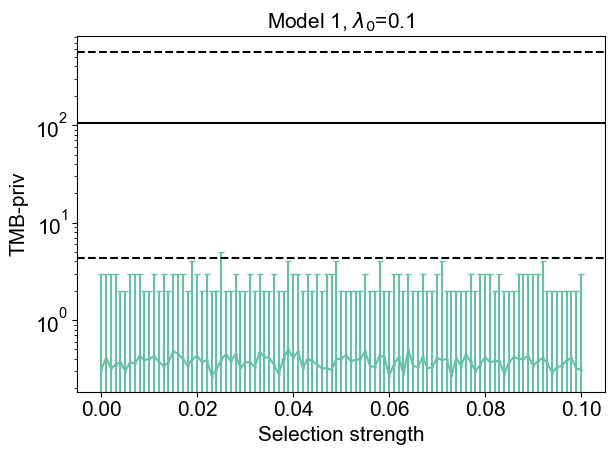

<Figure size 640x480 with 0 Axes>

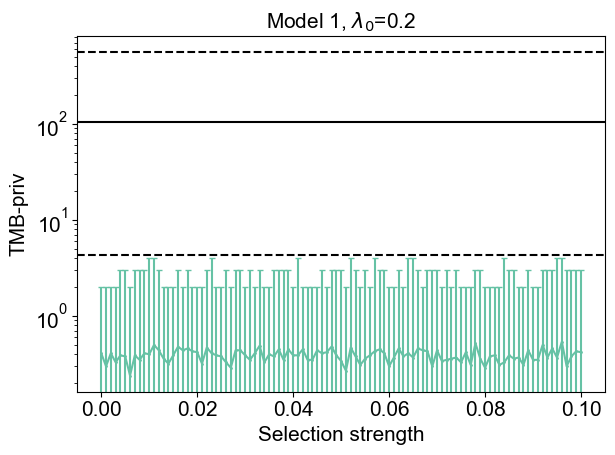

<Figure size 640x480 with 0 Axes>

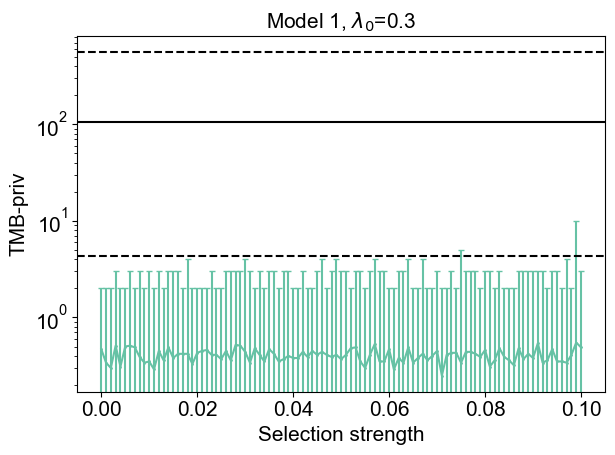

<Figure size 640x480 with 0 Axes>

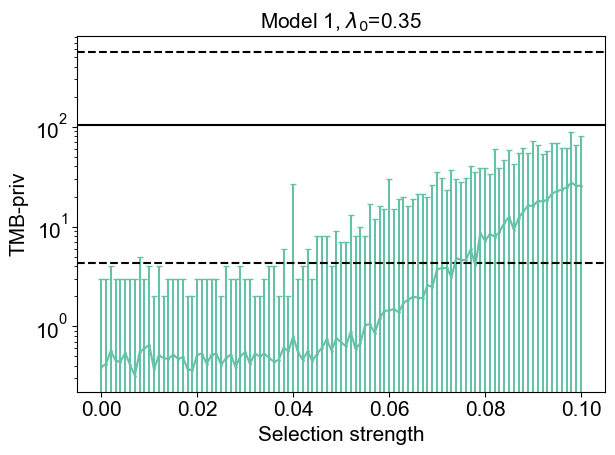

<Figure size 640x480 with 0 Axes>

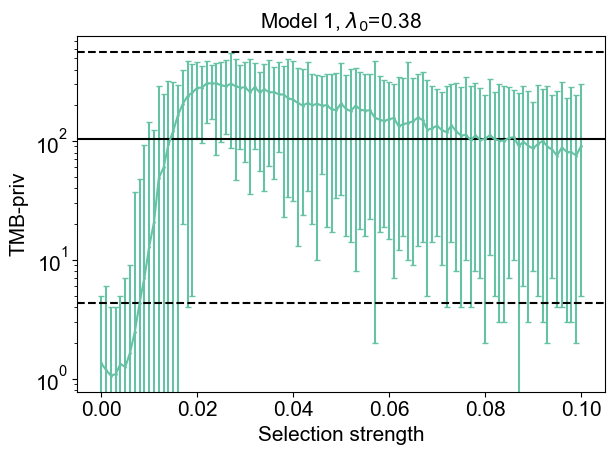

<Figure size 640x480 with 0 Axes>

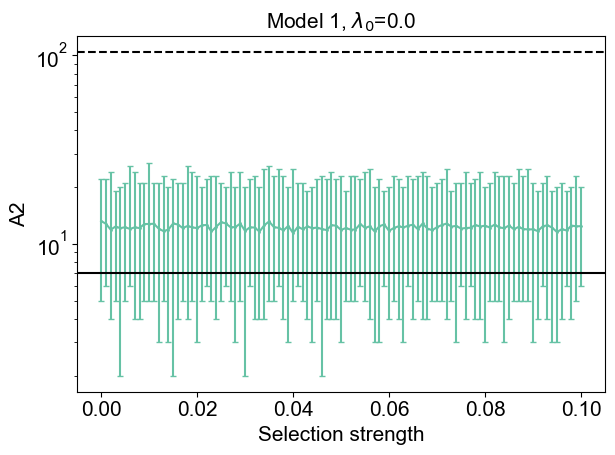

<Figure size 640x480 with 0 Axes>

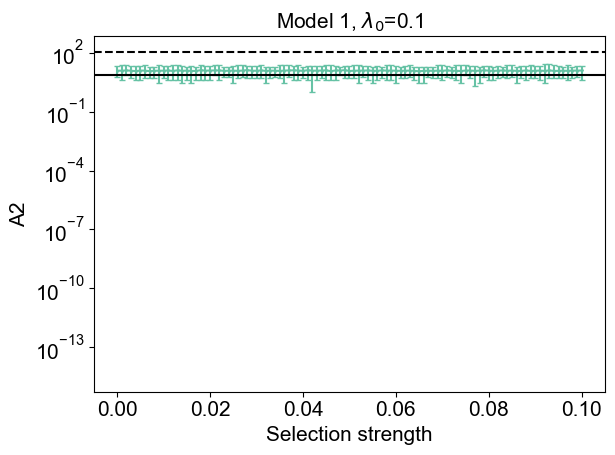

<Figure size 640x480 with 0 Axes>

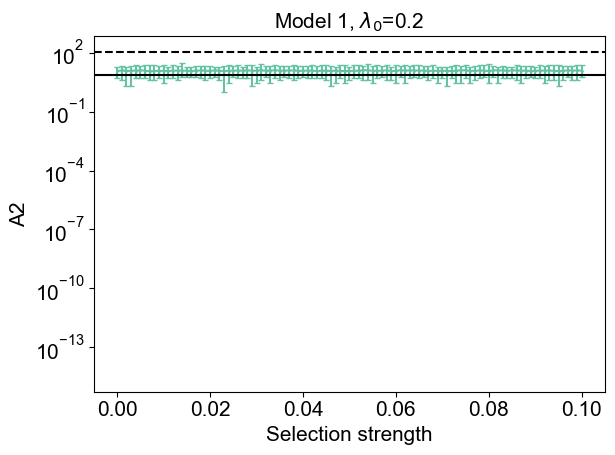

<Figure size 640x480 with 0 Axes>

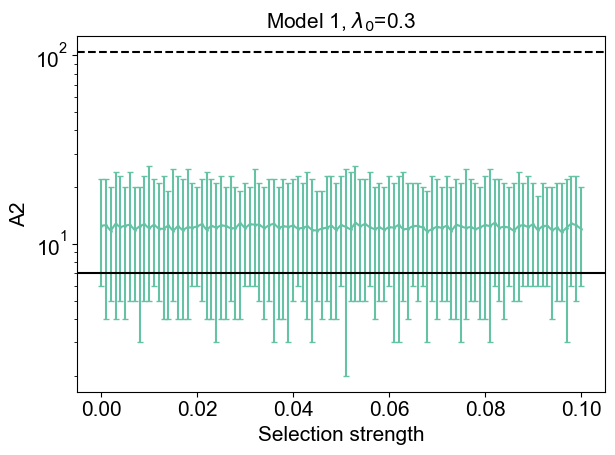

<Figure size 640x480 with 0 Axes>

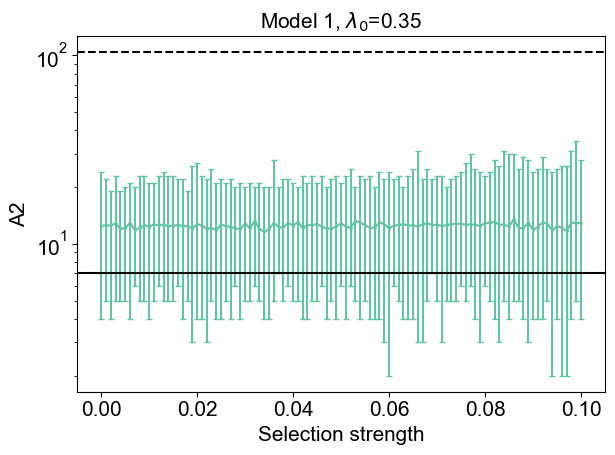

<Figure size 640x480 with 0 Axes>

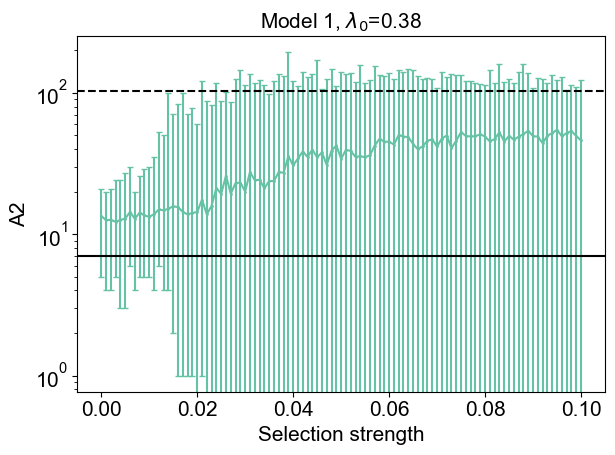

<Figure size 640x480 with 0 Axes>

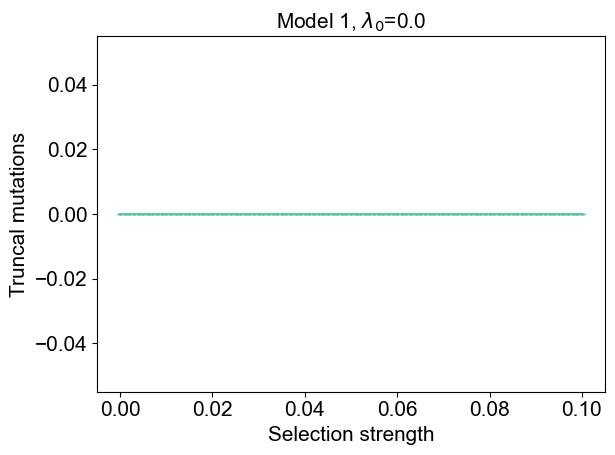

<Figure size 640x480 with 0 Axes>

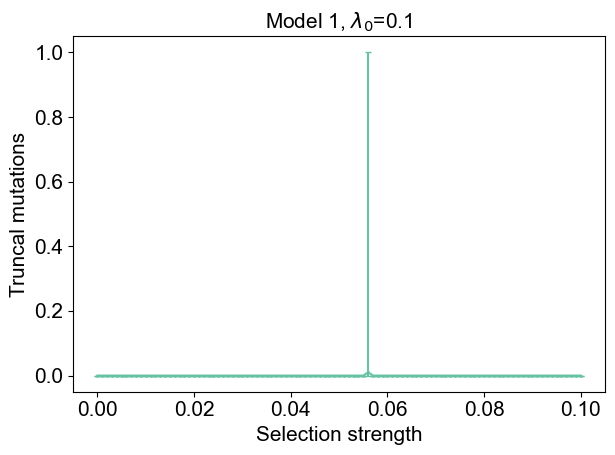

<Figure size 640x480 with 0 Axes>

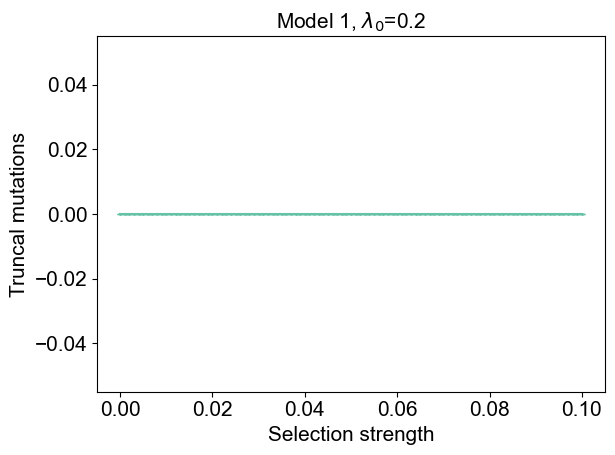

<Figure size 640x480 with 0 Axes>

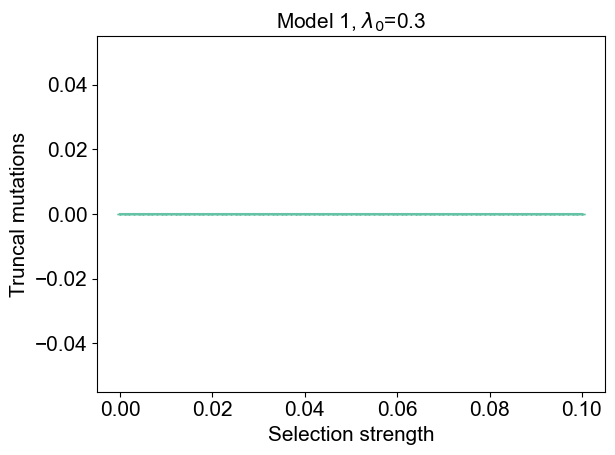

<Figure size 640x480 with 0 Axes>

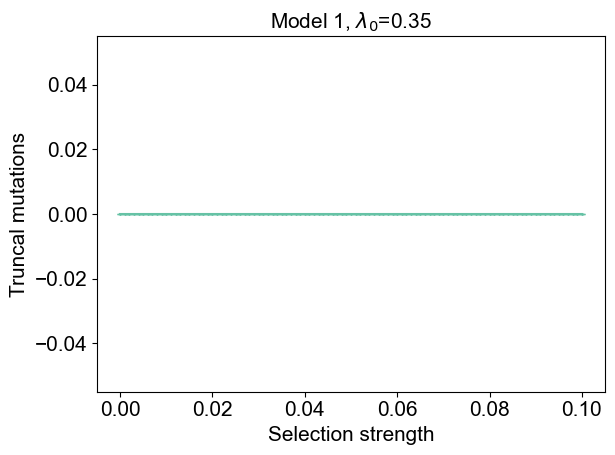

<Figure size 640x480 with 0 Axes>

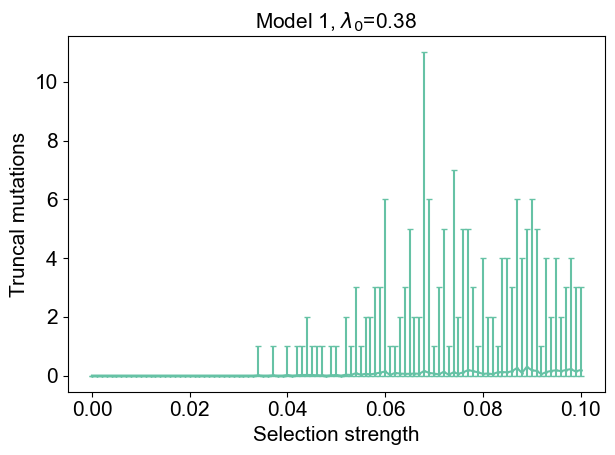

<Figure size 640x480 with 0 Axes>

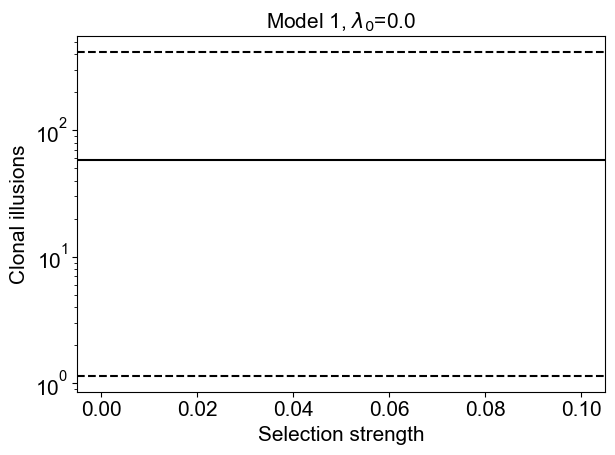

<Figure size 640x480 with 0 Axes>

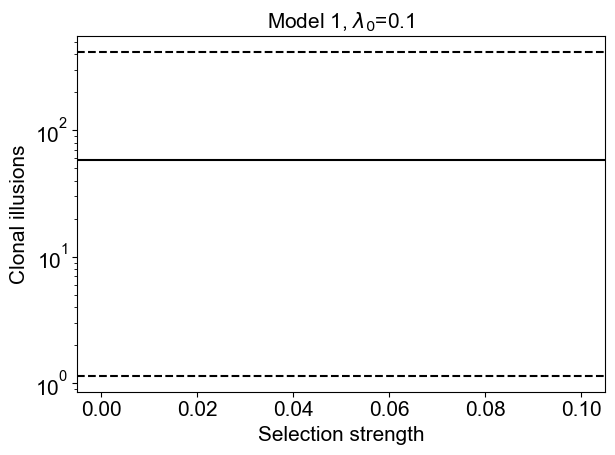

<Figure size 640x480 with 0 Axes>

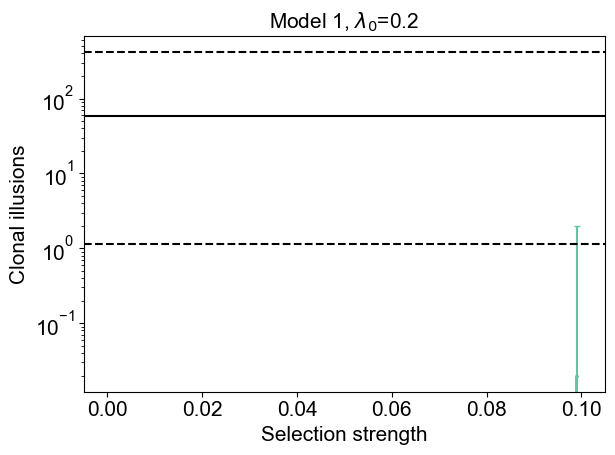

<Figure size 640x480 with 0 Axes>

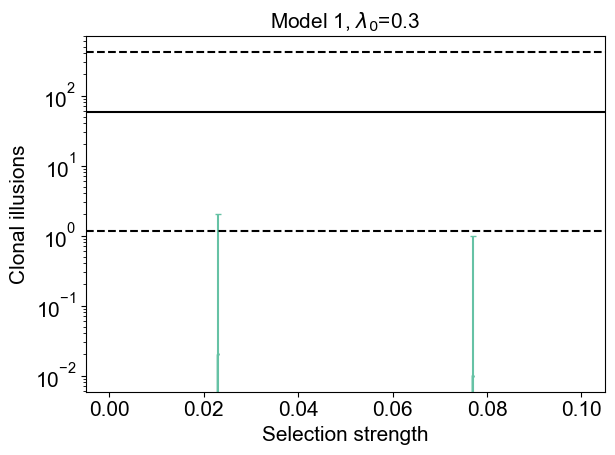

<Figure size 640x480 with 0 Axes>

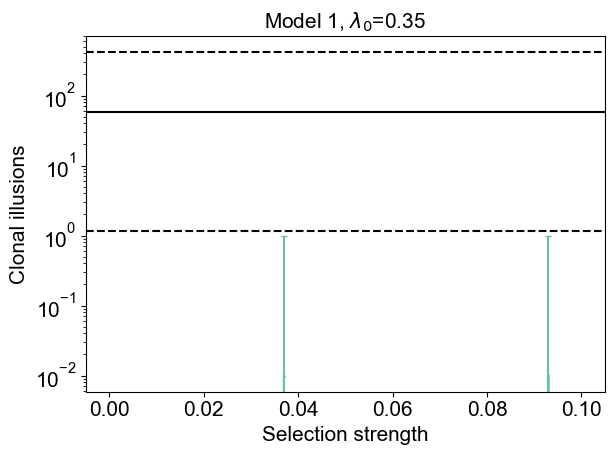

<Figure size 640x480 with 0 Axes>

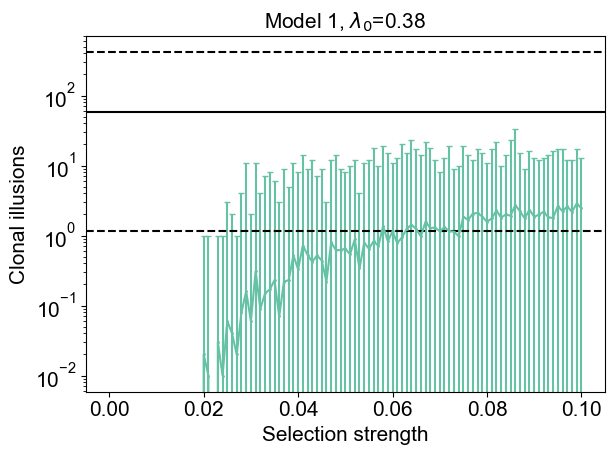

<Figure size 640x480 with 0 Axes>

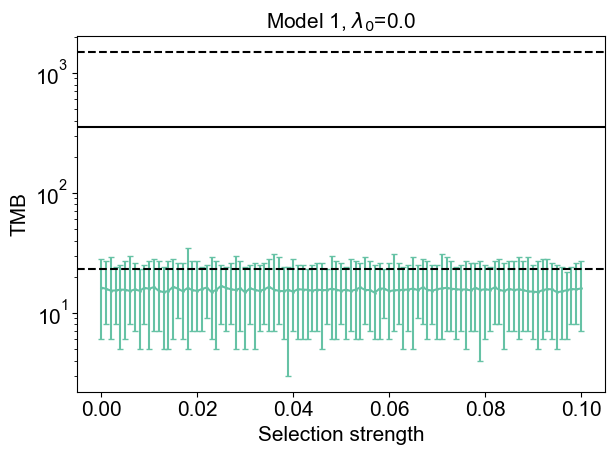

<Figure size 640x480 with 0 Axes>

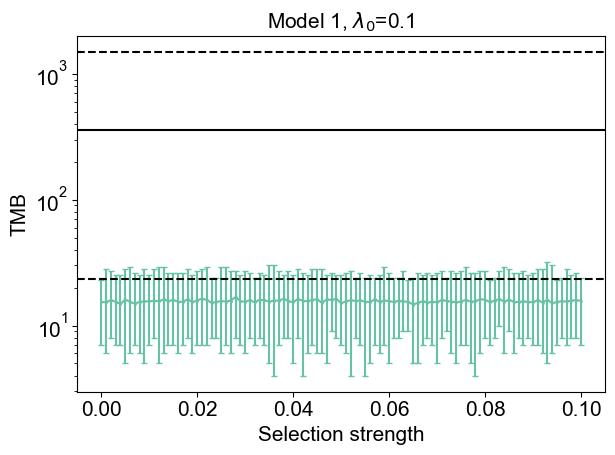

<Figure size 640x480 with 0 Axes>

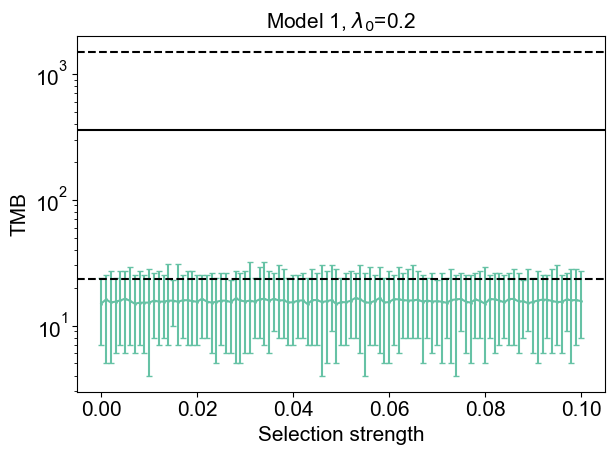

<Figure size 640x480 with 0 Axes>

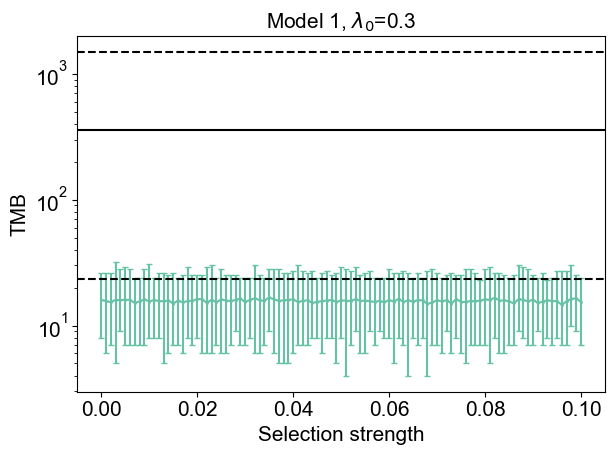

<Figure size 640x480 with 0 Axes>

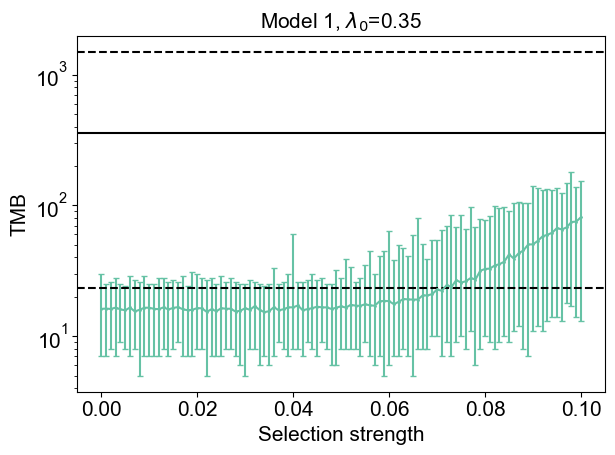

<Figure size 640x480 with 0 Axes>

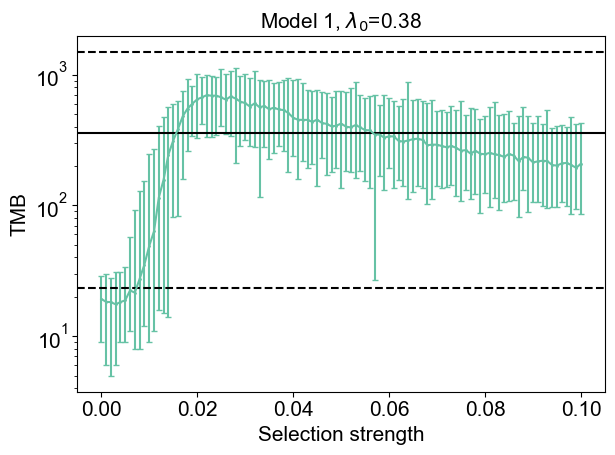

<Figure size 640x480 with 0 Axes>

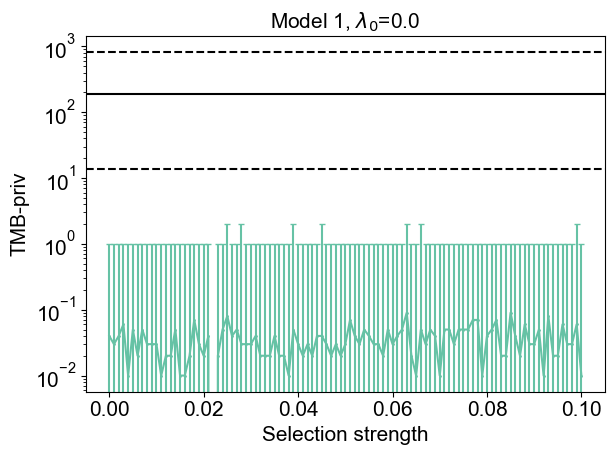

<Figure size 640x480 with 0 Axes>

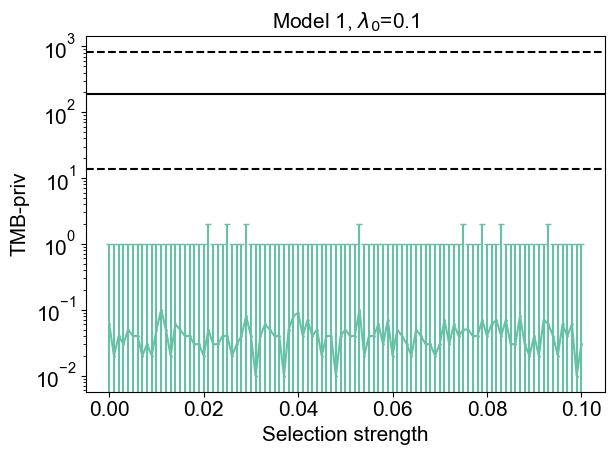

<Figure size 640x480 with 0 Axes>

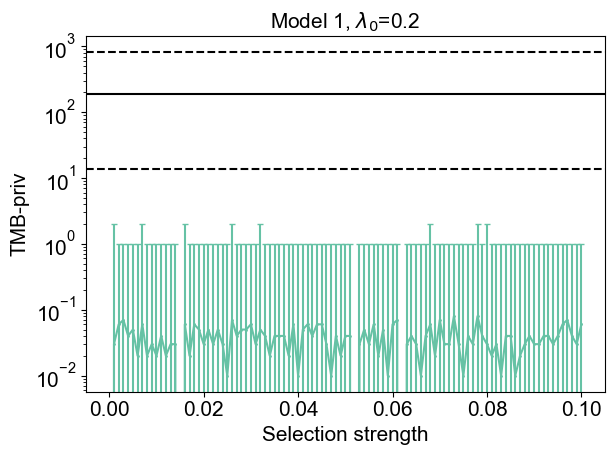

<Figure size 640x480 with 0 Axes>

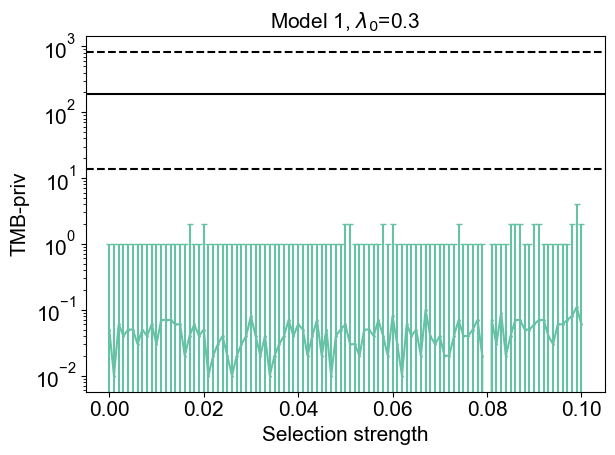

<Figure size 640x480 with 0 Axes>

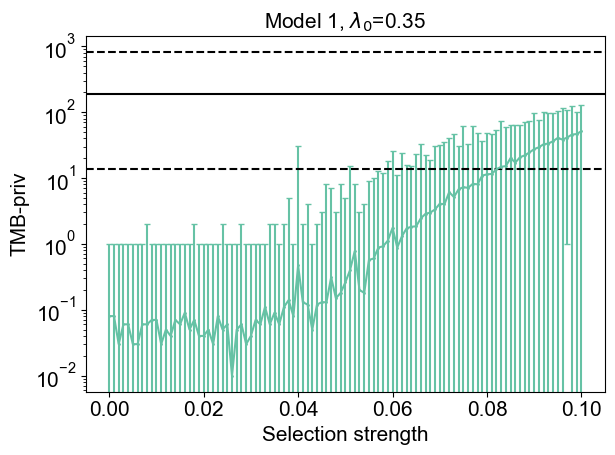

<Figure size 640x480 with 0 Axes>

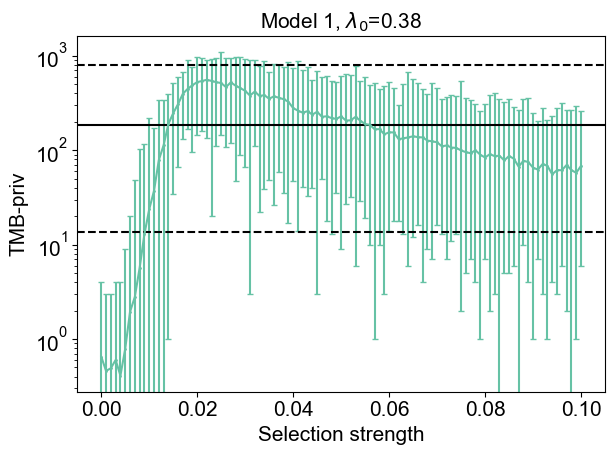

<Figure size 640x480 with 0 Axes>

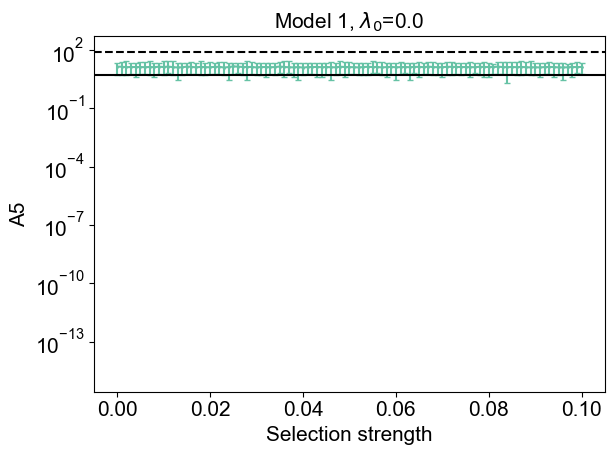

<Figure size 640x480 with 0 Axes>

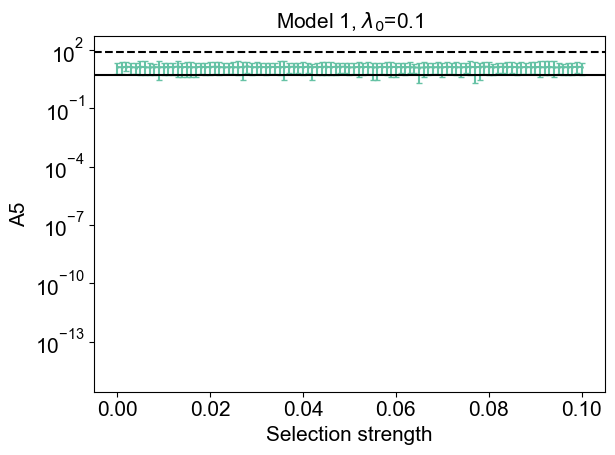

<Figure size 640x480 with 0 Axes>

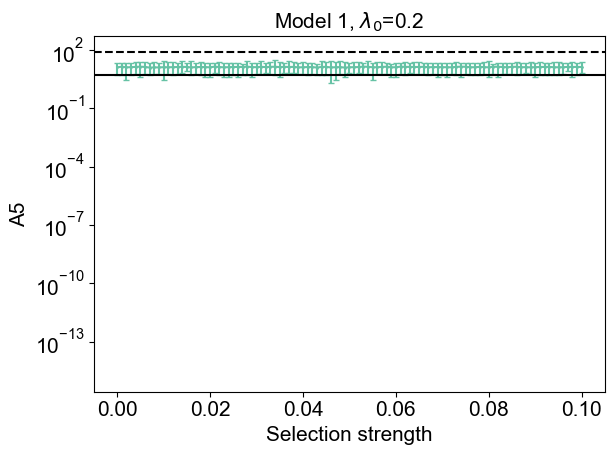

<Figure size 640x480 with 0 Axes>

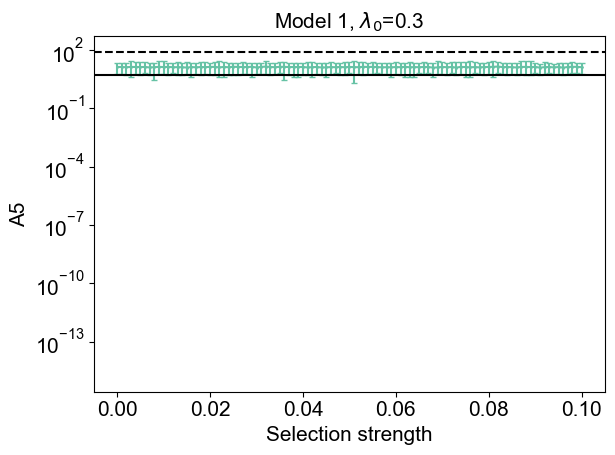

<Figure size 640x480 with 0 Axes>

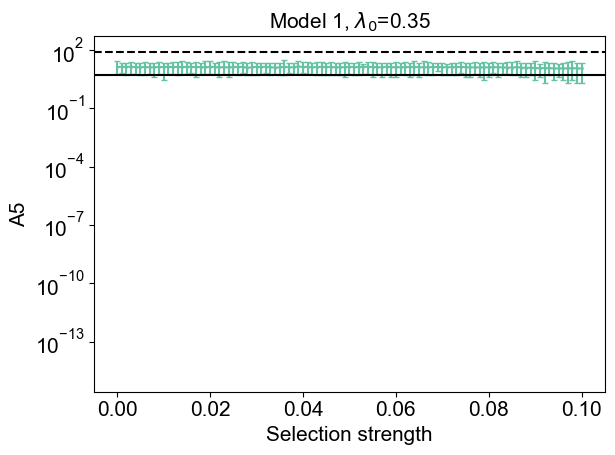

<Figure size 640x480 with 0 Axes>

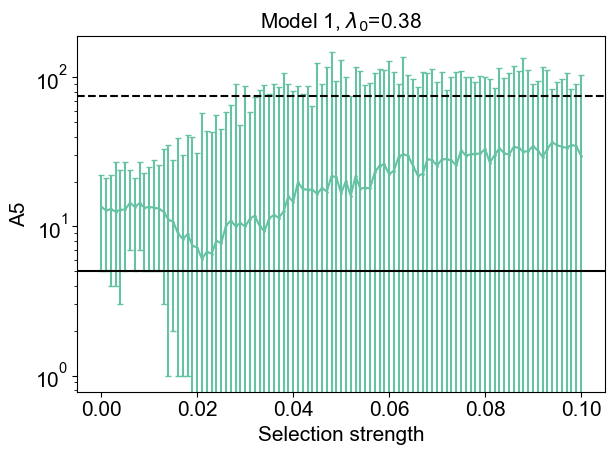

<Figure size 640x480 with 0 Axes>

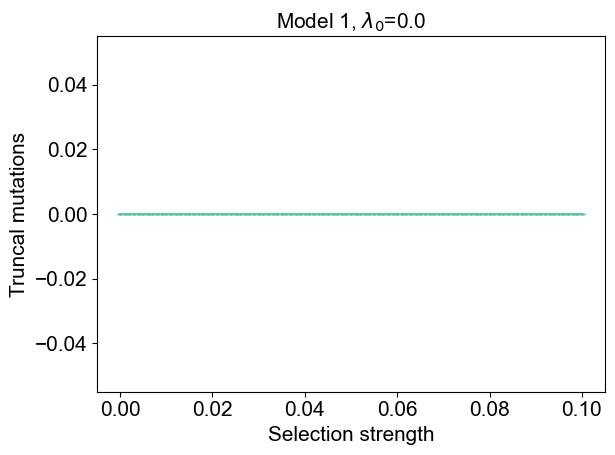

<Figure size 640x480 with 0 Axes>

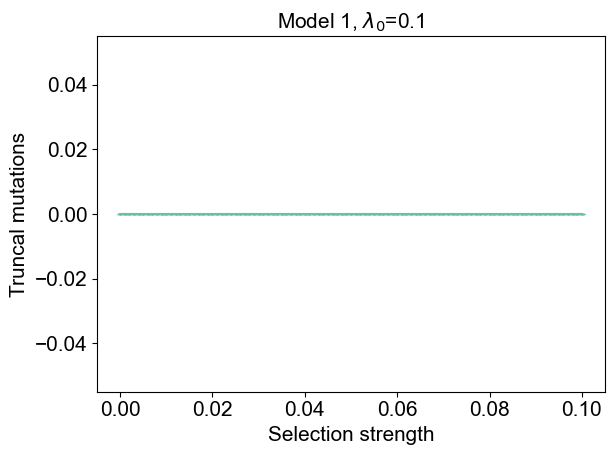

<Figure size 640x480 with 0 Axes>

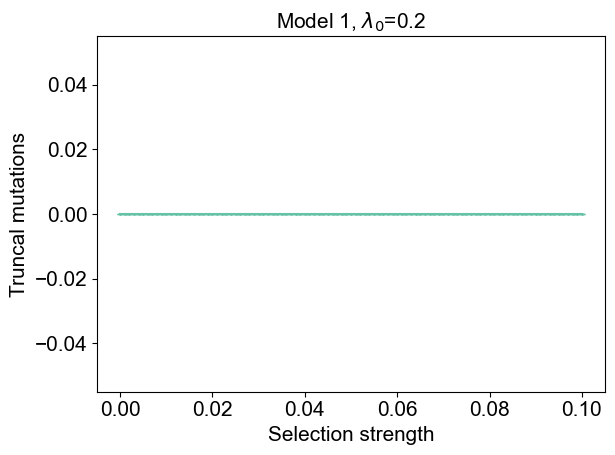

<Figure size 640x480 with 0 Axes>

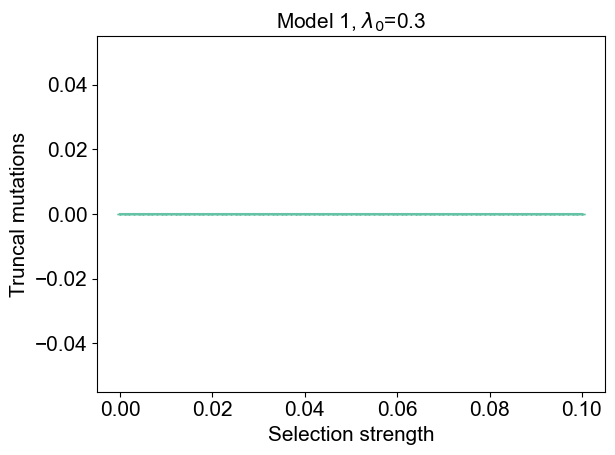

<Figure size 640x480 with 0 Axes>

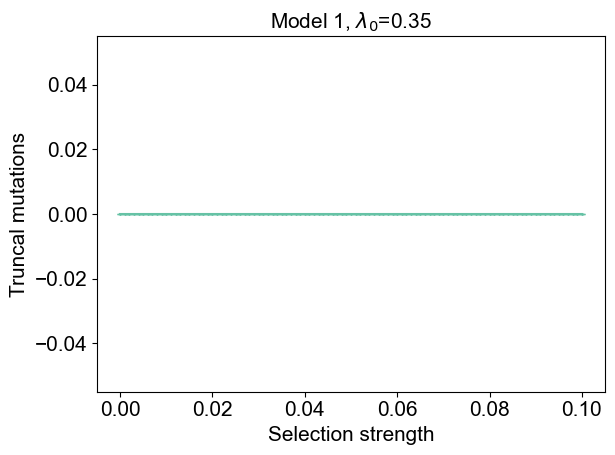

<Figure size 640x480 with 0 Axes>

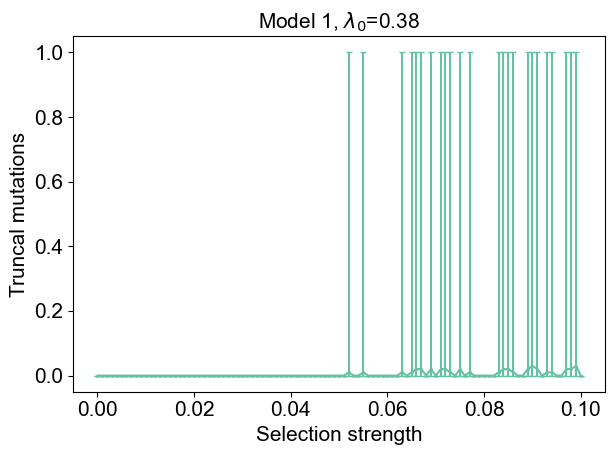

<Figure size 640x480 with 0 Axes>

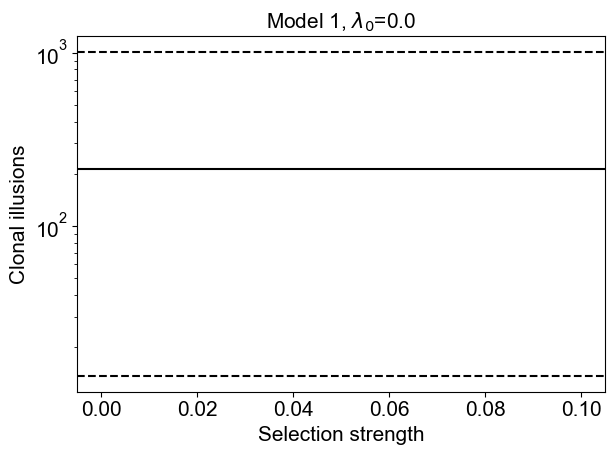

<Figure size 640x480 with 0 Axes>

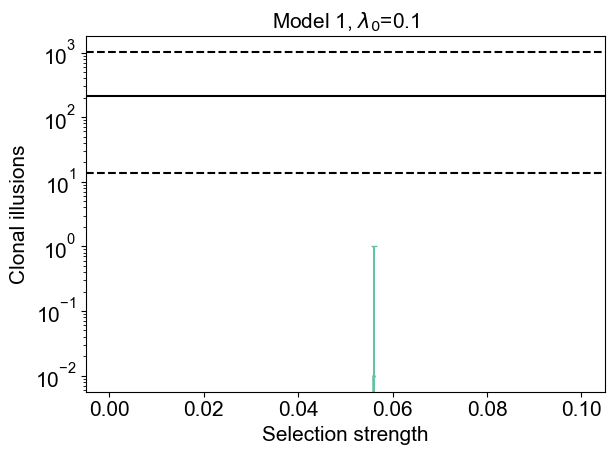

<Figure size 640x480 with 0 Axes>

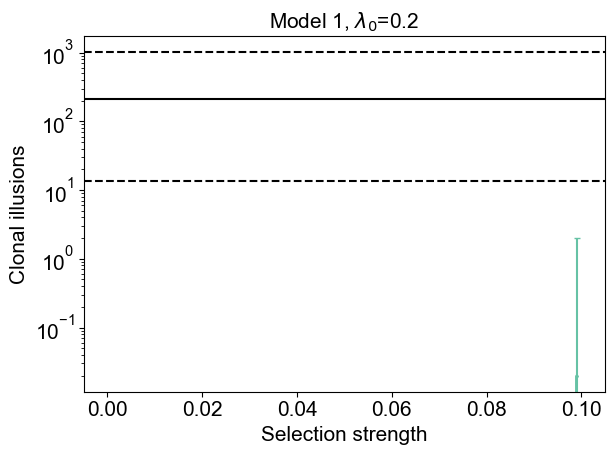

<Figure size 640x480 with 0 Axes>

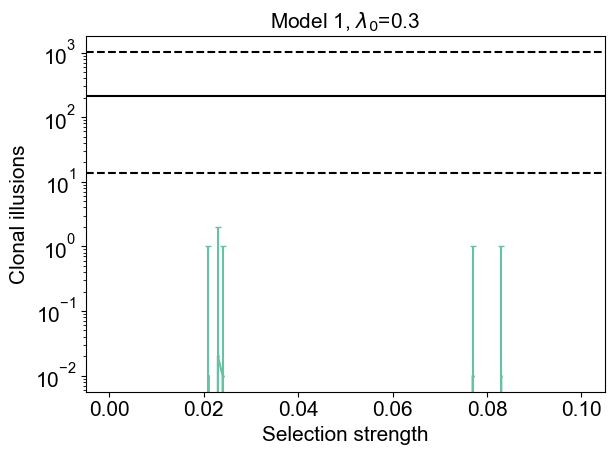

<Figure size 640x480 with 0 Axes>

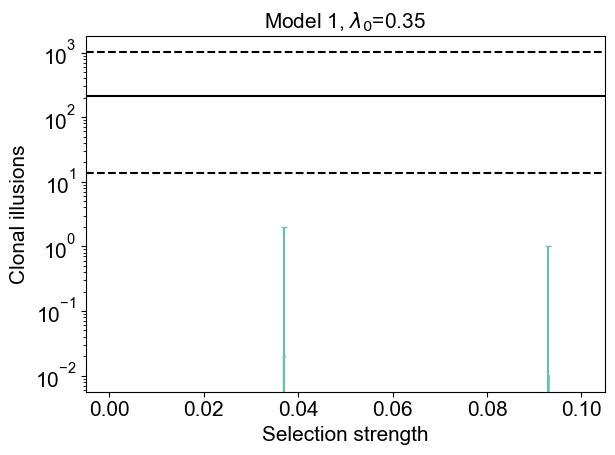

<Figure size 640x480 with 0 Axes>

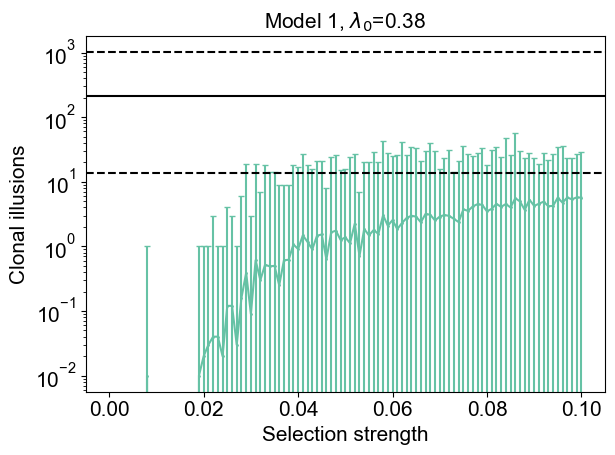

<Figure size 640x480 with 0 Axes>

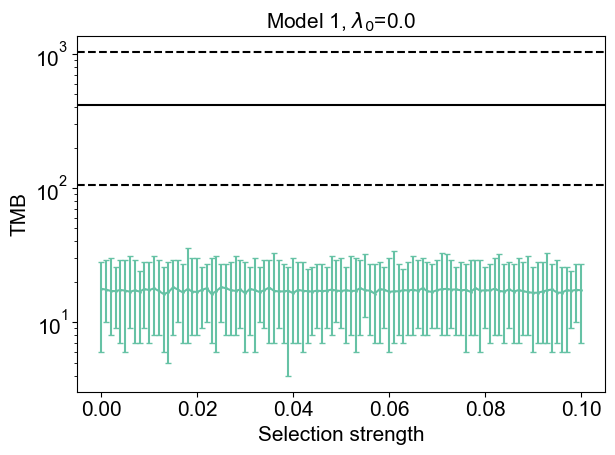

<Figure size 640x480 with 0 Axes>

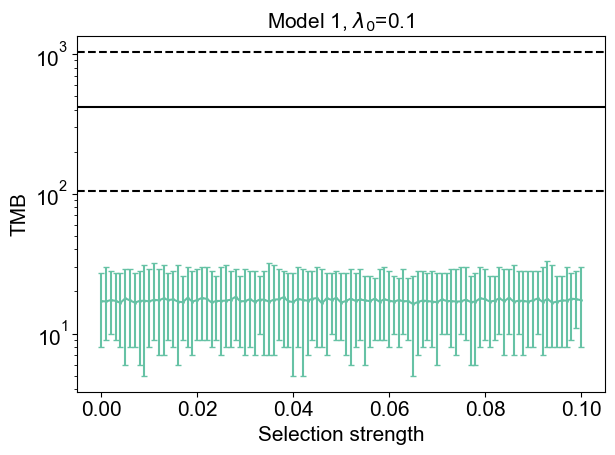

<Figure size 640x480 with 0 Axes>

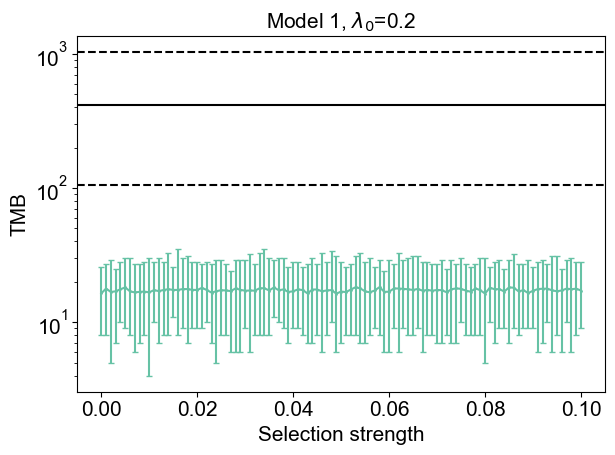

<Figure size 640x480 with 0 Axes>

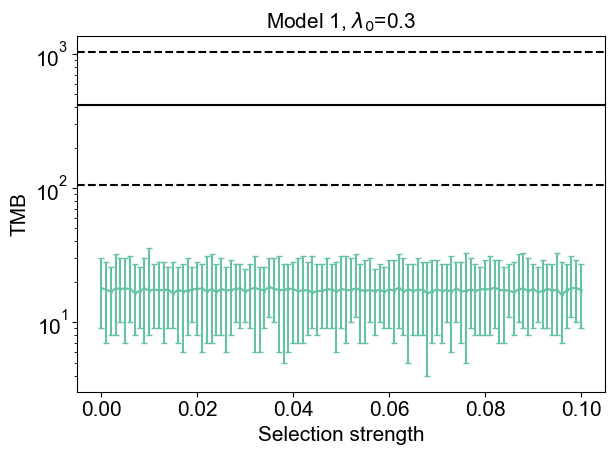

<Figure size 640x480 with 0 Axes>

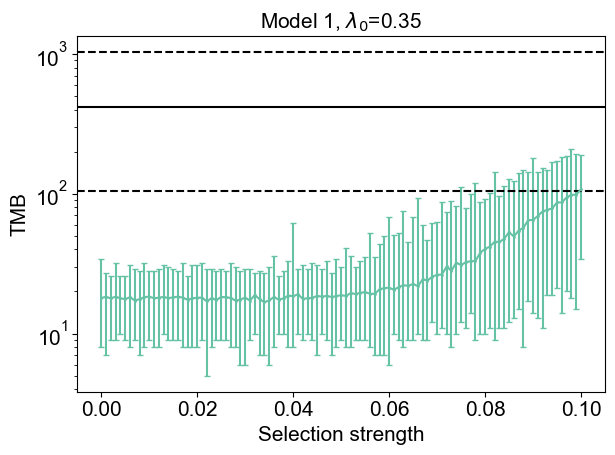

<Figure size 640x480 with 0 Axes>

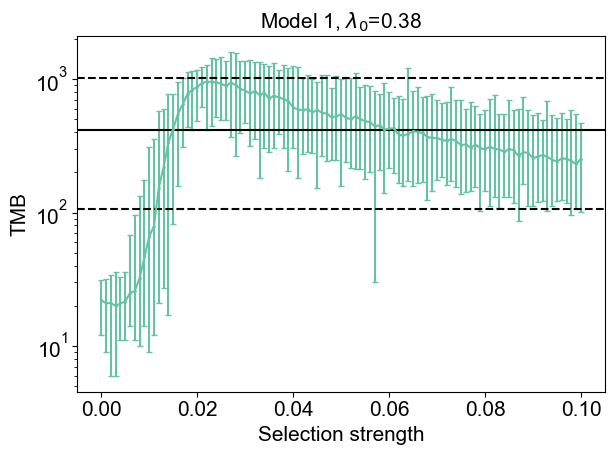

<Figure size 640x480 with 0 Axes>

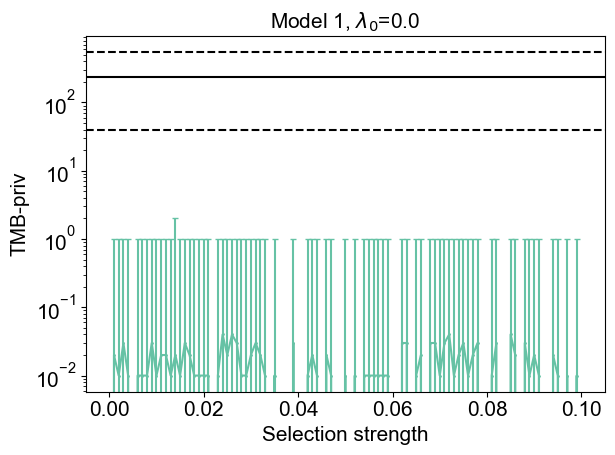

<Figure size 640x480 with 0 Axes>

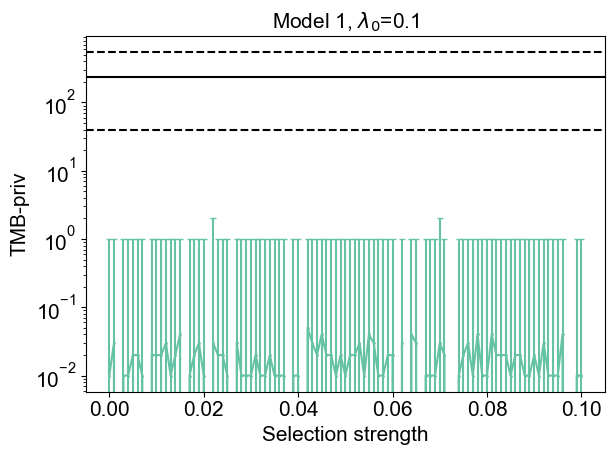

<Figure size 640x480 with 0 Axes>

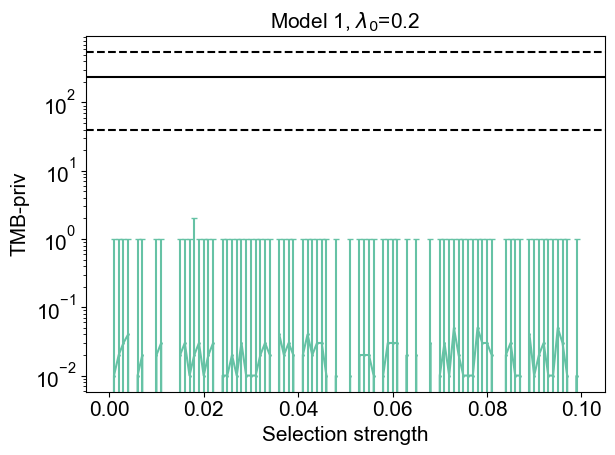

<Figure size 640x480 with 0 Axes>

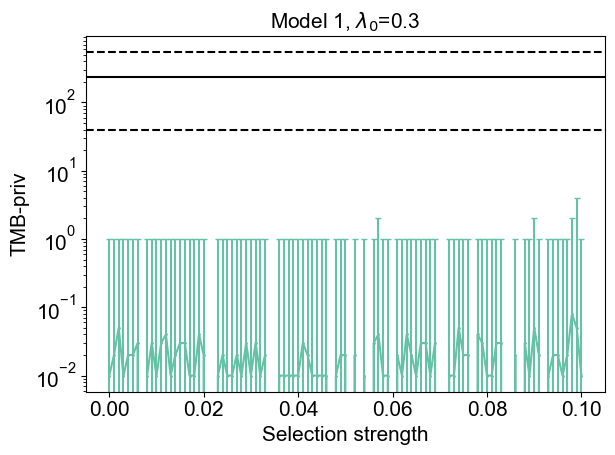

<Figure size 640x480 with 0 Axes>

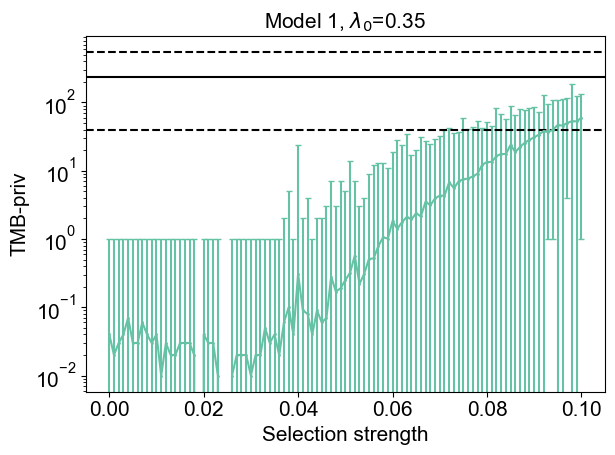

<Figure size 640x480 with 0 Axes>

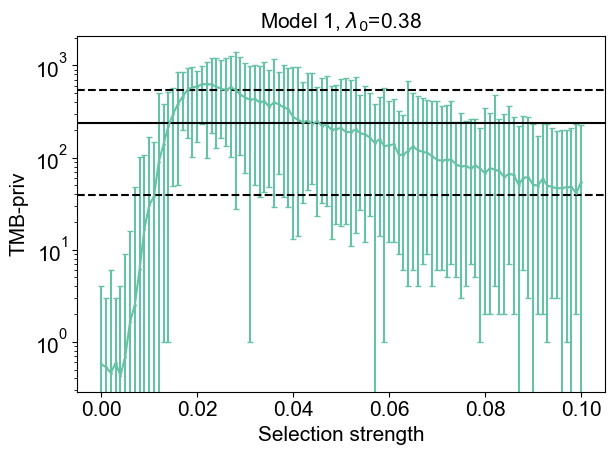

<Figure size 640x480 with 0 Axes>

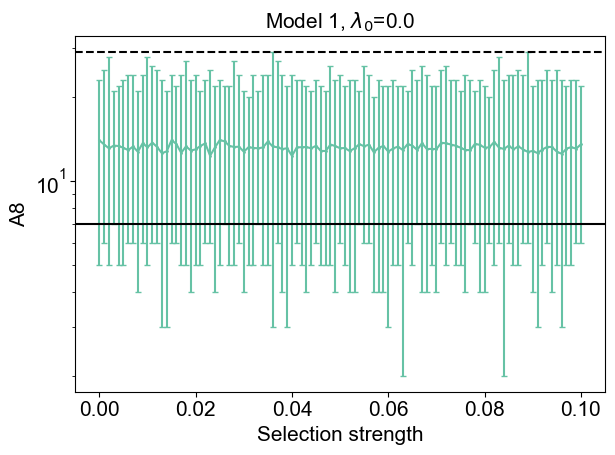

<Figure size 640x480 with 0 Axes>

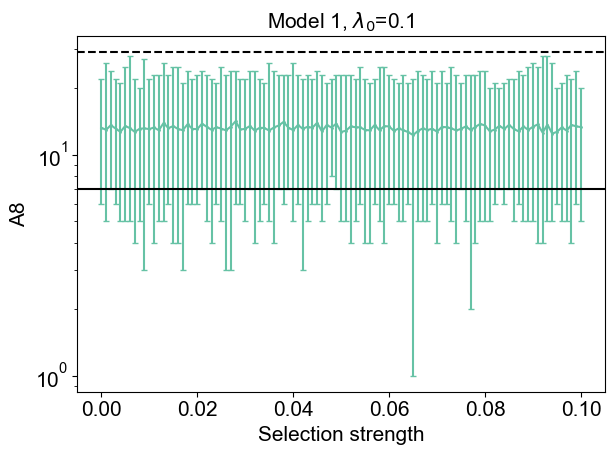

<Figure size 640x480 with 0 Axes>

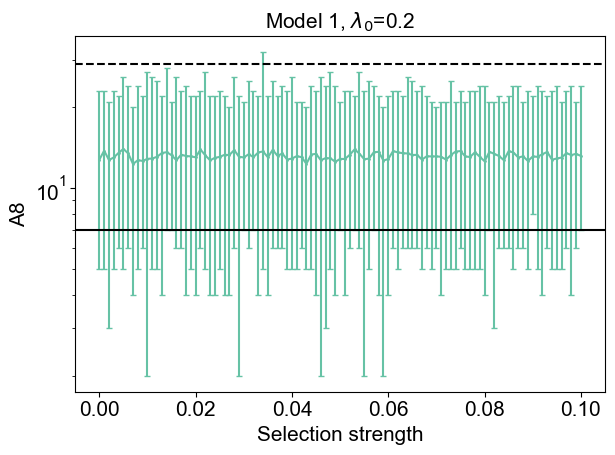

<Figure size 640x480 with 0 Axes>

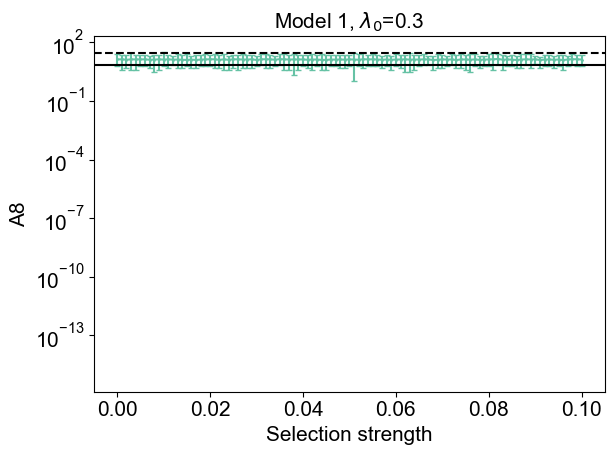

<Figure size 640x480 with 0 Axes>

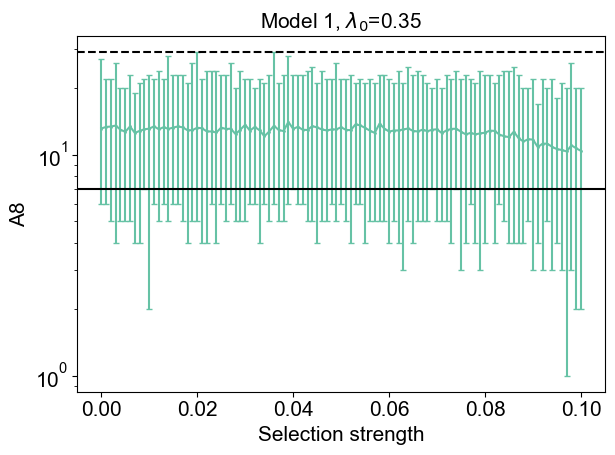

<Figure size 640x480 with 0 Axes>

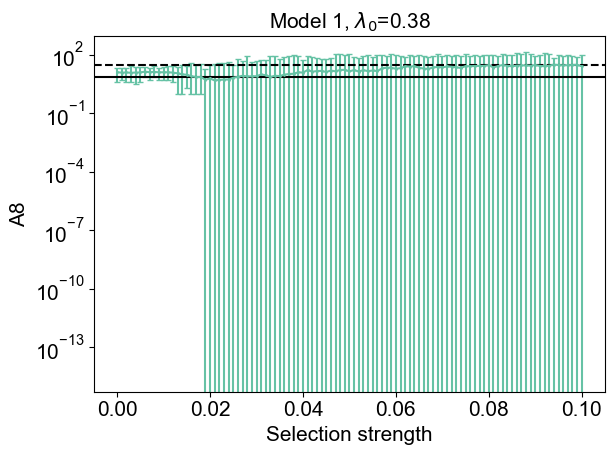

<Figure size 640x480 with 0 Axes>

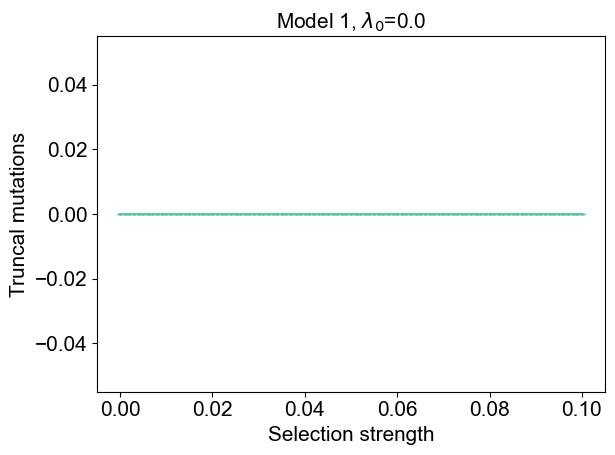

<Figure size 640x480 with 0 Axes>

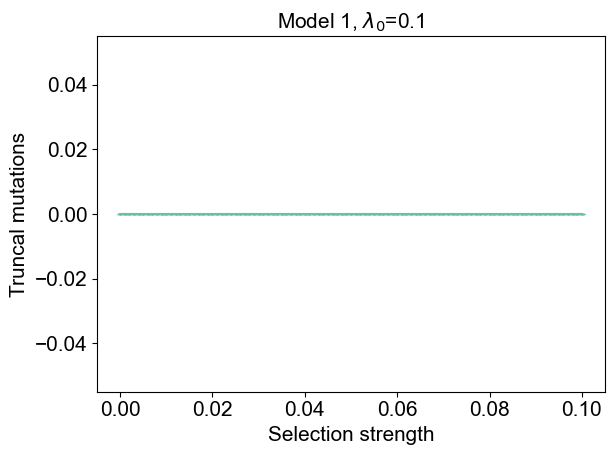

<Figure size 640x480 with 0 Axes>

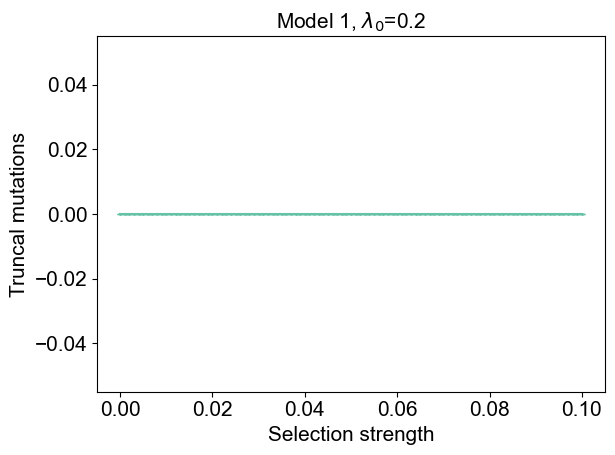

<Figure size 640x480 with 0 Axes>

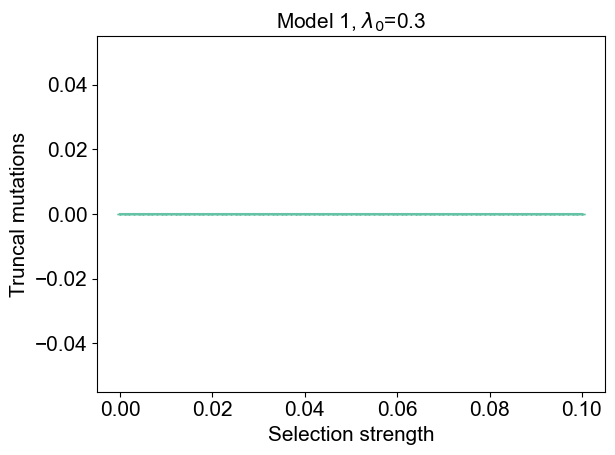

<Figure size 640x480 with 0 Axes>

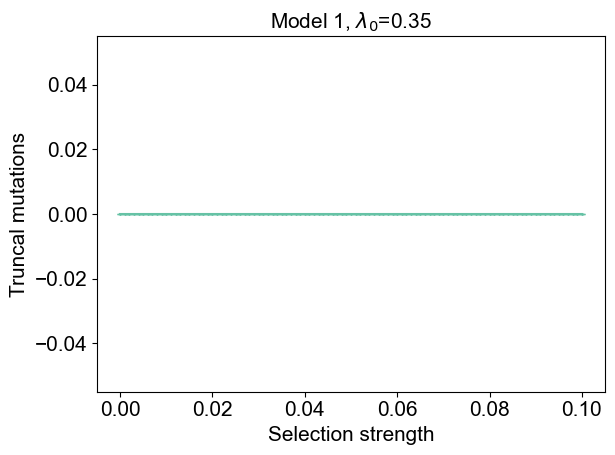

<Figure size 640x480 with 0 Axes>

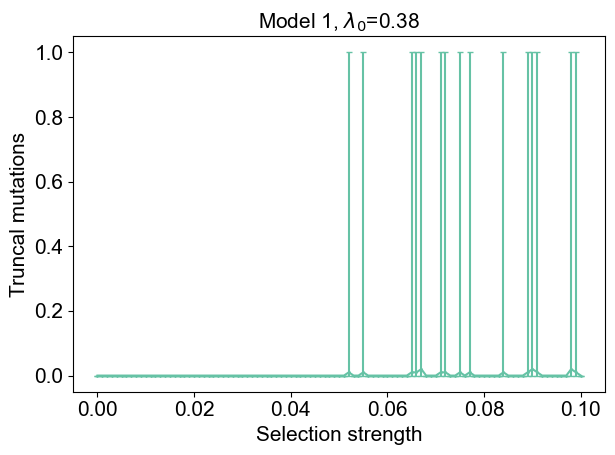

<Figure size 640x480 with 0 Axes>

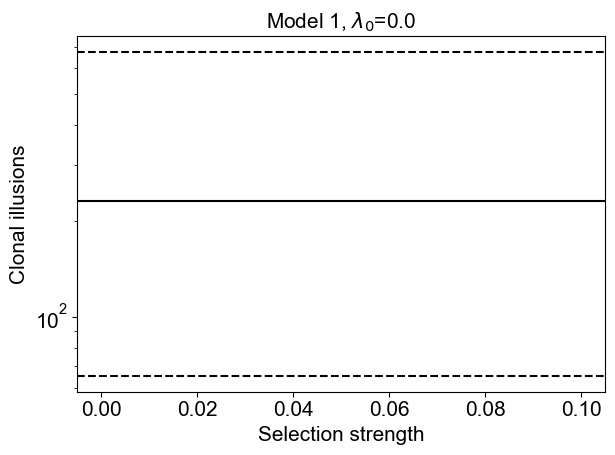

<Figure size 640x480 with 0 Axes>

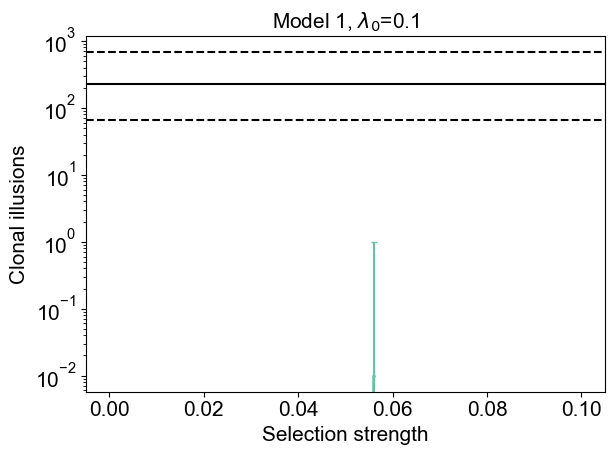

<Figure size 640x480 with 0 Axes>

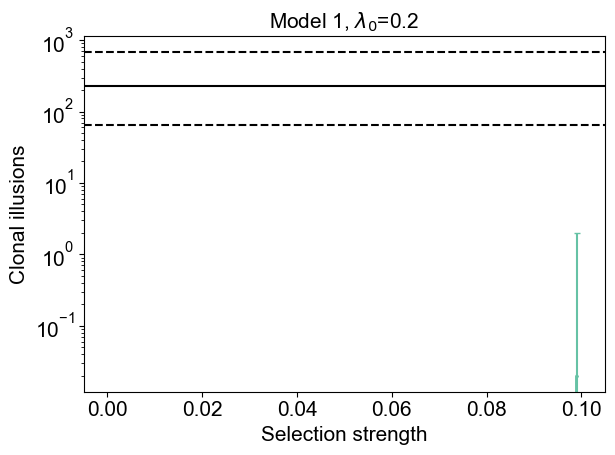

<Figure size 640x480 with 0 Axes>

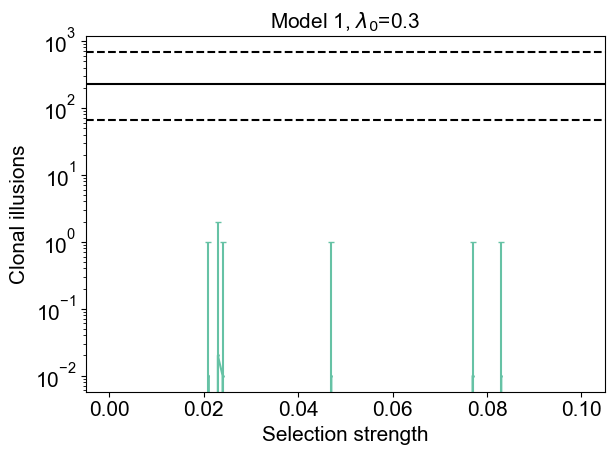

<Figure size 640x480 with 0 Axes>

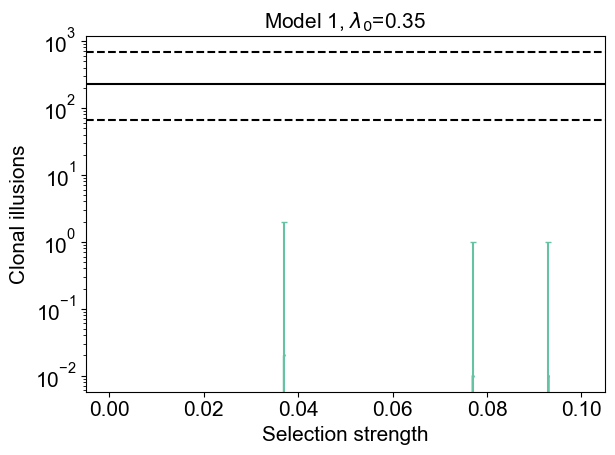

<Figure size 640x480 with 0 Axes>

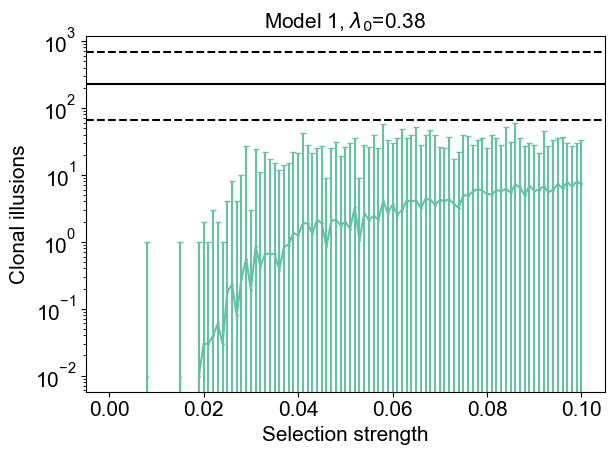

<Figure size 640x480 with 0 Axes>

In [24]:

def plot_variance_with_selection_ind(prefix, model, title, savetitle, selections, no_samples, color="#66c2a5", stat_indices=[0], categ_symbol=r'$\lambda_0$', categ_vary=[0.0, 0.1, 0.2, 0.3, 0.35, 0.38], load_names=["no_death", "low_death", "mid_death", "high_death", "vhigh_death", "highest_death"], use_legend=True, title_size=15, use_suffix=True):
    unique_sel_values = np.unique(selections)
    #load data
    ordered_labels = [model+"/"+prefix+"_"+name for name in load_names]
    stat_names = ["TMB", "TMB-priv"] + ["F"+str(s) for s in range(1, no_samples)]+ ["F-priv"] + ["A"+str(s) for s in range(2, no_samples+1)] + ["Clonal illusions", "Truncal mutations"]
    cruk_tumour_stats = np.load("cruk_"+str(no_samples)+"_samples_stat.npy", allow_pickle=True)
    all_avs, all_errors = np.zeros((len(categ_vary), len(unique_sel_values), len(stat_names))), np.zeros((len(categ_vary), len(unique_sel_values), len(stat_names), 2))
    labels_for_display = [categ_symbol+"="+str(var) for var in categ_vary]
    for l, label in enumerate(ordered_labels):
        stats = np.load(base_filepath+label+"_"+str(no_samples)+"_samples_stats.npy", allow_pickle=True)
        params = np.load(base_filepath+label+"_"+str(no_samples)+"_samples_params.npy", allow_pickle=True)
        for s, sel in enumerate(unique_sel_values):
            relevant_exps = np.where(params[:, 0]==sel)[0]
            for n, name in enumerate(stat_names):
                if name != "Clonal illusions" and name != "Truncal mutations":
                    relevant_stats = stats[relevant_exps, n]
                else:
                    if name == "Clonal illusions":
                        relevant_stats = np.sum(stats[relevant_exps, 2:no_samples+1], axis=1)
                    else:
                        relevant_stats = stats[relevant_exps, n-1]
                all_avs[l][s][n] = np.average(relevant_stats)
                all_errors[l][s][n][0], all_errors[l][s][n][1]  = all_avs[l][s][n]-np.min(relevant_stats), np.max(relevant_stats)-all_avs[l][s][n] #error bars either side to indicate maximum and minimum

    for n in stat_indices:
        name = stat_names[n]
        if n < len(stat_names)-1:
            for l, label in enumerate(labels_for_display):
                fig, ax = plt.subplots()
                #fig_ind, ax_ind = plt.subplots()
                #print(categ_vary, all_avs[l, :, n], all_errors[l, :, n].T)
                markers, caps, bars = ax.errorbar(x=unique_sel_values, y=all_avs[l, :, n], yerr=all_errors[l, :, n].T, fmt='o', linestyle='-', ms=1, capsize=2, label=label, color=color)
                # [bar.set_alpha(0.5) for bar in bars]
                # [cap.set_alpha(0.5) for cap in caps]
                if name != "Clonal illusions":
                    relevant_cruk_stats = cruk_tumour_stats[:, n]
                else:
                    relevant_cruk_stats = np.sum(cruk_tumour_stats[:, 2:no_samples+1], axis=1)
                ax.axhline(y=np.percentile(relevant_cruk_stats, 95), color='black', linestyle='--')
                ax.axhline(y=np.percentile(relevant_cruk_stats, 5), color='black', linestyle='--')
                ax.axhline(y=np.median(relevant_cruk_stats), color='black', linestyle='-')
                ax.set_ylabel(name)
                ax.set_xlabel("Selection strength")
                if name != "Truncal mutations":
                    plt.yscale("log")
                if use_suffix:
                    ax.set_title(title + ", " +categ_symbol+ "="+str(categ_vary[l]), fontsize=title_size)
                else:
                    ax.set_title(title, fontsize=title_size)
                # if use_legend and no_samples==2 and n==0:
                #     ax.legend()
                plt.tight_layout()
                plt.show()
                fig.savefig(base_filepath+"/figs_1410"+"/"+savetitle+"_"+str(no_samples)+"_"+name+"_"+str(categ_vary[l])+"_samples_with_indic_lines.pdf", dpi=300)
                plt.clf()
        if n==len(stat_names)-1:
            for l, label in enumerate(labels_for_display):
                fig, ax = plt.subplots()
                markers, caps, bars = ax.errorbar(x=unique_sel_values, y=all_avs[l, :, n], yerr=all_errors[l, :, n].T, fmt='o', linestyle='-', ms=1, capsize=2, label=label, color=color)
                # [bar.set_alpha(0.5) for bar in bars]
                # [cap.set_alpha(0.5) for cap in caps]
                #ax.axhline(y=np.percentile(cruk_tumour_stats[:, n], 95), color='black', linestyle='--')
                #ax.axhline(y=np.percentile(cruk_tumour_stats[:, n], 5), color='black', linestyle='--')
                plt.ylabel(name)
                plt.xlabel("Selection strength")
                if name != "Truncal mutations":
                    plt.yscale("log")
                if use_suffix:
                    ax.set_title(title + ", " +categ_symbol+ "="+str(categ_vary[l]), fontsize=title_size)
                else:
                    ax.set_title(title, fontsize=title_size)
                # if use_legend:
                #     plt.legend()
                plt.tight_layout()
                plt.show()
                fig.savefig(base_filepath+"/figs_1410"+"/"+savetitle+"_"+str(no_samples)+"_"+name+"_"+str(categ_vary[l])+"_samples_without_indic_lines.pdf", dpi=300)
                plt.clf()
                    
for no_samples in [2, 5, 8]:            
    plot_variance_with_selection_ind("11Aug", "model_1", "Model 1", "model_1", selections, no_samples, color="#66c2a5", stat_indices = [0, 1, 2*no_samples, 2*no_samples+2, 2*no_samples+1])


Now for model 2.

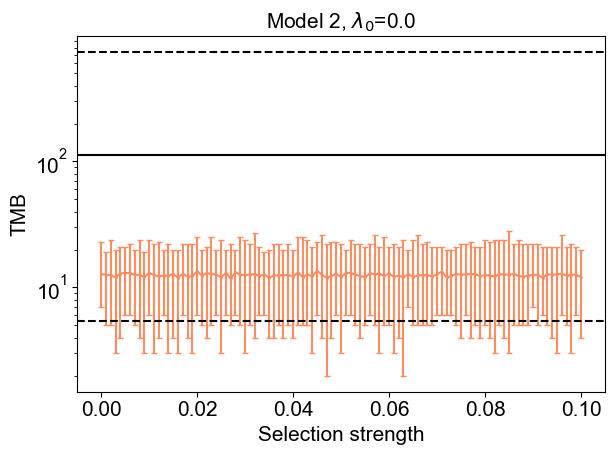

<Figure size 640x480 with 0 Axes>

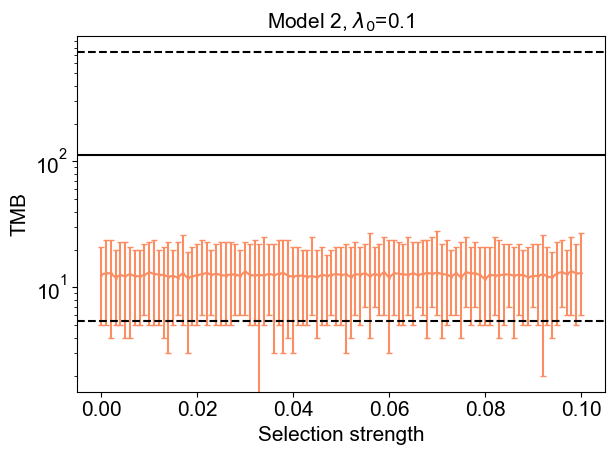

<Figure size 640x480 with 0 Axes>

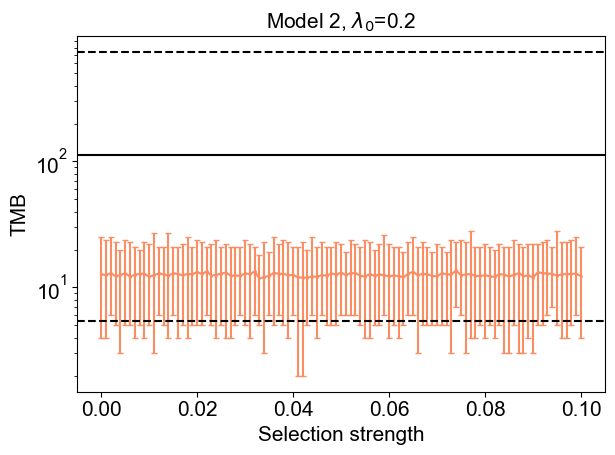

<Figure size 640x480 with 0 Axes>

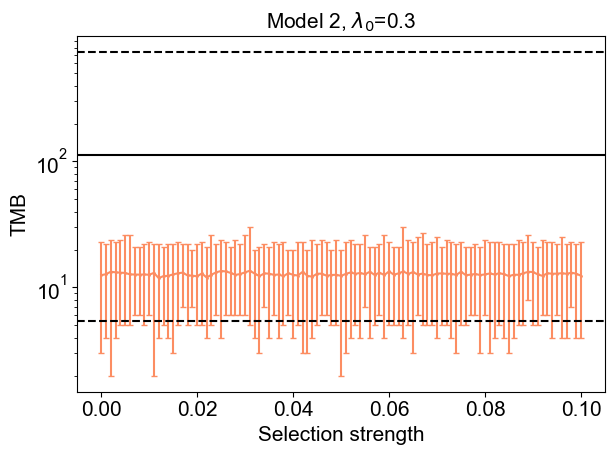

<Figure size 640x480 with 0 Axes>

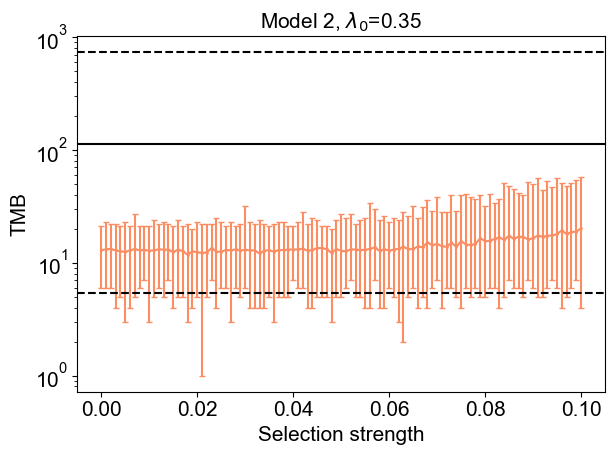

<Figure size 640x480 with 0 Axes>

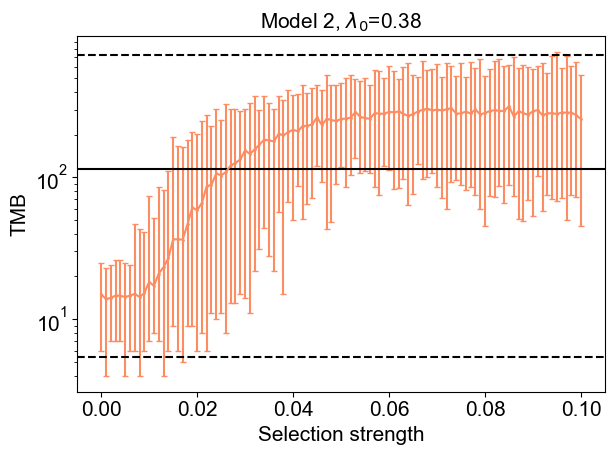

<Figure size 640x480 with 0 Axes>

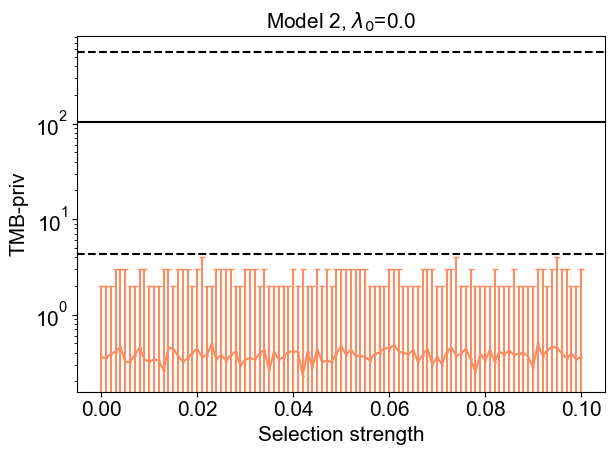

<Figure size 640x480 with 0 Axes>

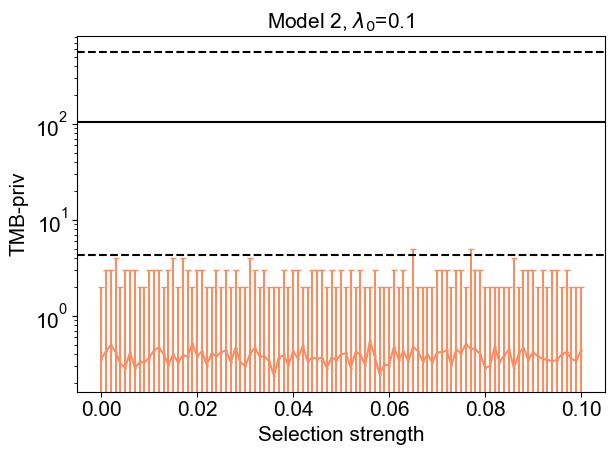

<Figure size 640x480 with 0 Axes>

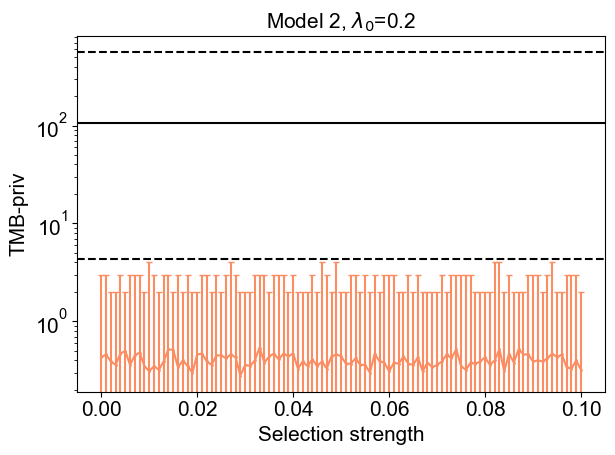

<Figure size 640x480 with 0 Axes>

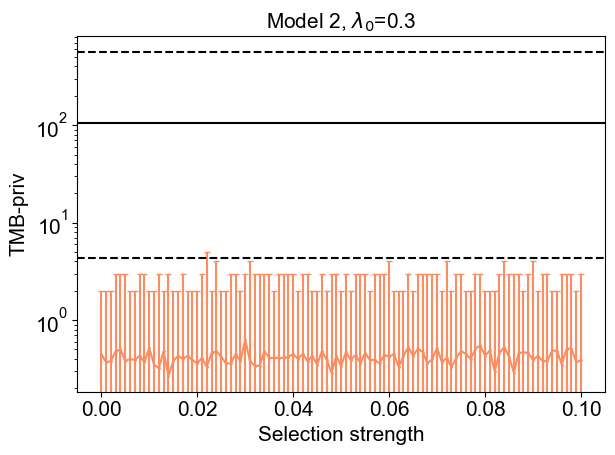

<Figure size 640x480 with 0 Axes>

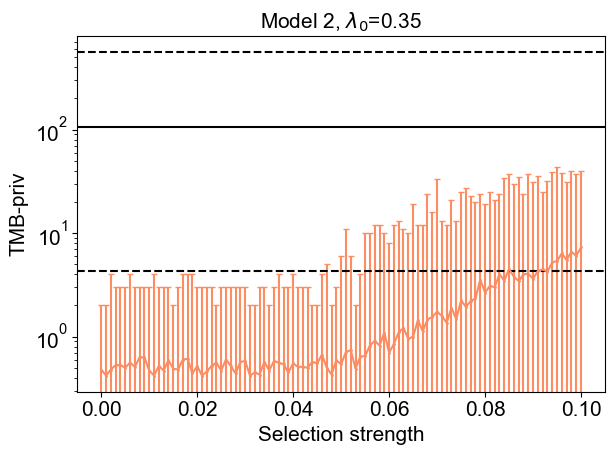

<Figure size 640x480 with 0 Axes>

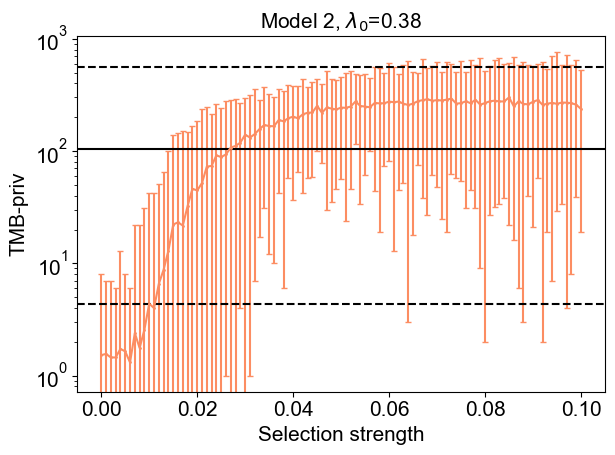

<Figure size 640x480 with 0 Axes>

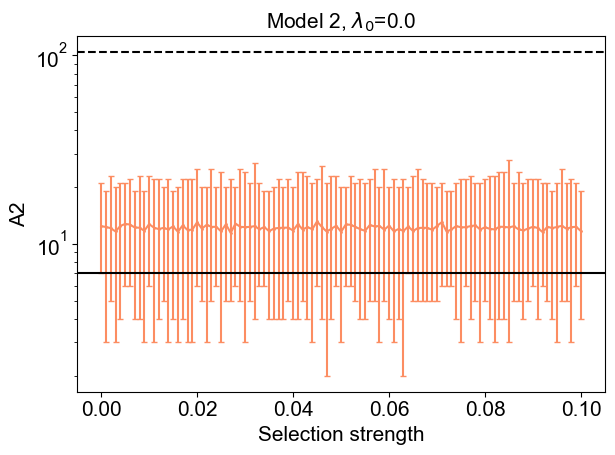

<Figure size 640x480 with 0 Axes>

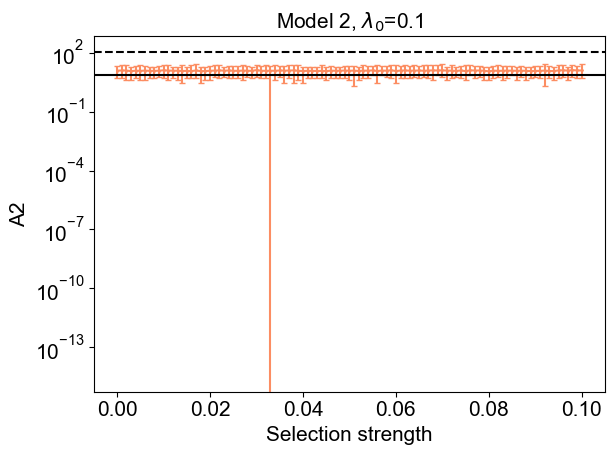

<Figure size 640x480 with 0 Axes>

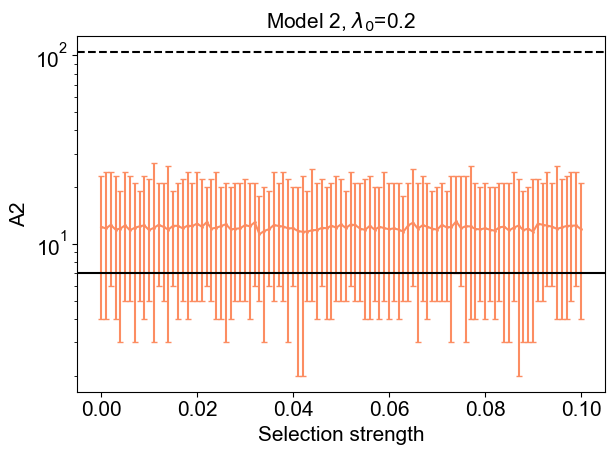

<Figure size 640x480 with 0 Axes>

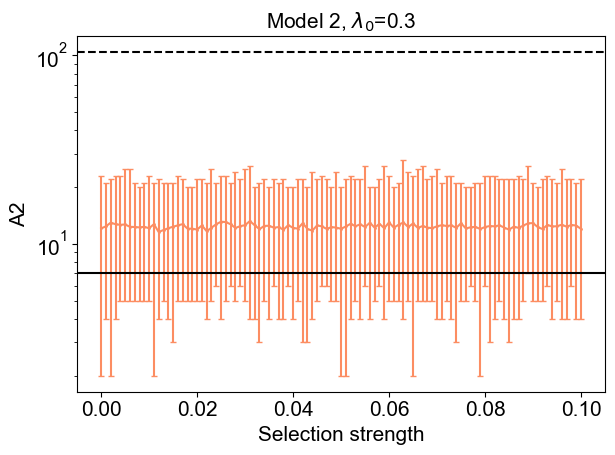

<Figure size 640x480 with 0 Axes>

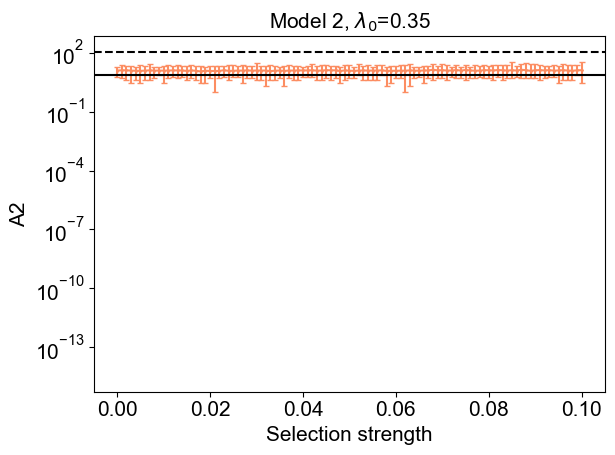

<Figure size 640x480 with 0 Axes>

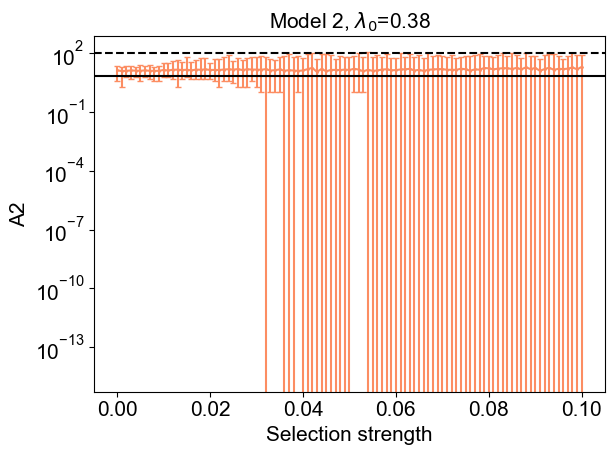

<Figure size 640x480 with 0 Axes>

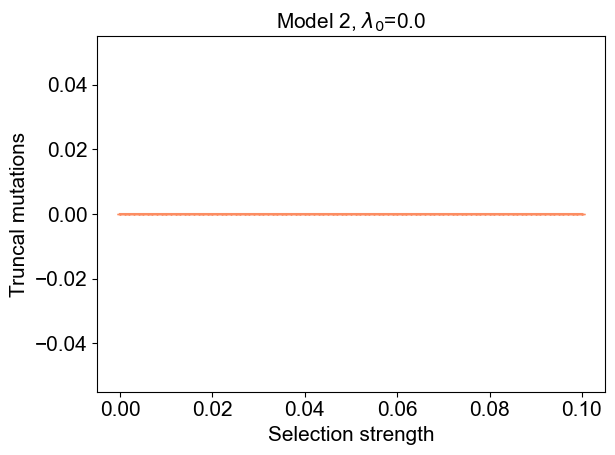

<Figure size 640x480 with 0 Axes>

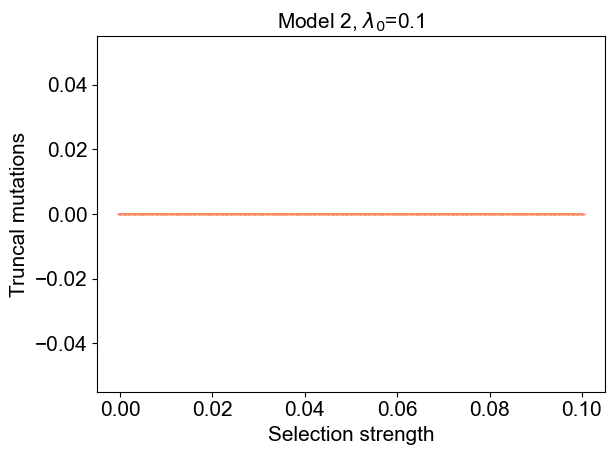

<Figure size 640x480 with 0 Axes>

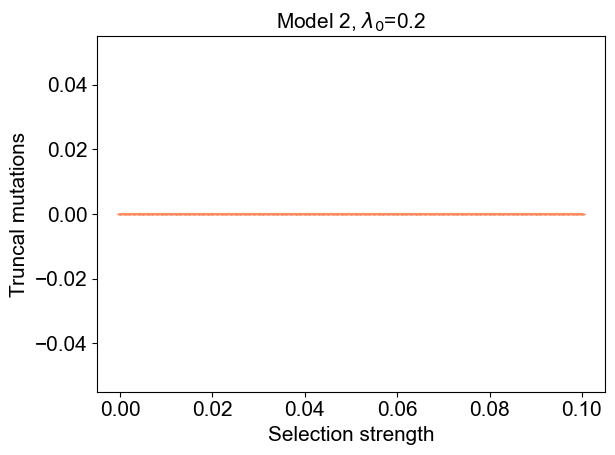

<Figure size 640x480 with 0 Axes>

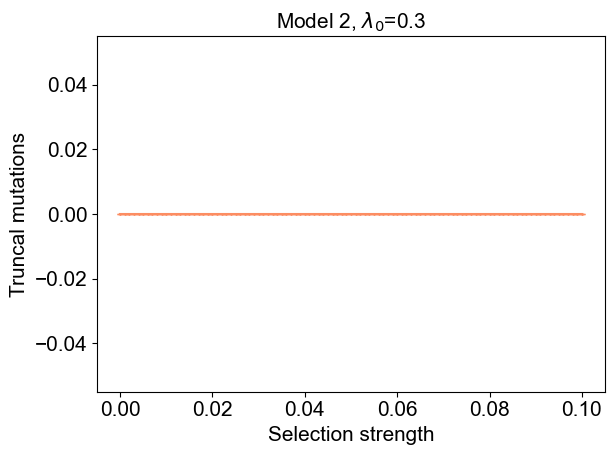

<Figure size 640x480 with 0 Axes>

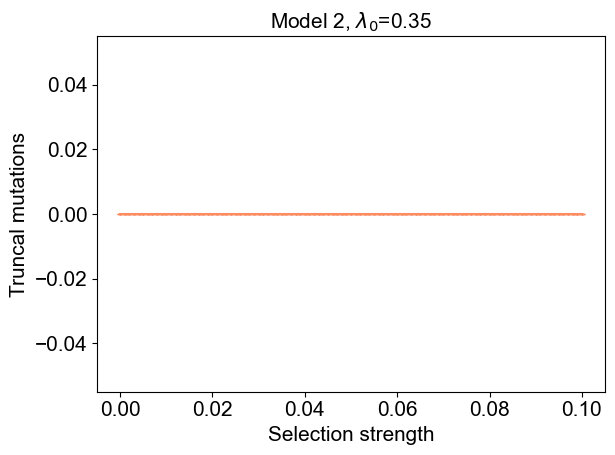

<Figure size 640x480 with 0 Axes>

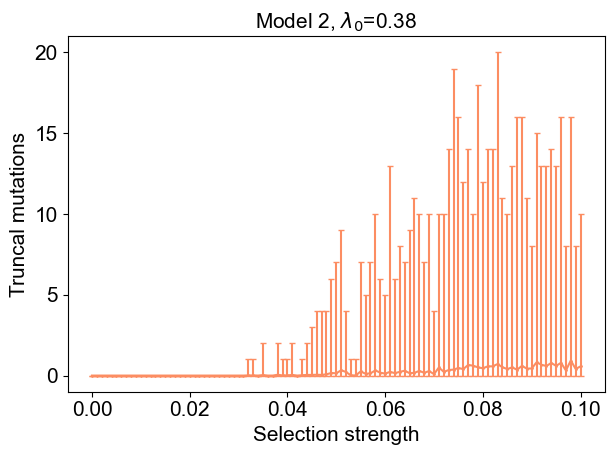

<Figure size 640x480 with 0 Axes>

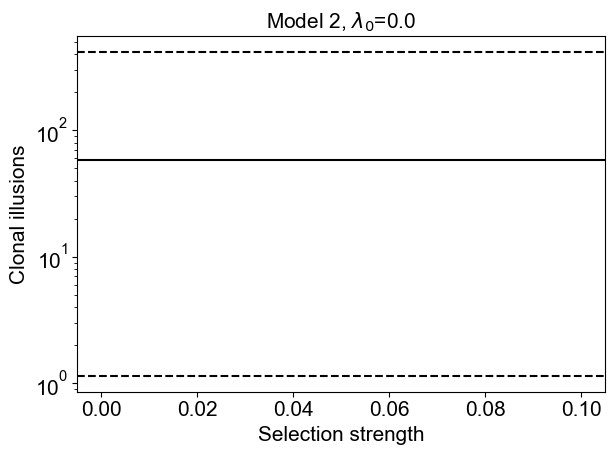

<Figure size 640x480 with 0 Axes>

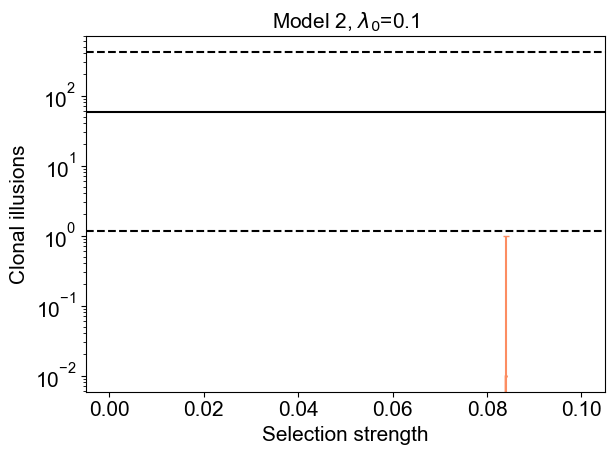

<Figure size 640x480 with 0 Axes>

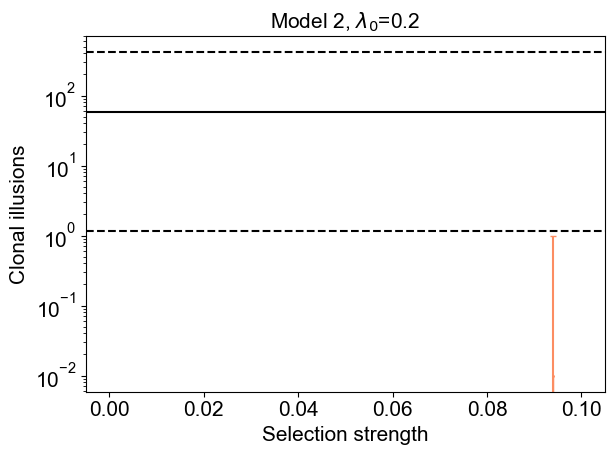

<Figure size 640x480 with 0 Axes>

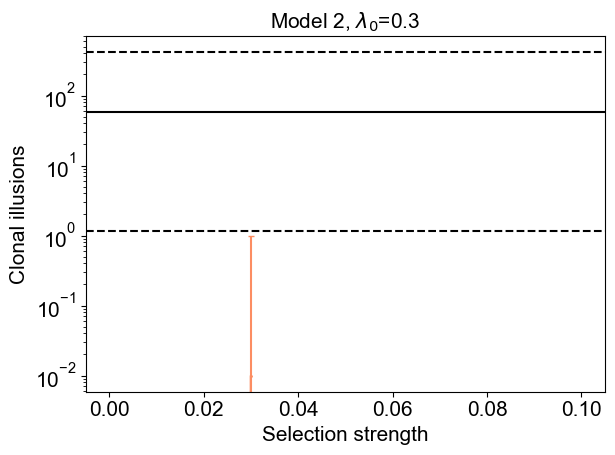

<Figure size 640x480 with 0 Axes>

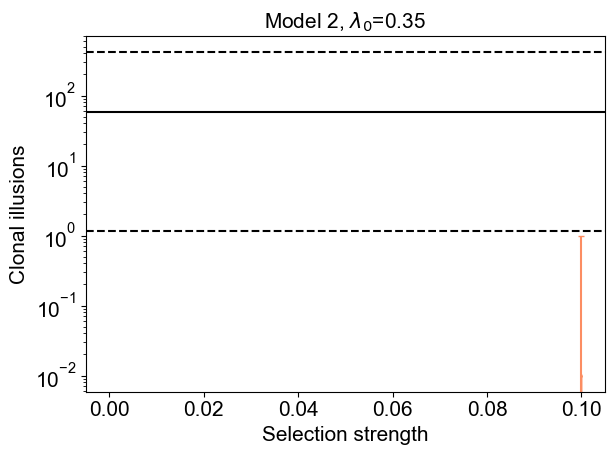

<Figure size 640x480 with 0 Axes>

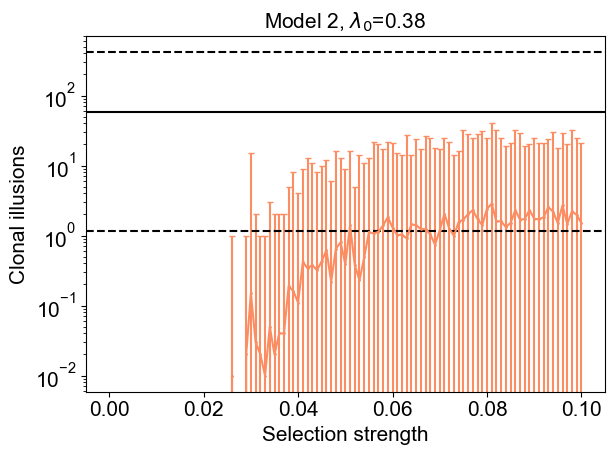

<Figure size 640x480 with 0 Axes>

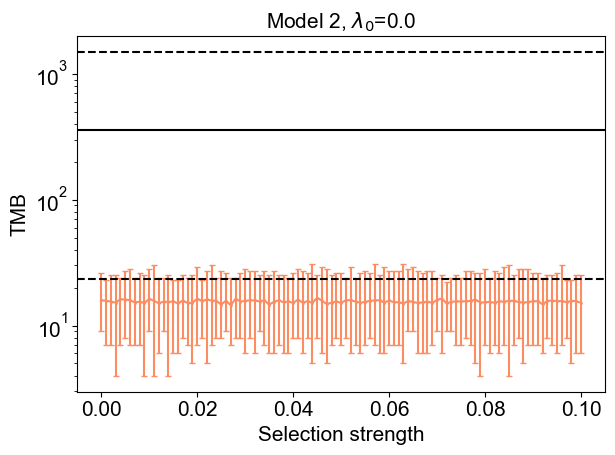

<Figure size 640x480 with 0 Axes>

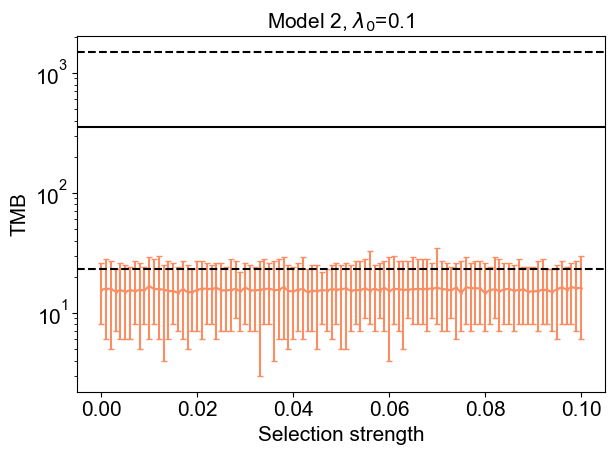

<Figure size 640x480 with 0 Axes>

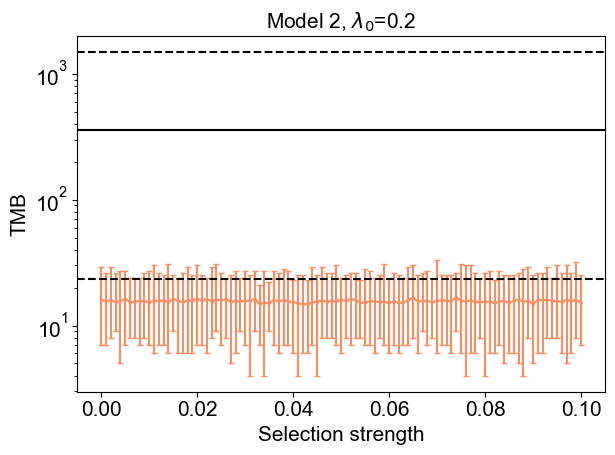

<Figure size 640x480 with 0 Axes>

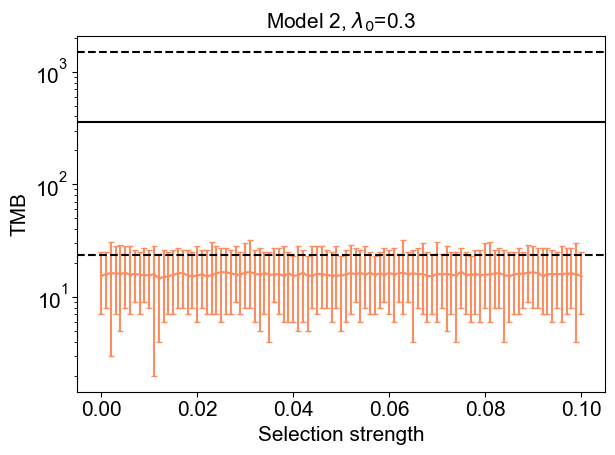

<Figure size 640x480 with 0 Axes>

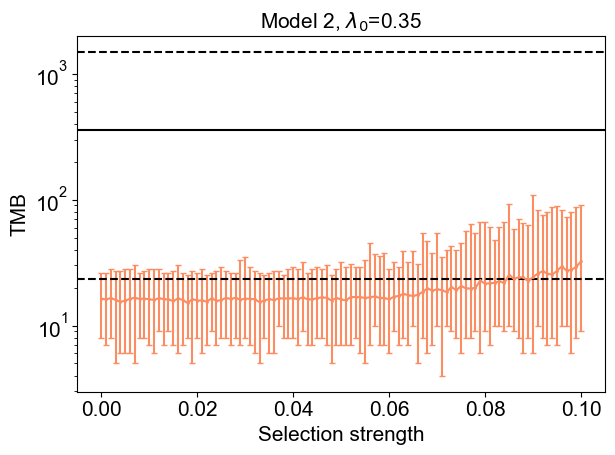

<Figure size 640x480 with 0 Axes>

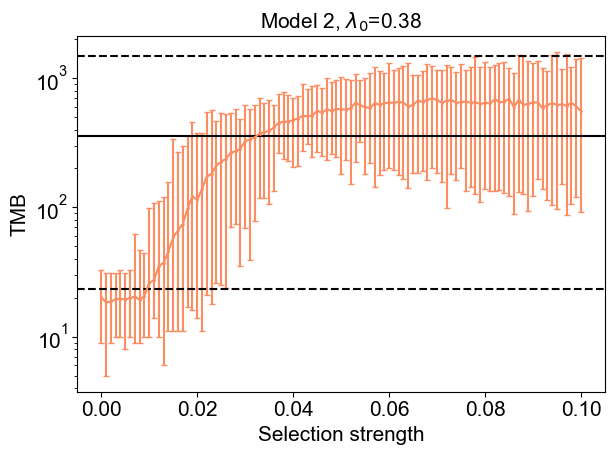

<Figure size 640x480 with 0 Axes>

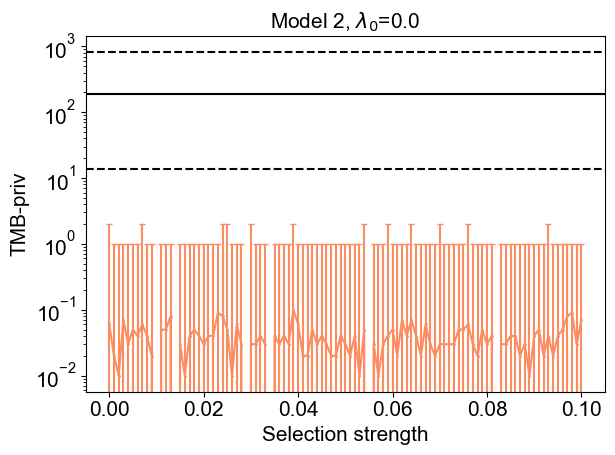

<Figure size 640x480 with 0 Axes>

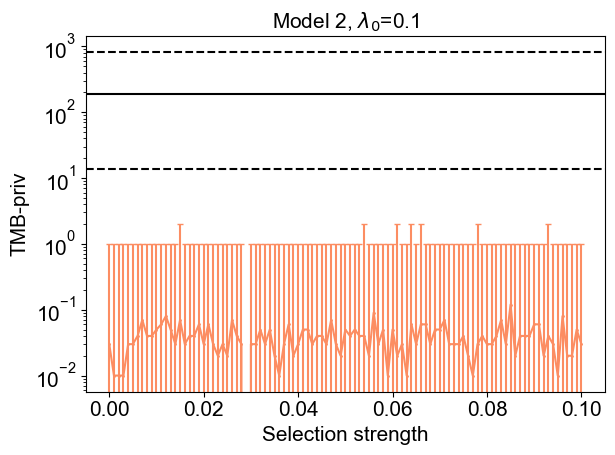

<Figure size 640x480 with 0 Axes>

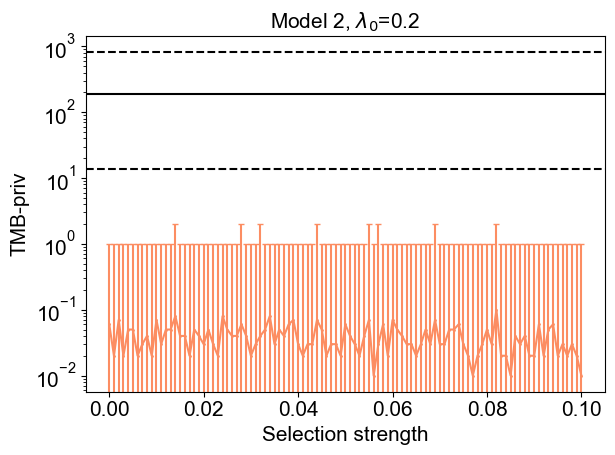

<Figure size 640x480 with 0 Axes>

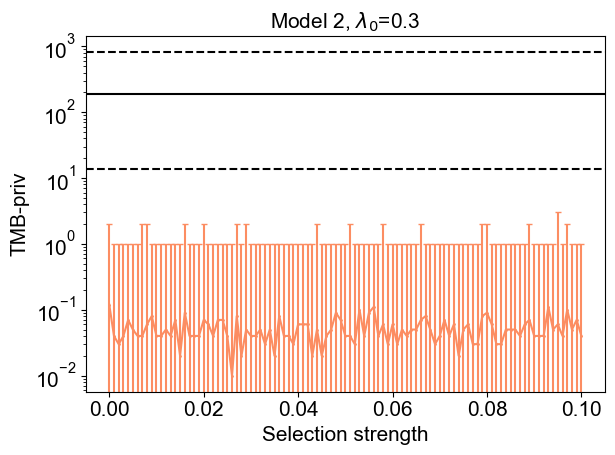

<Figure size 640x480 with 0 Axes>

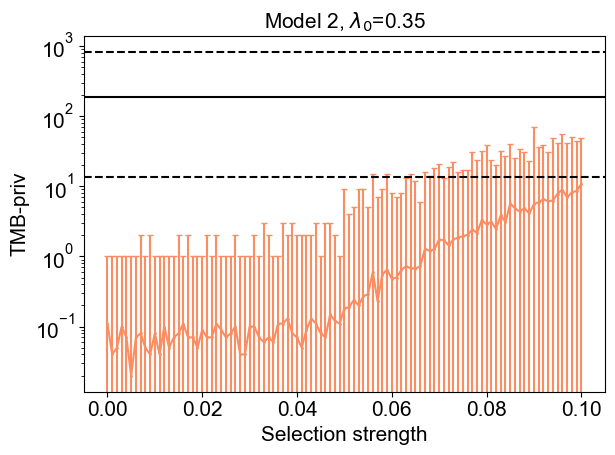

<Figure size 640x480 with 0 Axes>

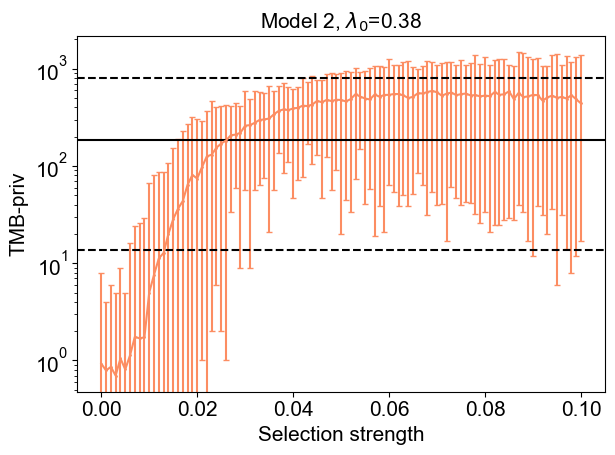

<Figure size 640x480 with 0 Axes>

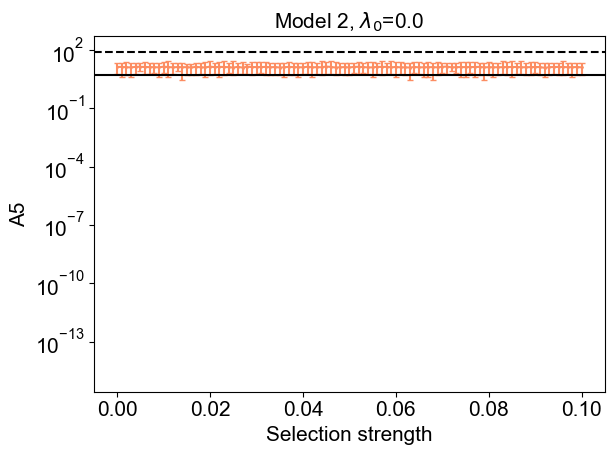

<Figure size 640x480 with 0 Axes>

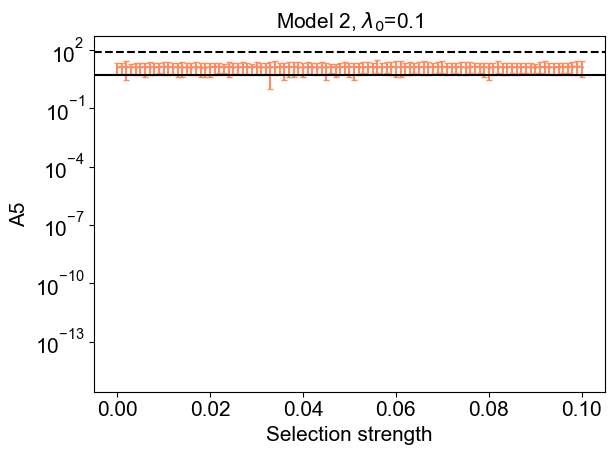

<Figure size 640x480 with 0 Axes>

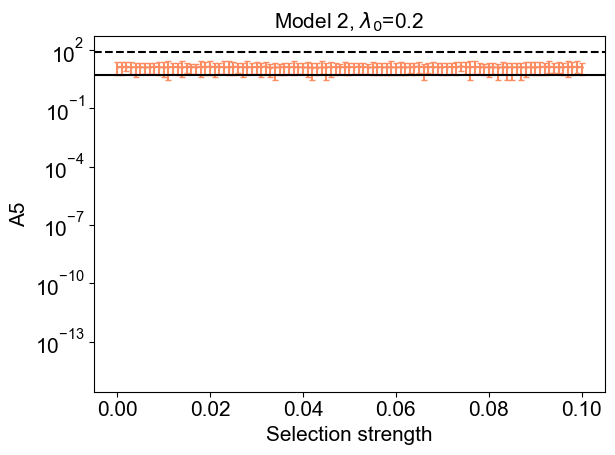

<Figure size 640x480 with 0 Axes>

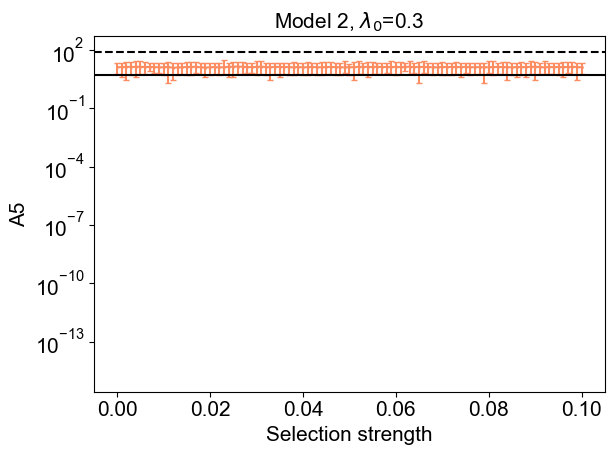

<Figure size 640x480 with 0 Axes>

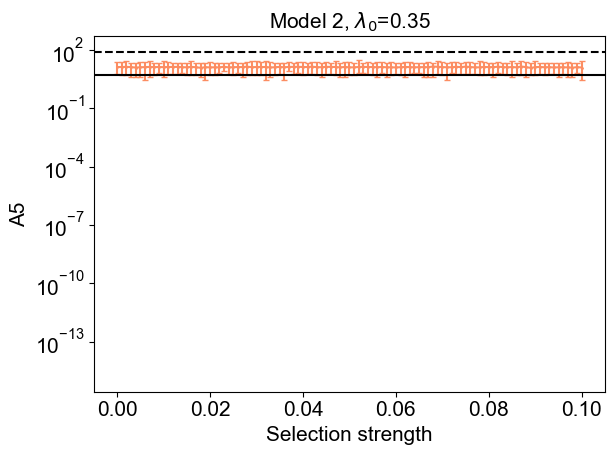

<Figure size 640x480 with 0 Axes>

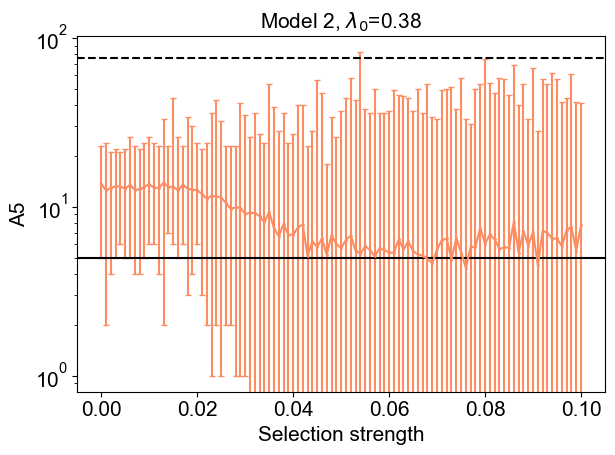

<Figure size 640x480 with 0 Axes>

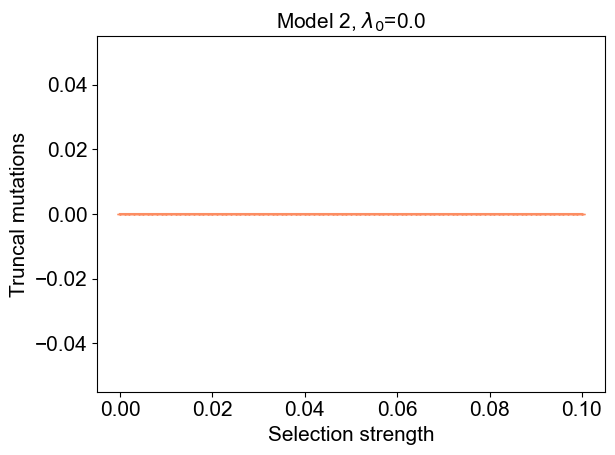

<Figure size 640x480 with 0 Axes>

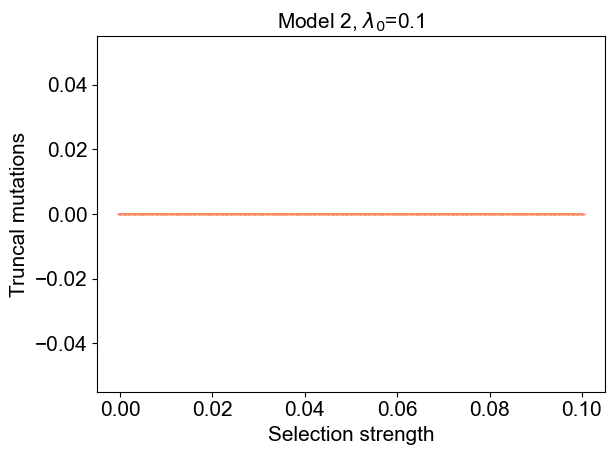

<Figure size 640x480 with 0 Axes>

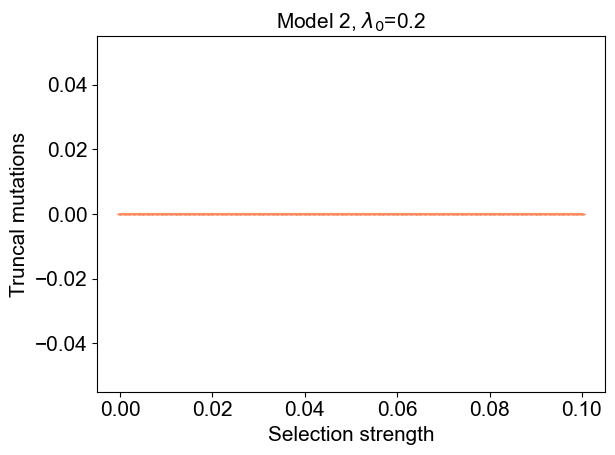

<Figure size 640x480 with 0 Axes>

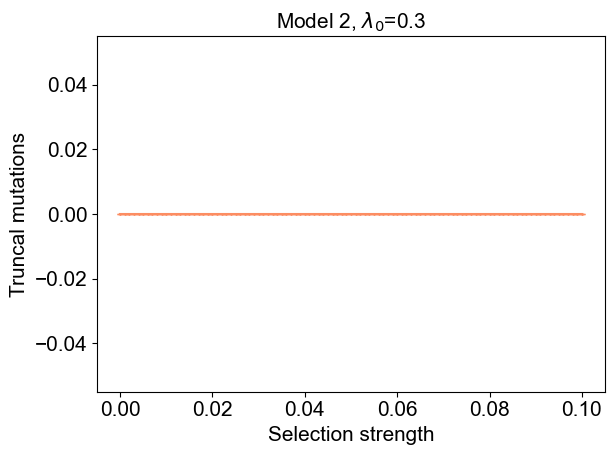

<Figure size 640x480 with 0 Axes>

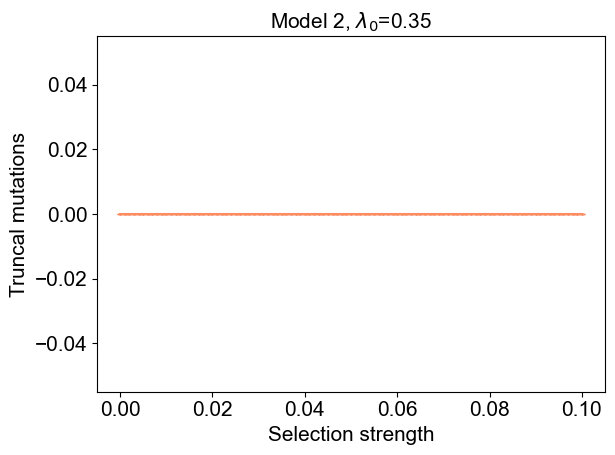

<Figure size 640x480 with 0 Axes>

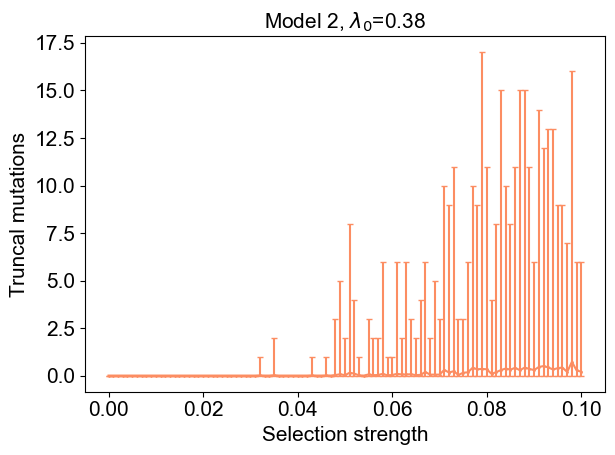

<Figure size 640x480 with 0 Axes>

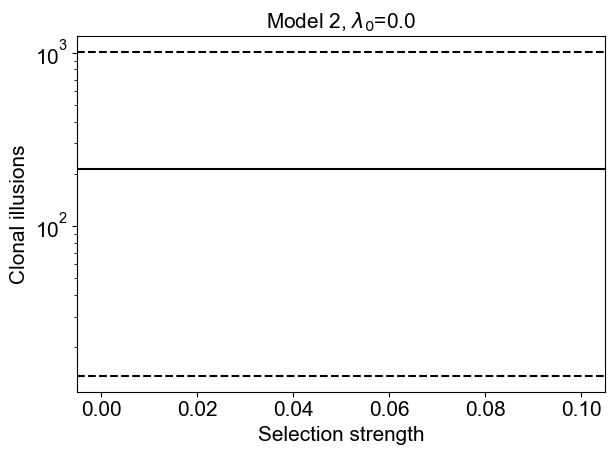

<Figure size 640x480 with 0 Axes>

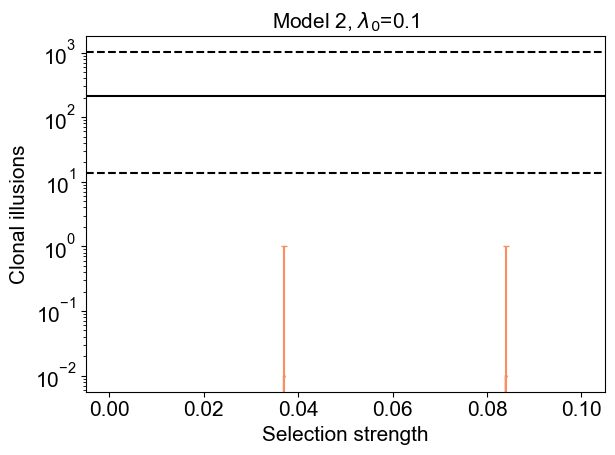

<Figure size 640x480 with 0 Axes>

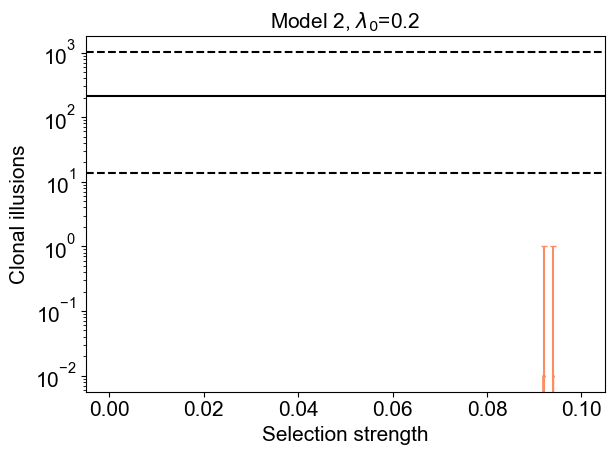

<Figure size 640x480 with 0 Axes>

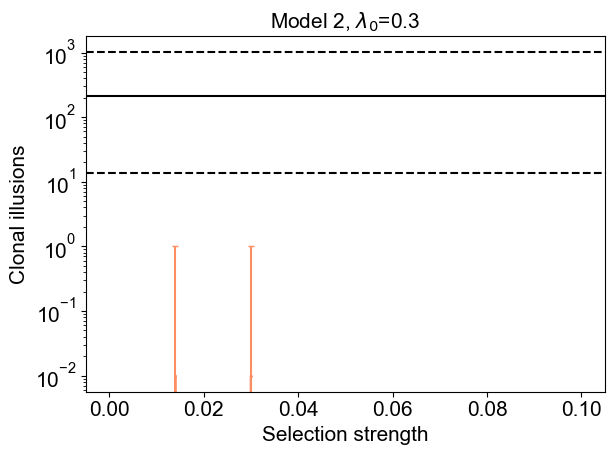

<Figure size 640x480 with 0 Axes>

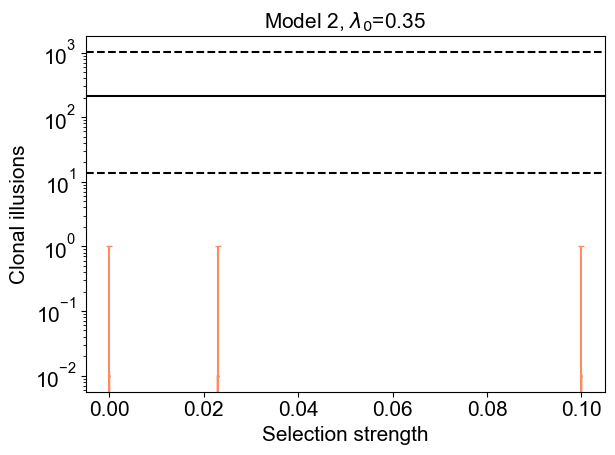

<Figure size 640x480 with 0 Axes>

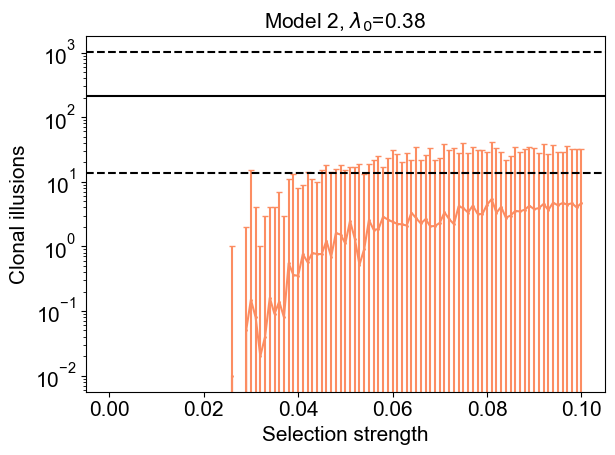

<Figure size 640x480 with 0 Axes>

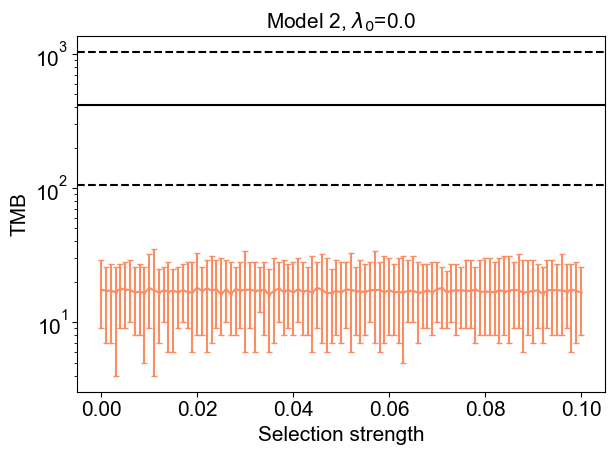

<Figure size 640x480 with 0 Axes>

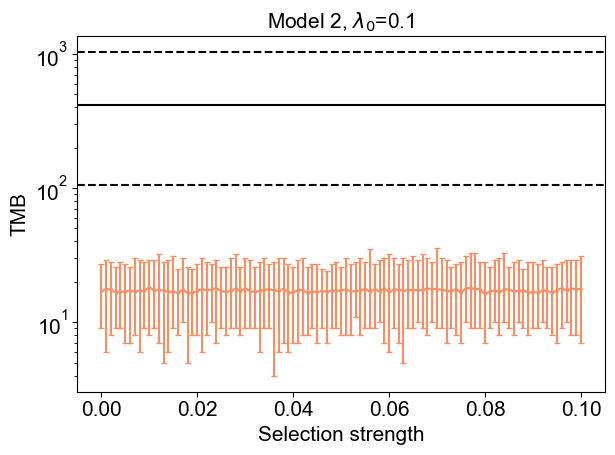

<Figure size 640x480 with 0 Axes>

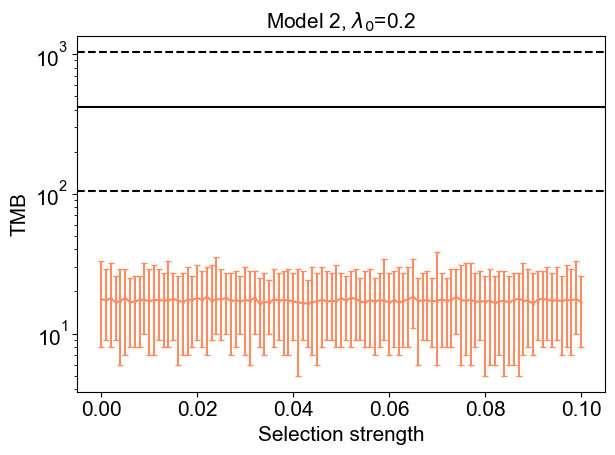

<Figure size 640x480 with 0 Axes>

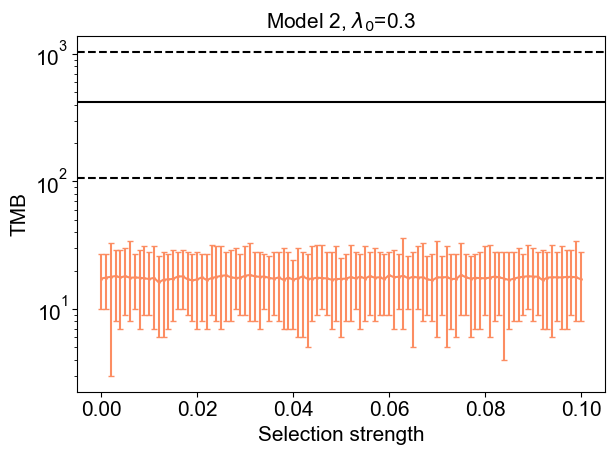

<Figure size 640x480 with 0 Axes>

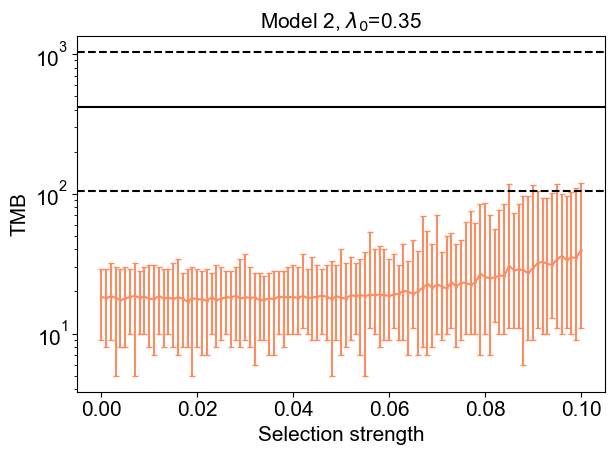

<Figure size 640x480 with 0 Axes>

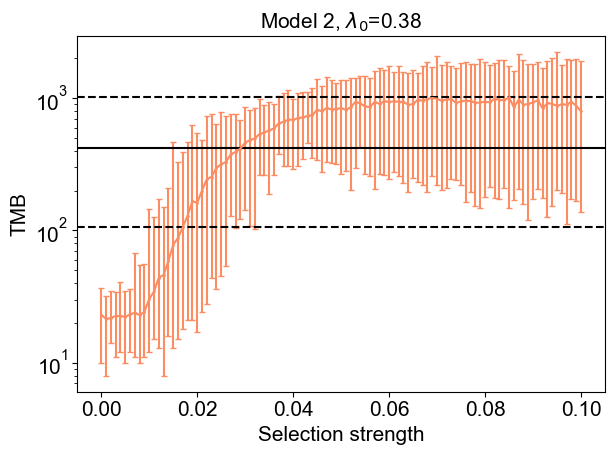

<Figure size 640x480 with 0 Axes>

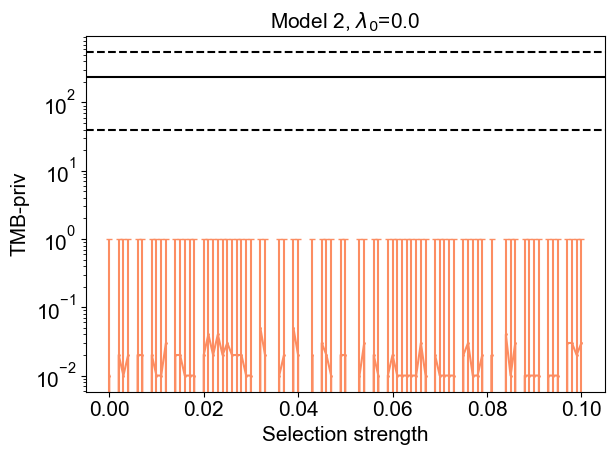

<Figure size 640x480 with 0 Axes>

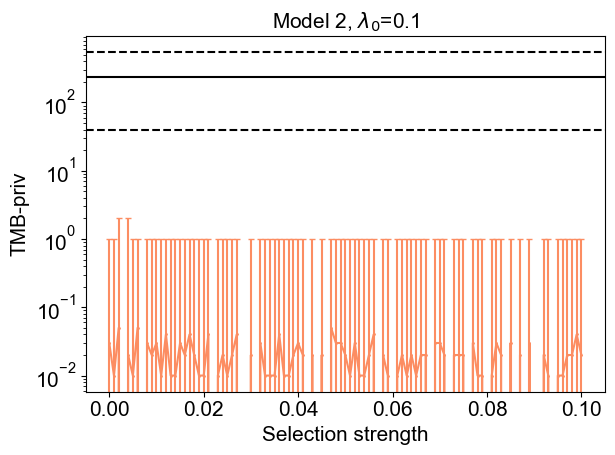

<Figure size 640x480 with 0 Axes>

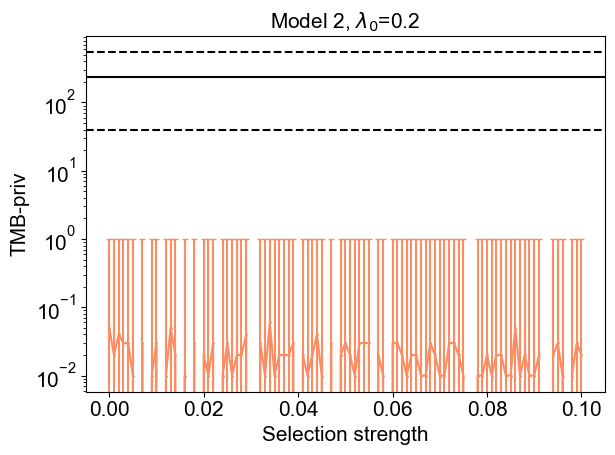

<Figure size 640x480 with 0 Axes>

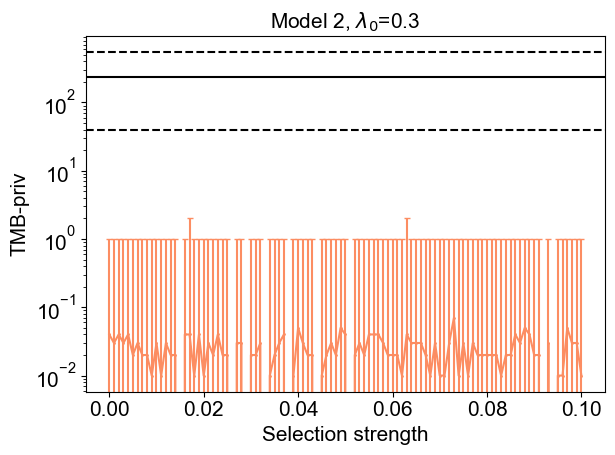

<Figure size 640x480 with 0 Axes>

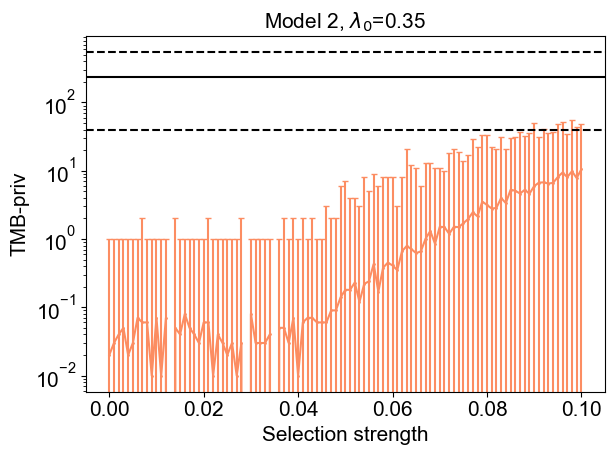

<Figure size 640x480 with 0 Axes>

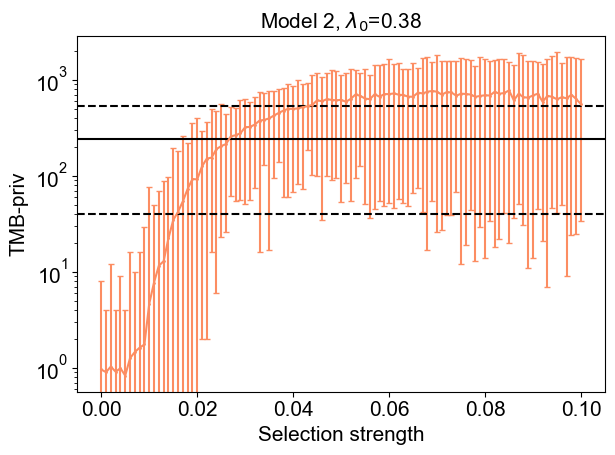

<Figure size 640x480 with 0 Axes>

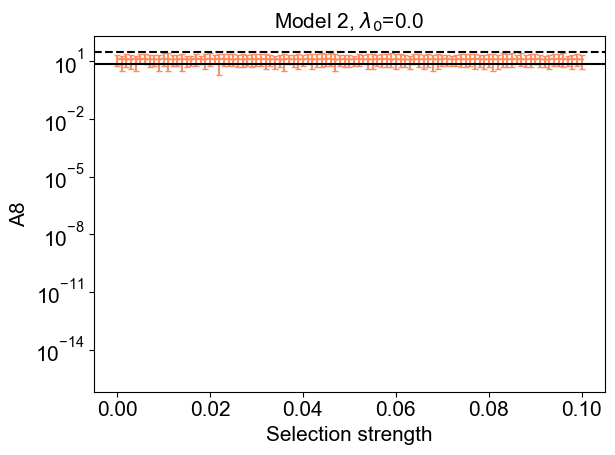

<Figure size 640x480 with 0 Axes>

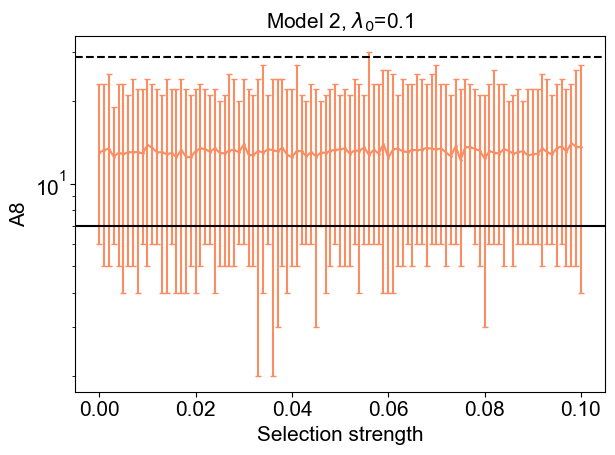

<Figure size 640x480 with 0 Axes>

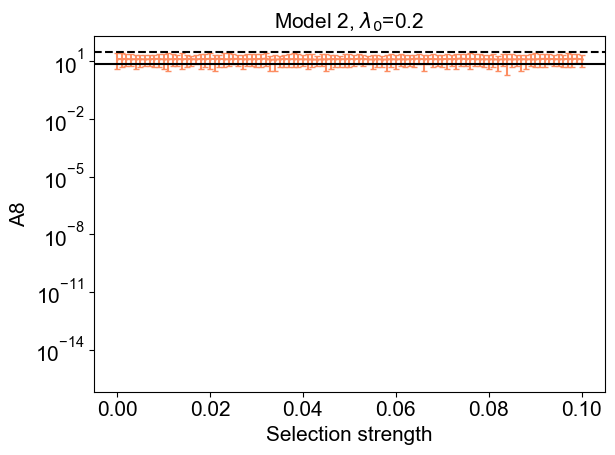

<Figure size 640x480 with 0 Axes>

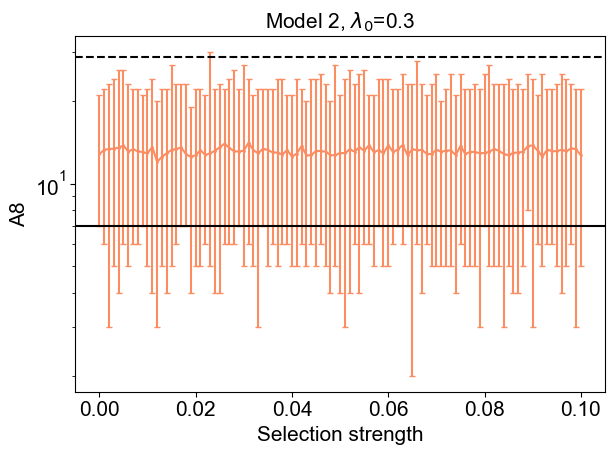

<Figure size 640x480 with 0 Axes>

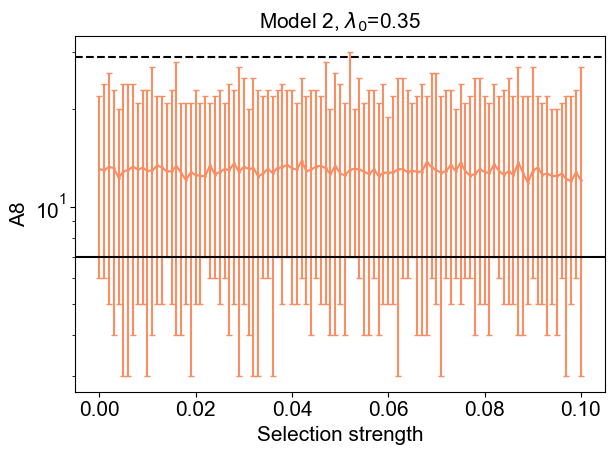

<Figure size 640x480 with 0 Axes>

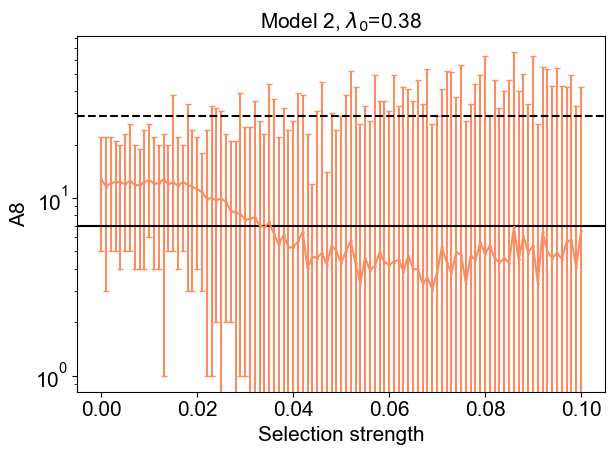

<Figure size 640x480 with 0 Axes>

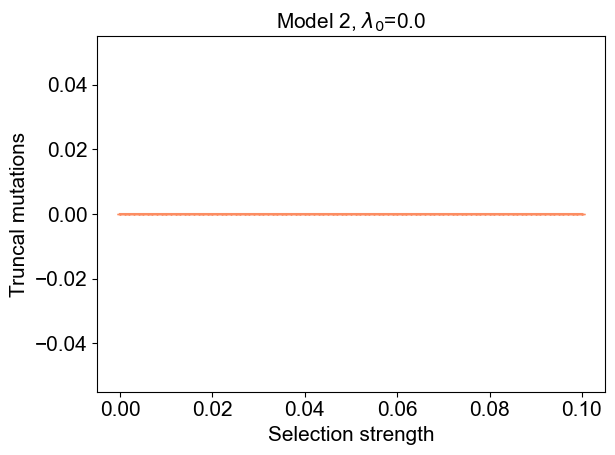

<Figure size 640x480 with 0 Axes>

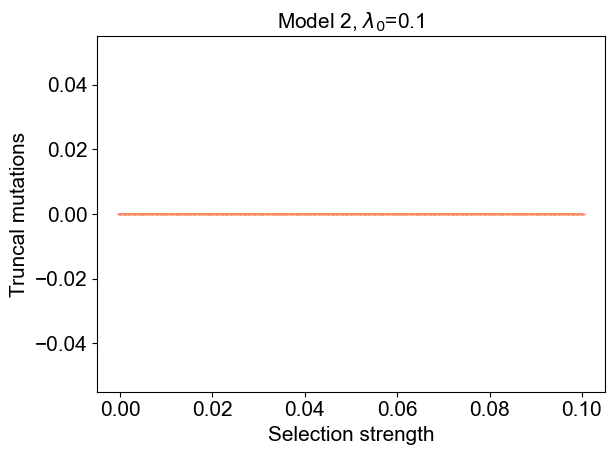

<Figure size 640x480 with 0 Axes>

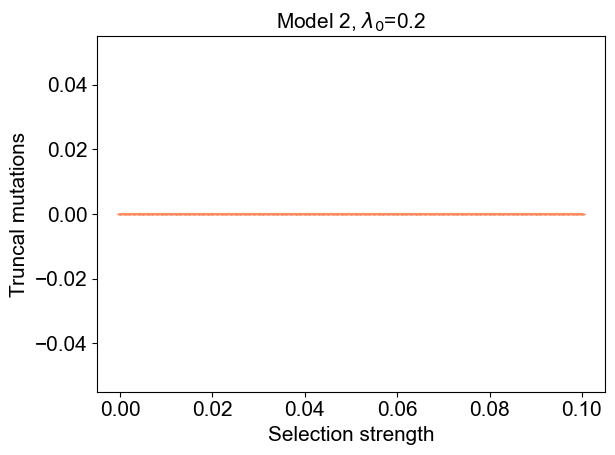

<Figure size 640x480 with 0 Axes>

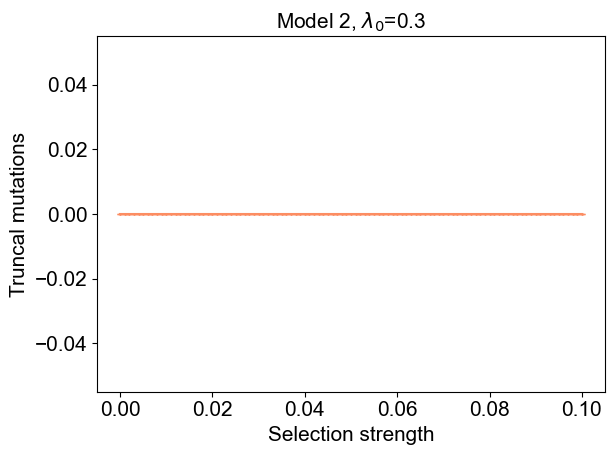

<Figure size 640x480 with 0 Axes>

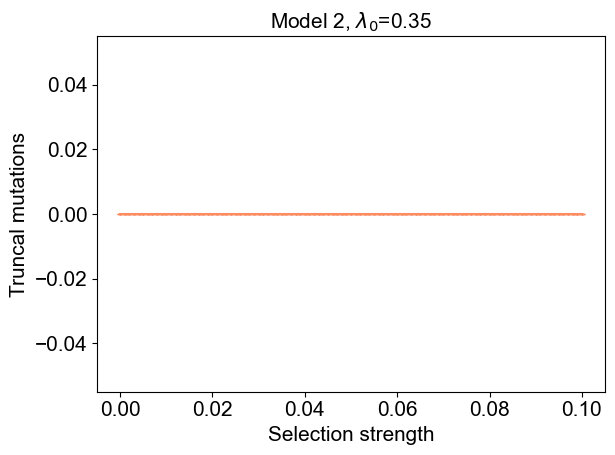

<Figure size 640x480 with 0 Axes>

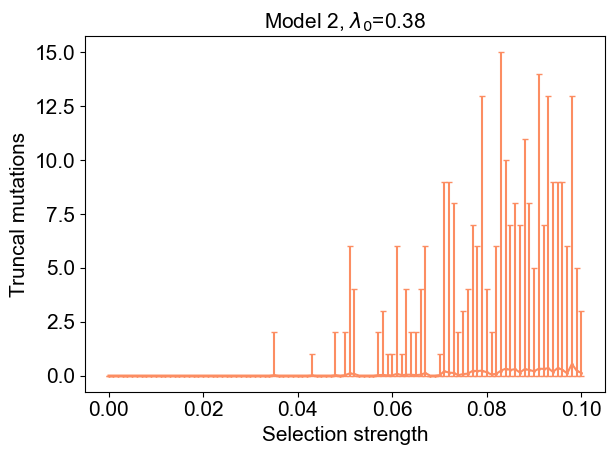

<Figure size 640x480 with 0 Axes>

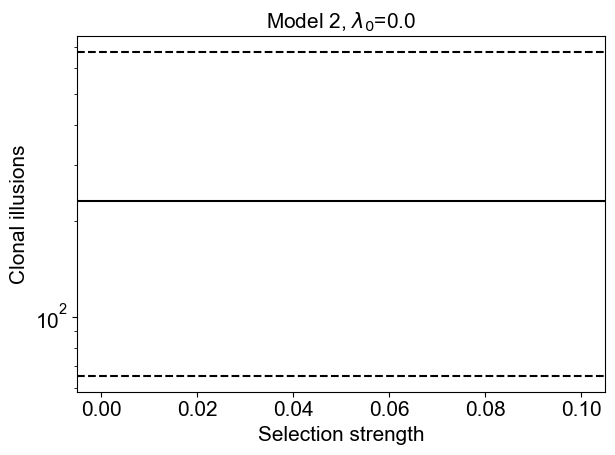

<Figure size 640x480 with 0 Axes>

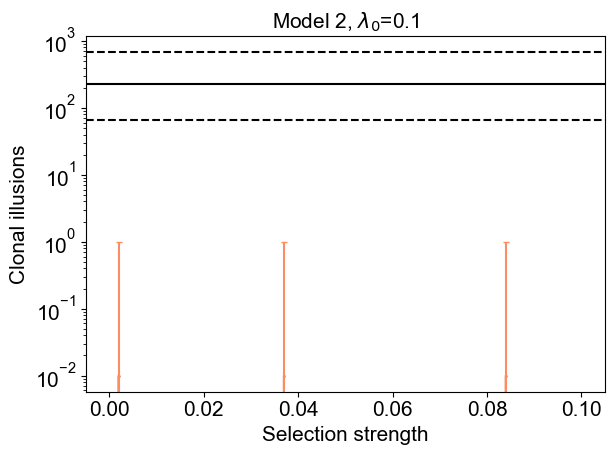

<Figure size 640x480 with 0 Axes>

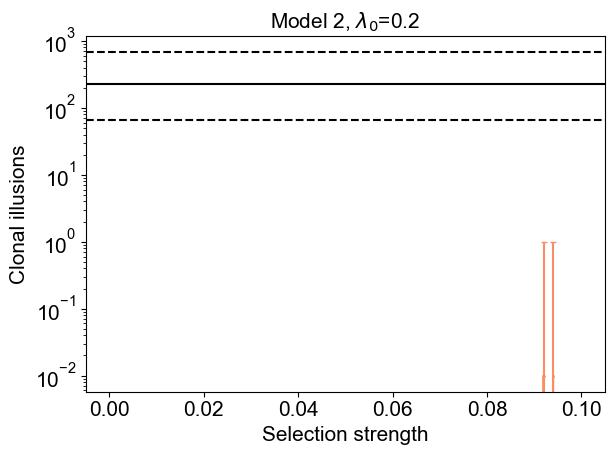

<Figure size 640x480 with 0 Axes>

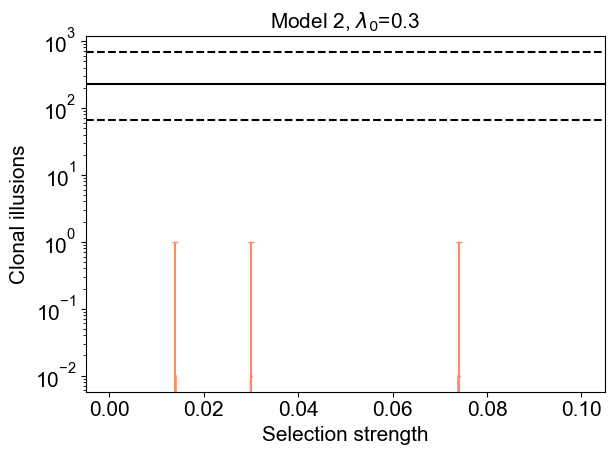

<Figure size 640x480 with 0 Axes>

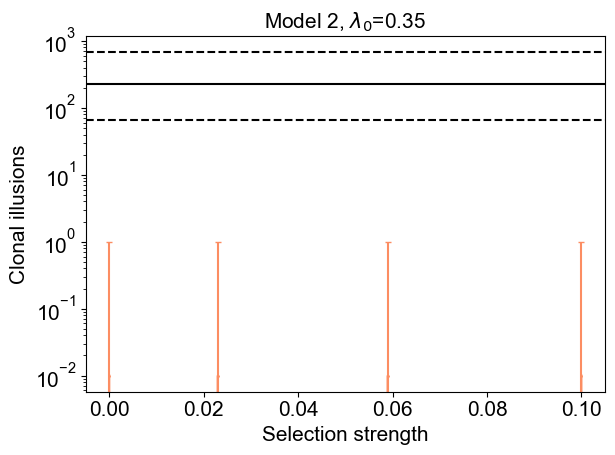

<Figure size 640x480 with 0 Axes>

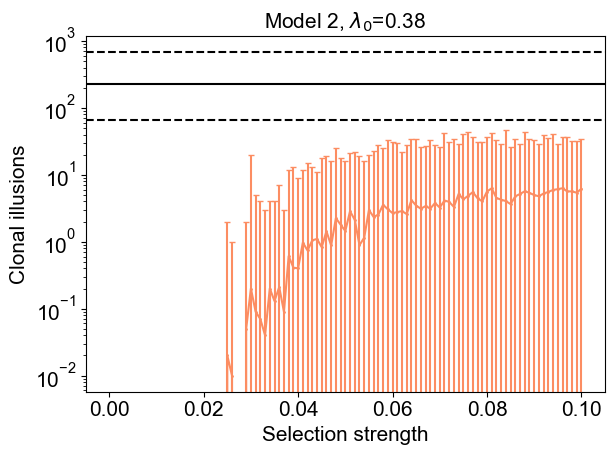

<Figure size 640x480 with 0 Axes>

In [25]:
#plot_variance_with_selection_group("14Aug", "model_2", "Direct-competition, continual expansion model", "model_2", selections, title_size=12)
for no_samples in [2, 5, 8]:         
    plot_variance_with_selection_ind("14Aug", "model_2", "Model 2", "model_2", selections,  no_samples, color="#fc8d62", stat_indices = [0, 1, 2*no_samples, 2*no_samples+2, 2*no_samples+1])

Now for model 3 (varies with mut_rate not death rate).

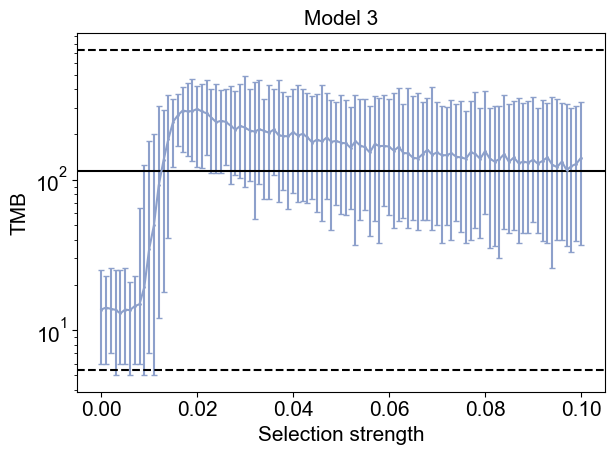

<Figure size 640x480 with 0 Axes>

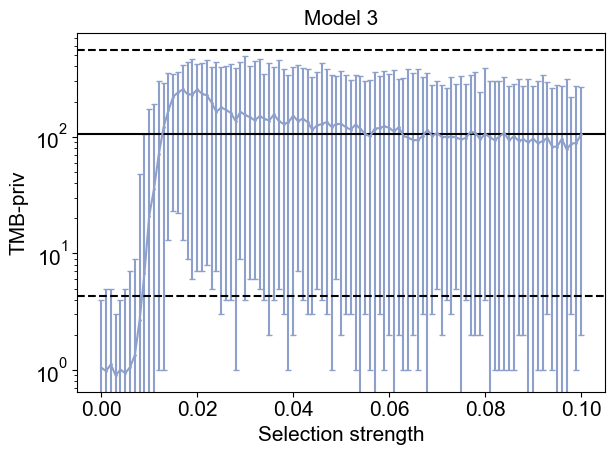

<Figure size 640x480 with 0 Axes>

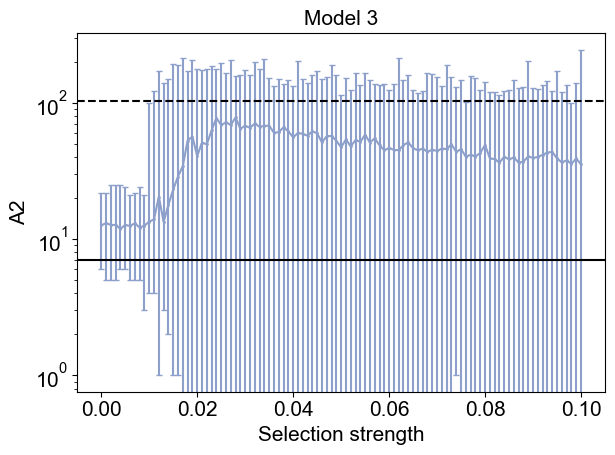

<Figure size 640x480 with 0 Axes>

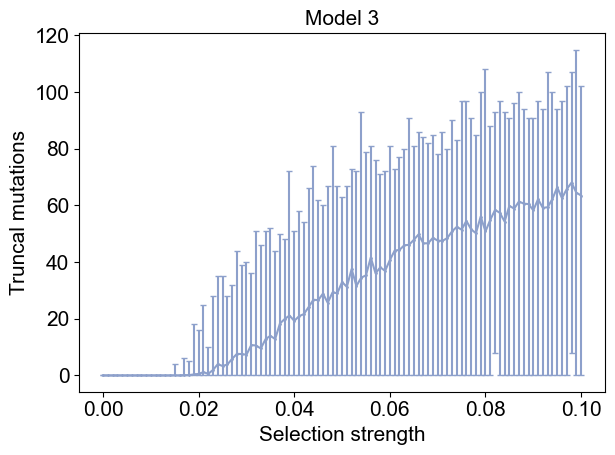

<Figure size 640x480 with 0 Axes>

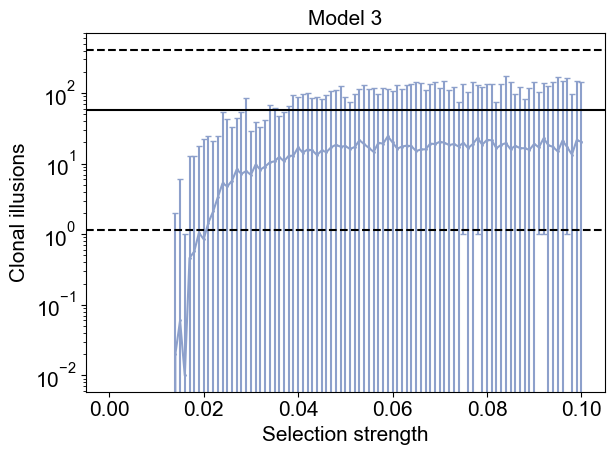

<Figure size 640x480 with 0 Axes>

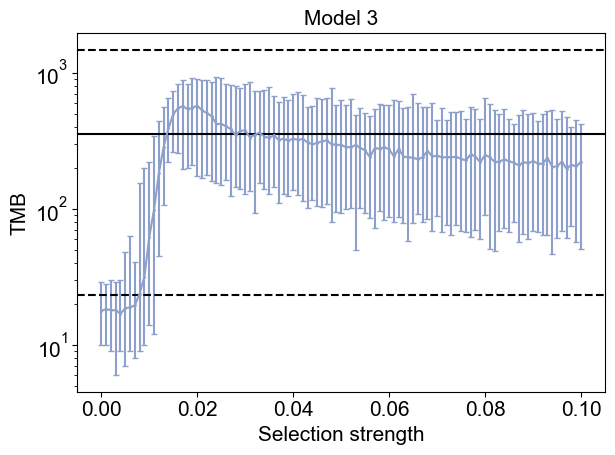

<Figure size 640x480 with 0 Axes>

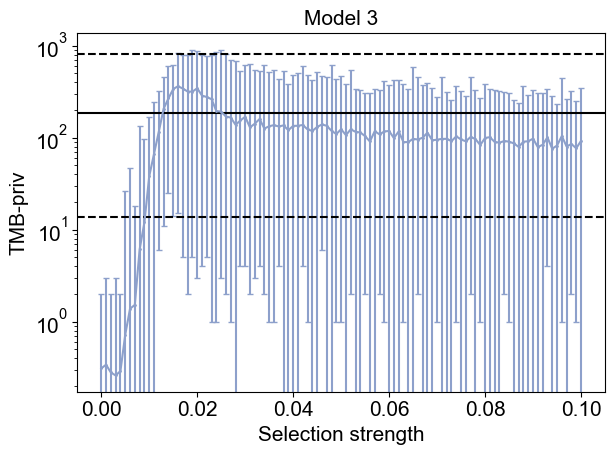

<Figure size 640x480 with 0 Axes>

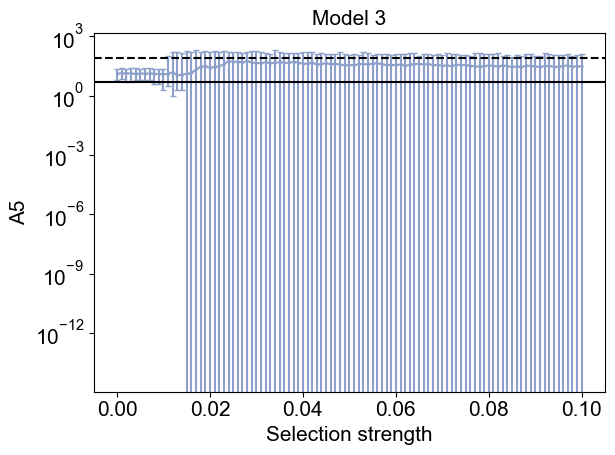

<Figure size 640x480 with 0 Axes>

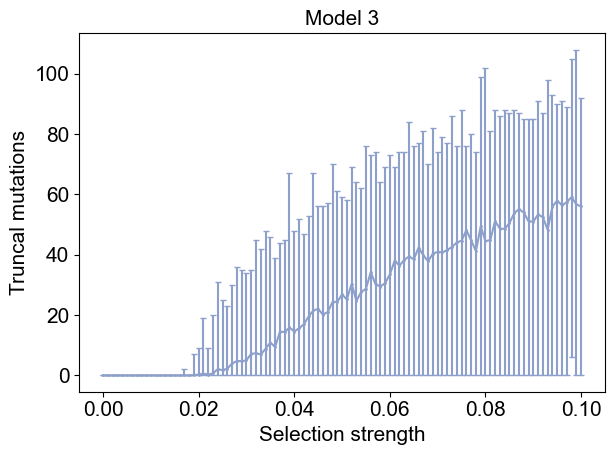

<Figure size 640x480 with 0 Axes>

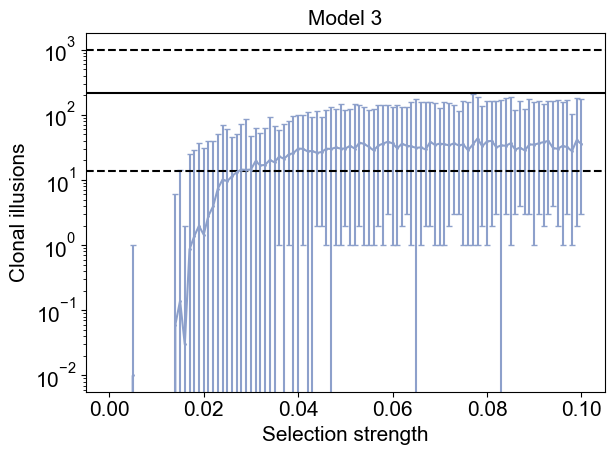

<Figure size 640x480 with 0 Axes>

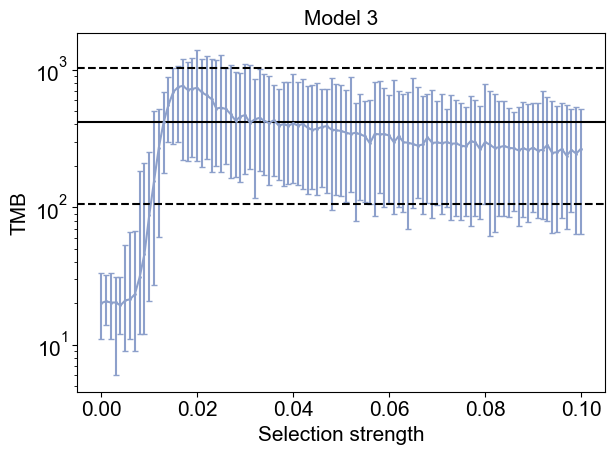

<Figure size 640x480 with 0 Axes>

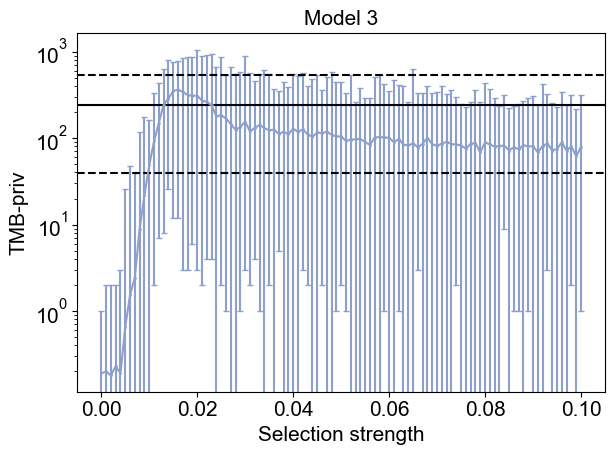

<Figure size 640x480 with 0 Axes>

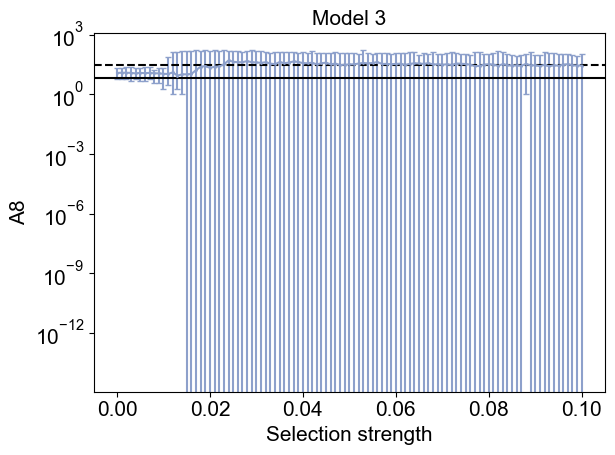

<Figure size 640x480 with 0 Axes>

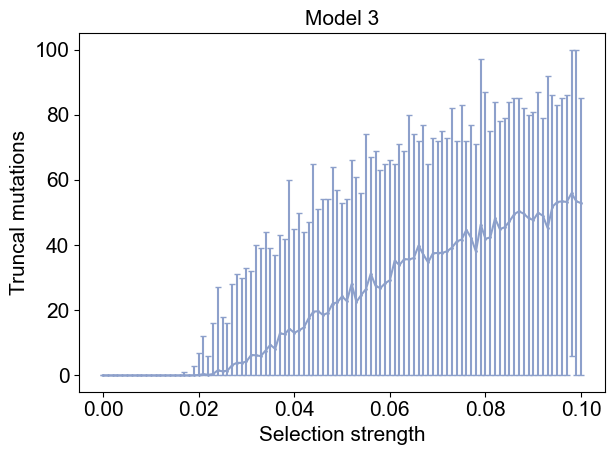

<Figure size 640x480 with 0 Axes>

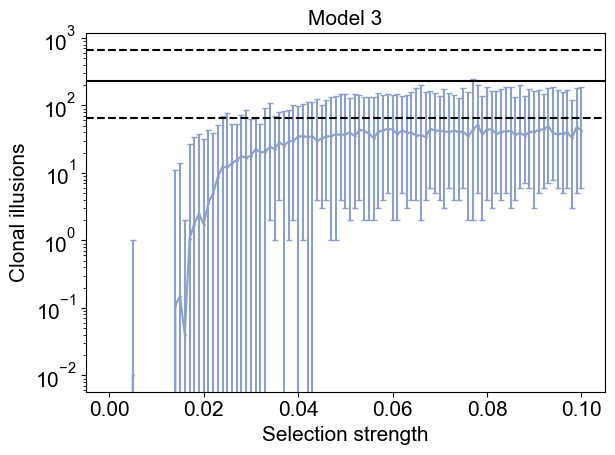

<Figure size 640x480 with 0 Axes>

In [26]:

#plot_variance_with_selection_group("14Aug", "model_3", "Two-stage direct competition model", "model_3", selections, categ_symbol=r'$\mu$', categ_vary=[0.4, 0.6], load_names=["0.4", "0.6"], div_color_list= ["#d53e4f", "#3288bd"])
for no_samples in [2, 5, 8]:           
    plot_variance_with_selection_ind("14Aug", "model_3", "Model 3", "model_3", selections, no_samples, stat_indices = [0, 1, 2*no_samples, 2*no_samples+2, 2*no_samples+1], color="#8da0cb", categ_symbol=r'$\mu$', categ_vary=[0.4], load_names=["0.4"], use_legend=False, use_suffix=False)


Plot average values with samples (no point including indicator lines as these vary with sample size.)

Plot heatmaps. What fraction of TRACERx data is covered per death rate and in total, for each model? Also for all 3 models.


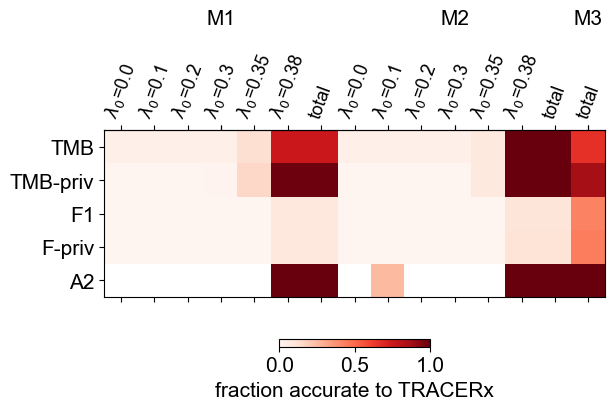

<Figure size 640x480 with 0 Axes>

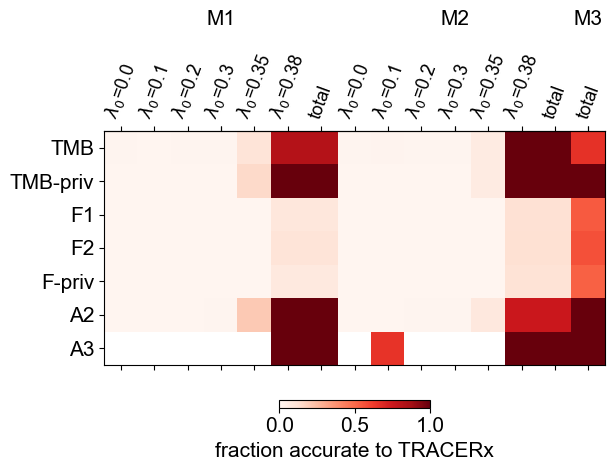

<Figure size 640x480 with 0 Axes>

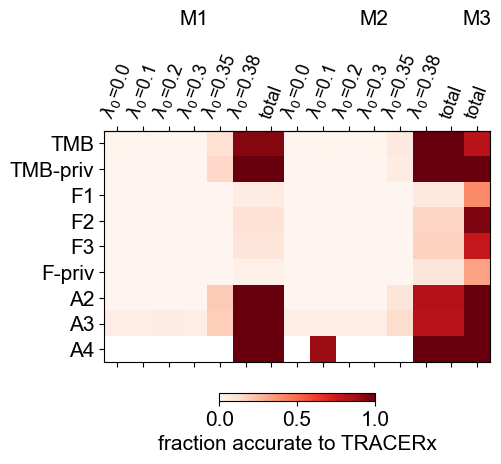

<Figure size 640x480 with 0 Axes>

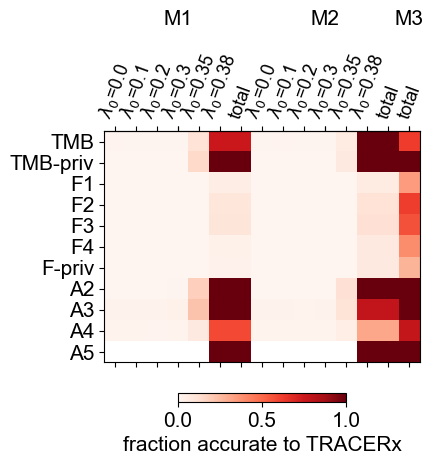

<Figure size 640x480 with 0 Axes>

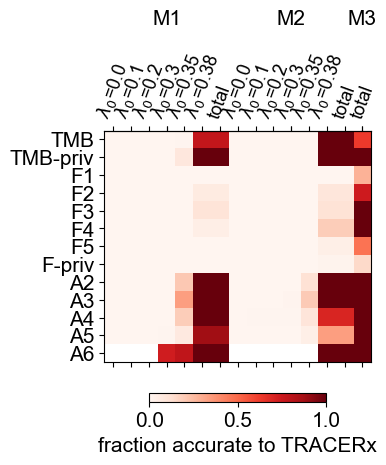

<Figure size 640x480 with 0 Axes>

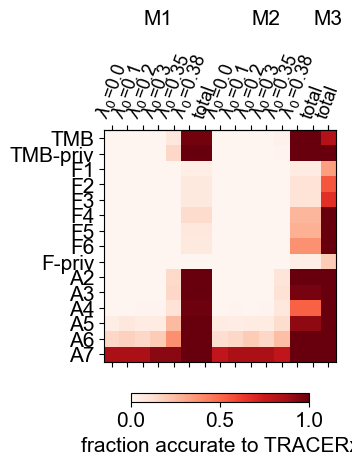

<Figure size 640x480 with 0 Axes>

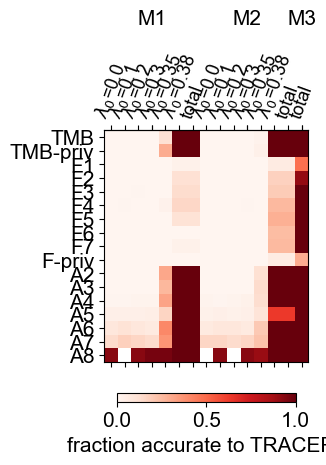

<Figure size 640x480 with 0 Axes>

In [31]:
#plot fraction of TRACERx range covered
def range_covered(max_, min_, p5, p95):
    if min_ <= p5 and max_ >= p95:
        return 1
        #print("decided 1", max_, min_, p5, p95)
    else:
        if min_ <= p5:
            res = max((max_-p5)/(p95-p5), 0)
            #print("min less", max_, min_, p5, p95, res)
            return res
            #returns fraction of range covered if max_ > p5
        else:
            if max_ >= p95:
                res = max((p95-min_)/(p95-p5), 0)
                #print("max more", max_, min_, p5, p95, res)
                return res


def return_TRACERx_heatmap(prefix, model, title, savetitle, selections, no_samples, categ_symbol=r'$\lambda_0$', categ_vary=[0.0, 0.1, 0.2, 0.3, 0.35, 0.38], load_names=["no_death", "low_death", "mid_death", "high_death", "vhigh_death", "highest_death"], use_colorbar=False, use_xlabel=True, use_ylabel=False, use_total=True):
    unique_sel_values = np.unique(selections)
    stat_names = ["TMB", "TMB-priv"] + ["F"+str(s) for s in range(1, no_samples)]+ ["F-priv"] + ["A"+str(s) for s in range(2, no_samples+1)]
    ordered_labels = [model+"/"+prefix+"_"+name for name in load_names]
    cruk_tumour_stats = np.load("cruk_"+str(no_samples)+"_samples_stat.npy", allow_pickle=True)
    perc_of_range_covered = np.zeros((len(categ_vary)+1, len(stat_names))) #fraction of range covered by all sims- per death rate + total and sum stat
    #here rows are death rates and cols are stats
    labels_for_display = [categ_symbol+"="+str(var) for var in categ_vary]
    for n, name in enumerate(stat_names):
        if n < len(stat_names):
            overall_min, overall_max = np.inf, 0
            for l, label in enumerate(ordered_labels):
                stats = np.load(base_filepath+label+"_"+str(no_samples)+"_samples_stats.npy", allow_pickle=True)
                params = np.load(base_filepath+label+"_"+str(no_samples)+"_samples_params.npy", allow_pickle=True)
                p95 = np.percentile(cruk_tumour_stats[:, n], 95)
                p5 = np.percentile(cruk_tumour_stats[:, n], 5)
                relevant_stats = stats[:, n]
                min_, max_ = np.min(relevant_stats), np.max(relevant_stats) 
                overall_min, overall_max = min(overall_min, min_), max(overall_max, max_)
                perc_of_range_covered[l][n] = range_covered(max_, min_, p5, p95)
            perc_of_range_covered[len(categ_vary)][n] = range_covered(overall_max, overall_min, p5, p95)
    if use_total:
        return perc_of_range_covered
    else:
        return np.array([perc_of_range_covered[0]])
        # fig, ax = plt.subplots()
        # if use_total:
        #     im=ax.matshow(perc_of_range_covered.T, cmap=mpl.cm.Reds, vmin=0, vmax=1)
        # else:
        #     im=ax.matshow(perc_of_range_covered[:len(categ_vary)].T, cmap=mpl.cm.Reds, vmin=0, vmax=1)
        # #plt.colorbar(im, vmin=0, vmax=1)
        # if use_xlabel:
        #     ax.set_xticks(range(len(ordered_labels)+1), labels_for_display+["total"] if use_total else labels_for_display, fontsize=15, rotation=60)
        # else:
        #     ax.set_xticks([], [])
        # if use_ylabel:
        #     ax.set_yticks(range(len(stat_names)-1), stat_names[:len(stat_names)-1])
        # else:
        #     ax.set_yticks([], [])
        # if use_colorbar:
        #     plt.colorbar(im, pad=0.2, shrink=0.6)
        # plt.title(title, fontsize=15) #leave samples for caption
        # plt.tight_layout()
        # plt.show()
        # fig.savefig(base_filepath+"/figs_1410"+"/"+savetitle+"_"+str(no_samples)+"_TRACERx_range_covered_heatmap.pdf", dpi=300)
        # plt.clf()


for no_samples in range(2, 9):
    
    categ_vary=[0.0, 0.1, 0.2, 0.3, 0.35, 0.38]
    labels_for_display = [r'$\lambda_0$'+"="+str(var) for var in categ_vary]
    stat_names = ["TMB", "TMB-priv"] + ["F"+str(s) for s in range(1, no_samples)]+ ["F-priv"] + ["A"+str(s) for s in range(2, no_samples+1)]
    
    m1 = return_TRACERx_heatmap("11Aug", "model_1", "Model 1", "model_1", selections, no_samples, use_ylabel=True)
    m2 = return_TRACERx_heatmap("14Aug", "model_2", "Model 2", "model_2", selections, no_samples)
    m3 = return_TRACERx_heatmap("14Aug", "model_3", "Model 3", "model_3", selections, no_samples, categ_symbol=r'$\mu$', categ_vary=[0.4], load_names=["0.4"], use_xlabel=False, use_total=False, use_colorbar=True)
    mat = np.concatenate((m1, m2, m3))
    #print(m1.shape, m2.shape, m3.shape)
    fig, ax = plt.subplots()
    im=ax.matshow(mat.T, cmap=mpl.cm.Reds, vmin=0, vmax=1)
    
    xlabels = (labels_for_display+["total"])*2 + ["total"]
    #print(len(xlabels), len(mat))
    #plt.colorbar(im, vmin=0, vmax=1)
    ax.set_xticks(range(len(xlabels)), xlabels, fontsize=13, rotation=70)
    ax.set_yticks(range(len(stat_names)), stat_names)
    ax2 =ax.secondary_xaxis(location='top')
    ax2.set_xticks([3, 10, 14], labels=["M1", "M2", "M3"])
    #ax2.axhline(y=-10, xmin=0.5, xmax=6.5, color='black')
    #ax2.axhline(y=-10, xmin=7.5, xmax=13.5, color='black')
    ax2.tick_params(axis='x', which='major', pad=70)
    plt.colorbar(im, pad=0.1, shrink=0.3, location='bottom', label="fraction accurate to TRACERx")
    #plt.title(title, fontsize=15) #leave samples for caption
    plt.tight_layout()
    plt.show()
    fig.savefig(base_filepath+"/figs_1410"+"/overall_"+str(no_samples)+"_TRACERx_range_covered_heatmap.pdf", dpi=300)
    plt.clf()


Now train the ABC pipeline to infer selection strength for each model.

In [32]:

#train a regressor to predict selection and death rate for a particular model
def train_model(prefix, model_name, no_samples, objective='reg:logistic', load_names=["no_death", "low_death", "mid_death", "high_death", "vhigh_death", "highest_death"], test_size=0.5, single_var=False):
    #print(objective)
    ordered_labels = [model_name+"/"+prefix+"_"+name for name in load_names]
    Xs, ys = [], []
    for l, label in enumerate(ordered_labels):
        stats = np.load(base_filepath+label+"_"+str(no_samples)+"_samples_stats.npy", allow_pickle=True)
        params = np.load(base_filepath+label+"_"+str(no_samples)+"_samples_params.npy", allow_pickle=True)
        #exclude clonal mutations
        no_stats = len(stats[0])
        stats = stats[:, :no_stats-1]
        if single_var:
            params = params[:, 0].reshape(-1, 1)#controls whether we're trying to guess both params or just selection
        if len(Xs) == 0:
            Xs = stats
            ys = params
        else:
            Xs, ys = np.concatenate((Xs, stats)), np.concatenate((ys, params))
    #split test and train dataset
    X_train, X_test, y_train, y_test = train_test_split(Xs, ys, test_size=test_size) #we generally train on half and use the other half for inference
    model = xgb.XGBRegressor(objective=objective, importance_type='gain')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #print(X_train.shape, y_train.shape, X_test.shape, y_test.shape, y_pred.shape)
    # fig, ax = plt.subplots(figsize=(10, 10))
    # ax.scatter(y_test[:, 0], y_pred[:, 0])
    # plt.xlabel("actual selection")
    # plt.ylabel("predicted selection")
    # plt.show()
    return model, y_test, y_pred, X_test


#now use this to test how effective it is using leave-one-out analysis
#use roughly half the cohort (60k for model 1 and 2, 10k for model 3) to train it, half to test 
def test_abc(model, y_test, y_pred, num_tests=10000, threshold=0.01):
    num_sims, num_var = y_test.shape
    adj_num_tests = min(num_tests, num_sims) 
    indices_to_test = np.random.choice(num_sims, size=adj_num_tests, replace=False) #choose experiments to test
    actual, inferred_av = np.zeros((adj_num_tests, num_var)), np.zeros((adj_num_tests, num_var)) #record actual parameters- the average value is the inferred one
    k = int(threshold*(num_sims-1))+1 #number of simulations to take
    for n, index in enumerate(indices_to_test):
        pred_vals = y_pred[index]
        actual[n] = y_test[index] #real value we're aiming at
        y_test_, y_pred_ = np.delete(y_test, index, axis=0), np.delete(y_pred, index, axis=0)
        #use L2 error
        dist_from_target = np.sum((y_pred_ - pred_vals)**2, axis=1) if num_var > 1 else (y_pred_ - pred_vals)**2 #l2(y_pred_, pred_vals) #L2 distance
        order = np.argpartition(dist_from_target, k) #kth smallest elements will be at position k
        vals = y_test_[order[:k]]
        #if I have the shape right
        inferred_av[n] = np.average(vals, axis=0)
        
    return actual, inferred_av, num_var


def plot_abc_accuracy(prefix, model_name, model_title, no_samples, categ_symbol=r'$\lambda_0$', categ_vary=[0.0, 0.1, 0.2, 0.3, 0.35, 0.38], objective='reg:logistic', objective_name='logistic', 
                      load_names=["no_death", "low_death", "mid_death", "high_death", "vhigh_death", "highest_death"], color="#66c2a5", 
                      test_size=0.5, num_tests=10000, threshold=0.01, var_names=['selection', 'death rate'], use_yticks=False, single_var=False, make_sum_stat_comparison=False, num_quadrants=5):
    model, y_test, y_pred, X_test = train_model(prefix, model_name, no_samples, objective, load_names=load_names, test_size=test_size, single_var=single_var)
    actual, inferred, num_var = test_abc(model, y_test, y_pred, num_tests=num_tests, threshold=threshold)
    stat_names = ["TMB", "TMB-priv"] + ["F"+str(s) for s in range(1, no_samples)]+ ["F-priv"] + ["A"+str(s) for s in range(2, no_samples+1)]
    for n in range(len(var_names)):
        actual_vals, inferred_vals = actual[:, n], inferred[:, n]
        uniq_vals = np.unique(actual_vals)
        av_infr, std_infr, std_error = np.zeros_like(uniq_vals), np.zeros_like(uniq_vals), np.zeros_like(uniq_vals)
        for m, val in enumerate(uniq_vals):
            idx = np.where(actual_vals==val)[0]
            inf_vals = inferred_vals[idx]
            av_infr[m], std_infr[m], std_error[m] = np.average(inf_vals), np.std(inf_vals), np.std(inf_vals-val)

        #plot actual inferred values
        fig, ax = plt.subplots()
        mse = np.average((actual_vals-inferred_vals)**2)
        R = pearsonr(actual_vals, inferred_vals).statistic
        ax.errorbar(x=uniq_vals, y=av_infr, yerr=std_infr, linestyle='-', capsize=2, label="MSE="+str(np.around(mse, decimals=5))+", R="+str(np.around(R, decimals=2)), color=color)
        ax.plot(uniq_vals, uniq_vals, '--', color='black')
        plt.xlabel("true "+var_names[n], fontsize=20)
        plt.ylabel("inferred "+var_names[n], fontsize=20)
        if n==0:
            plt.ylim(-0.01, 0.11)
        else:
            plt.xlim(-0.01, 0.39)
            plt.ylim(-0.01, 0.5)
        plt.title(model_title, fontsize=20)
        plt.legend(fontsize=15)
        plt.tight_layout()
        plt.show()
        to_save = model_name if len(load_names) > 1 else model_name + "_single"
        fig.savefig(base_filepath+"/figs_1410"+"/"+to_save+"_"+var_names[n]+"_"+str(no_samples)+"_samples_errorbar_vals_predictions.pdf", dpi=300)
        plt.clf()

        if make_sum_stat_comparison:
            importance_gain = model.feature_importances_
            #as in chapter 3 analysis, scale this so that all relative gains sum to 1, across features
            ## no need to do this 'within groups' as we only have 1 classifier
            importance_gain /= np.sum(importance_gain)
            importance_gain = importance_gain.reshape(-1, 1)
            fig, ax = plt.subplots()
            ax.matshow(importance_gain, cmap=mpl.cm.seismic)
            #plt.xlabel("inferred selection decile")
            plt.xticks([0], [model_title], fontsize=10, rotation=70)
            if use_yticks:
                plt.yticks(range(len(stat_names)), stat_names)
            else:
                plt.yticks([], [])
            plt.title(model_title, fontsize=15)
            #plt.legend()
            plt.tight_layout()
            plt.show()
            to_save = model_name if len(load_names) > 1 else model_name + "_single"
            fig.savefig(base_filepath+"/figs_1410"+"/"+to_save+"_"+var_names[n]+"_"+str(no_samples)+"_relgain.pdf", dpi=300)
            plt.clf()
            return [importance_gain, mse, R]
        else:
            return [mse, R]
    
                
                
        
        
            
            
        

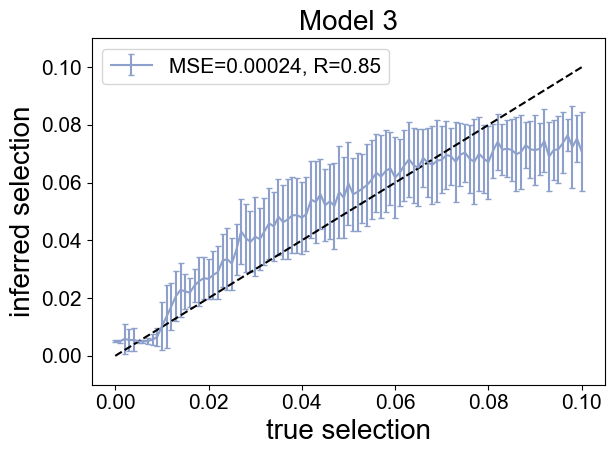

<Figure size 640x480 with 0 Axes>

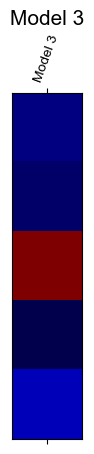

<Figure size 640x480 with 0 Axes>

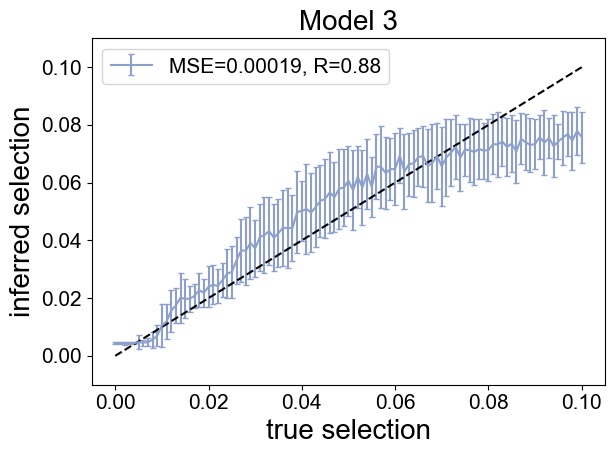

<Figure size 640x480 with 0 Axes>

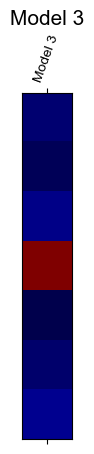

<Figure size 640x480 with 0 Axes>

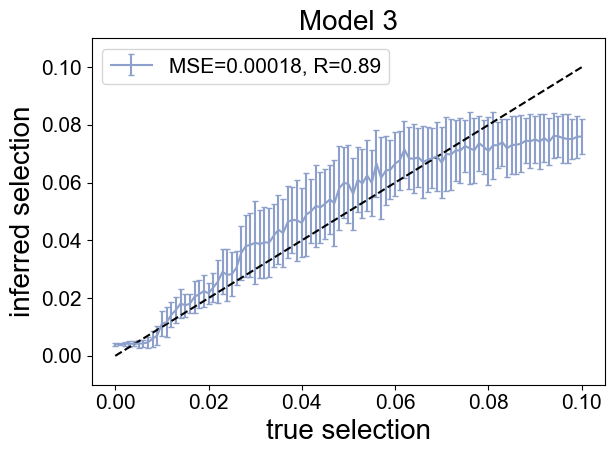

<Figure size 640x480 with 0 Axes>

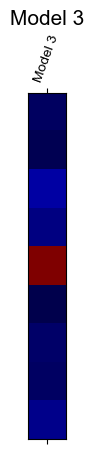

<Figure size 640x480 with 0 Axes>

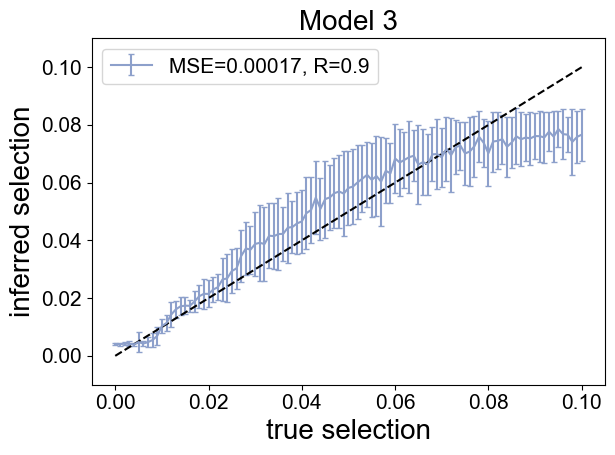

<Figure size 640x480 with 0 Axes>

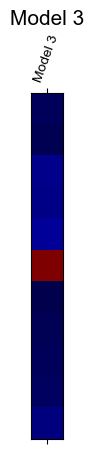

<Figure size 640x480 with 0 Axes>

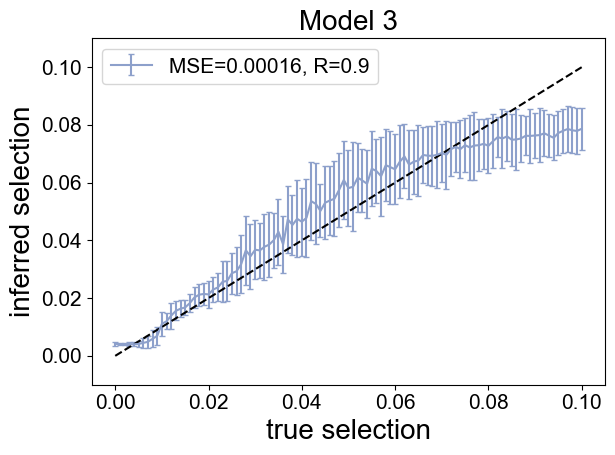

<Figure size 640x480 with 0 Axes>

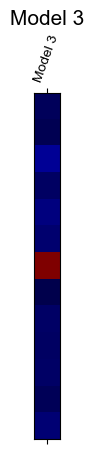

<Figure size 640x480 with 0 Axes>

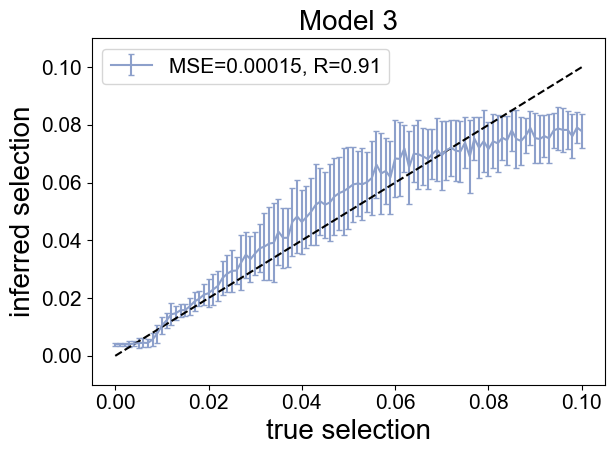

<Figure size 640x480 with 0 Axes>

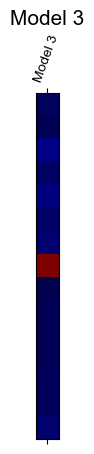

<Figure size 640x480 with 0 Axes>

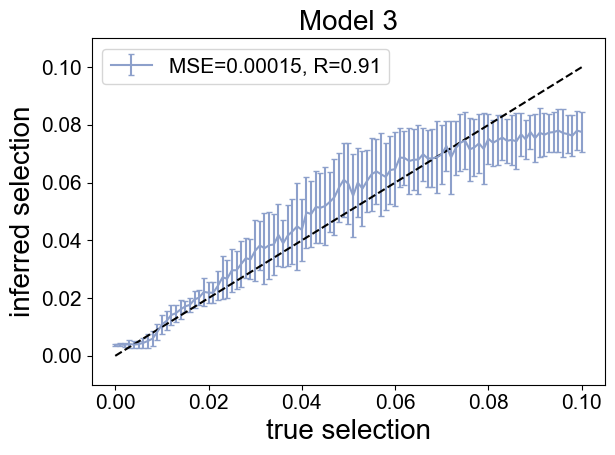

<Figure size 640x480 with 0 Axes>

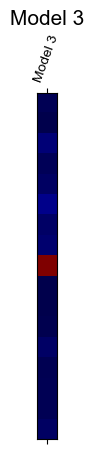

<Figure size 640x480 with 0 Axes>

In [33]:
heatmaps_3 = []
mses_3, Rs_3 = [], []



for no_samples in range(2, 9):
    #plot_abc_accuracy("14Aug", "model_3", "Two-stage direct competition model", no_samples, load_names=['0.4'], var_names=['selection'])
    [h3, mse, R] = plot_abc_accuracy("14Aug", "model_3", "Model 3", no_samples, color="#8da0cb", objective='reg:squarederror', objective_name='MSE', load_names=['0.4'], var_names=['selection'], single_var=True, make_sum_stat_comparison=True)
    heatmaps_3.append(h3)
    mses_3.append(mse)
    Rs_3.append(R)

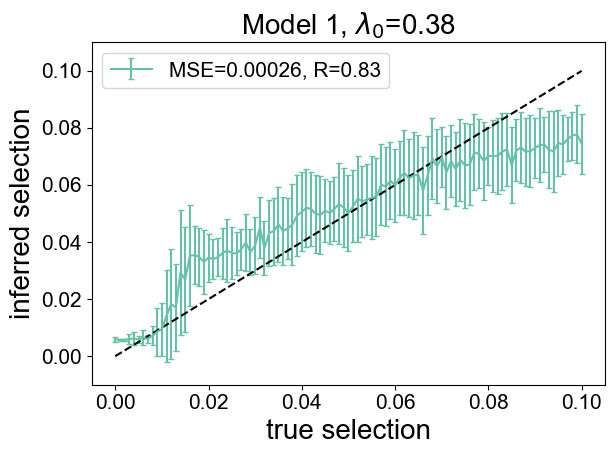

<Figure size 640x480 with 0 Axes>

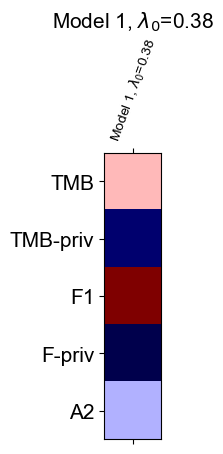

<Figure size 640x480 with 0 Axes>

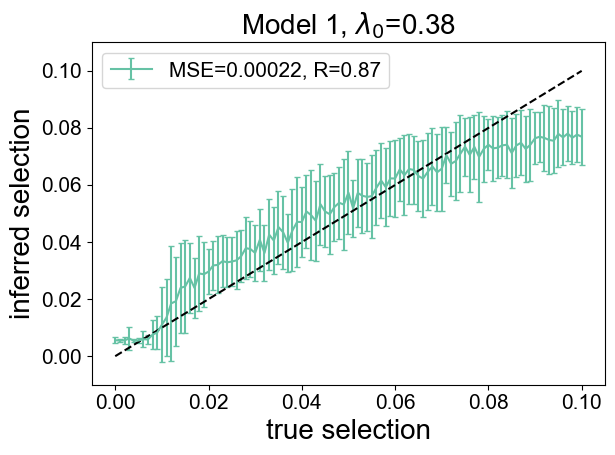

<Figure size 640x480 with 0 Axes>

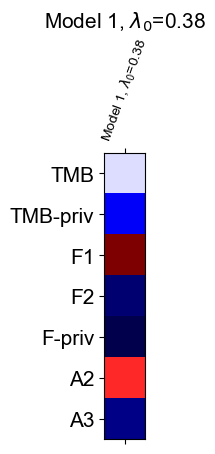

<Figure size 640x480 with 0 Axes>

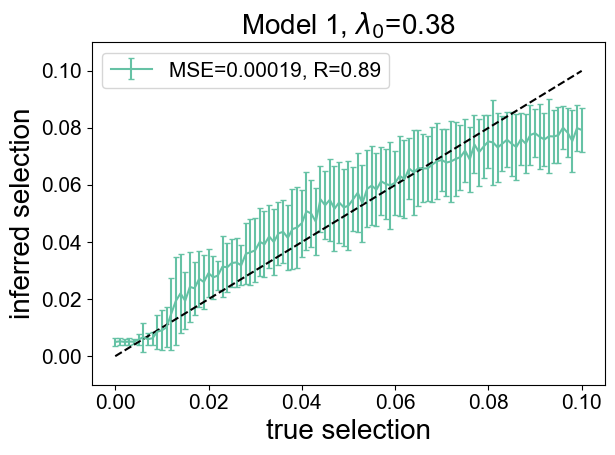

<Figure size 640x480 with 0 Axes>

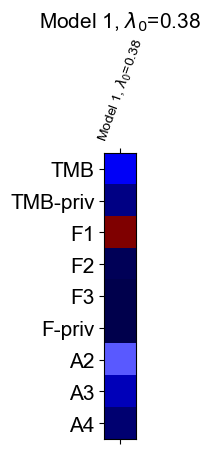

<Figure size 640x480 with 0 Axes>

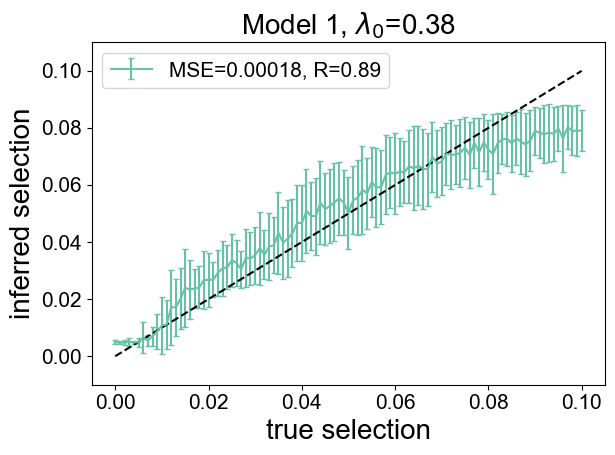

<Figure size 640x480 with 0 Axes>

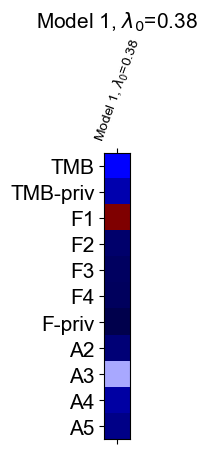

<Figure size 640x480 with 0 Axes>

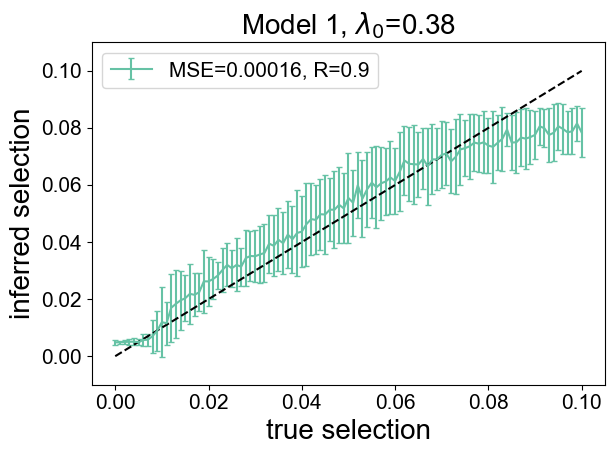

<Figure size 640x480 with 0 Axes>

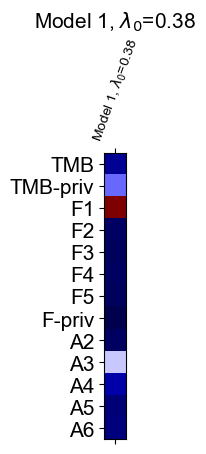

<Figure size 640x480 with 0 Axes>

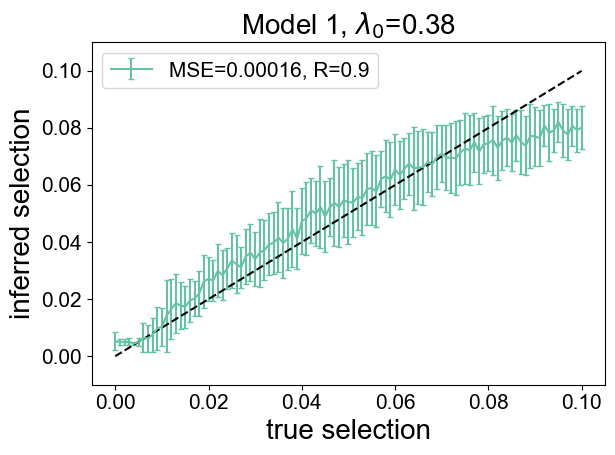

<Figure size 640x480 with 0 Axes>

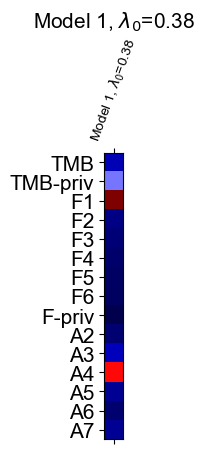

<Figure size 640x480 with 0 Axes>

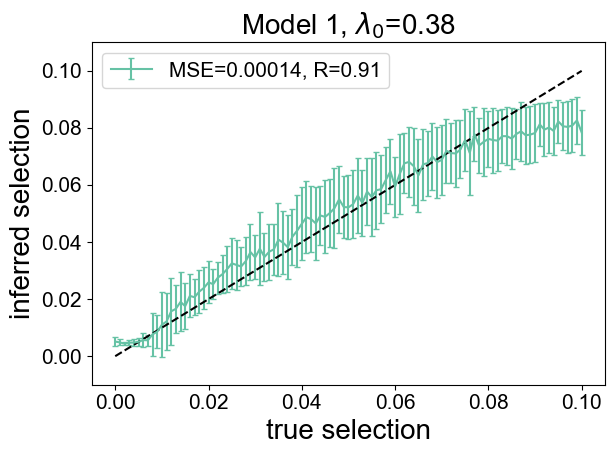

<Figure size 640x480 with 0 Axes>

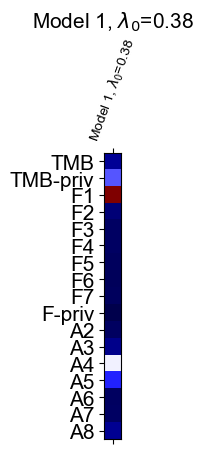

<Figure size 640x480 with 0 Axes>

In [34]:
heatmaps_1 = []
mses_1, Rs_1 = [], []

for no_samples in range(2, 9):
    #plot_abc_accuracy("11Aug", "model_1", "Indirect-competition model (high death)", no_samples, load_names=["highest_death"], var_names=['selection'])
    [h1, mse, R] = plot_abc_accuracy("11Aug", "model_1", "Model 1, "+r'$\lambda_0$'+"=0.38", no_samples, color="#66c2a5", load_names=["highest_death"], var_names=['selection'], objective='reg:squarederror', objective_name='MSE', single_var=True, make_sum_stat_comparison=True, use_yticks=True)
    heatmaps_1.append(h1)
    mses_1.append(mse)
    Rs_1.append(R)

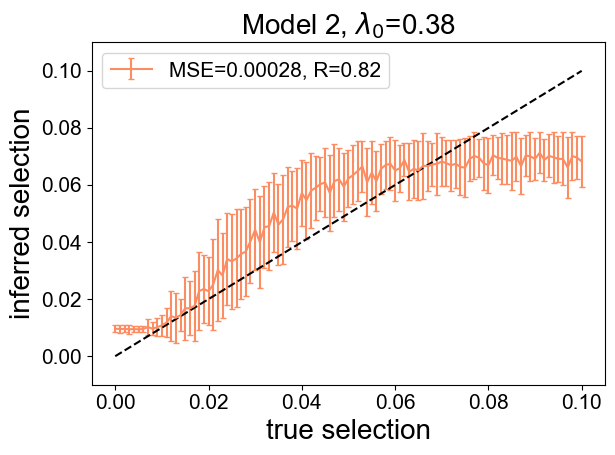

<Figure size 640x480 with 0 Axes>

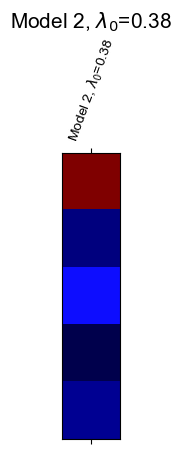

<Figure size 640x480 with 0 Axes>

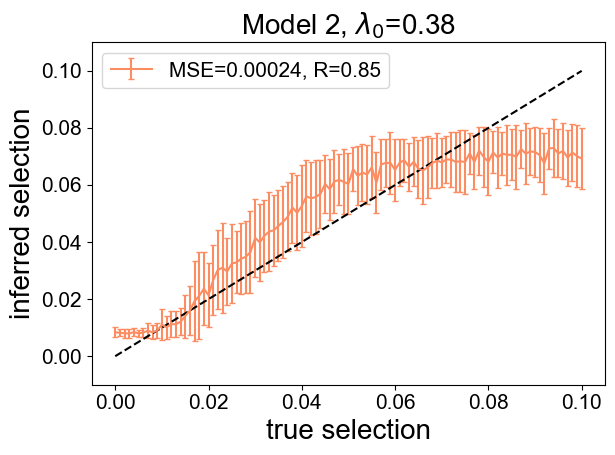

<Figure size 640x480 with 0 Axes>

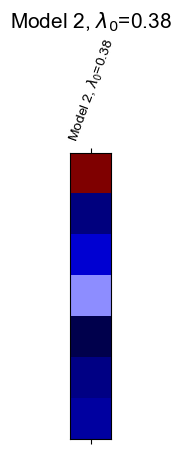

<Figure size 640x480 with 0 Axes>

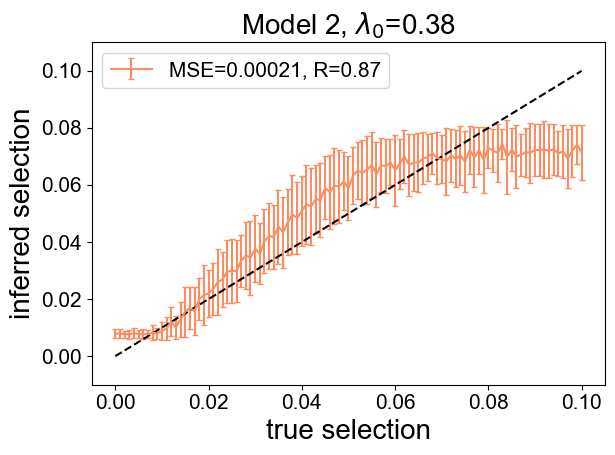

<Figure size 640x480 with 0 Axes>

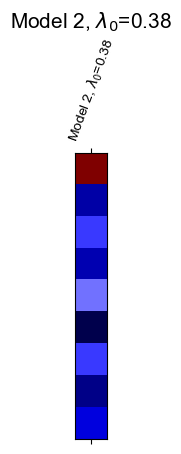

<Figure size 640x480 with 0 Axes>

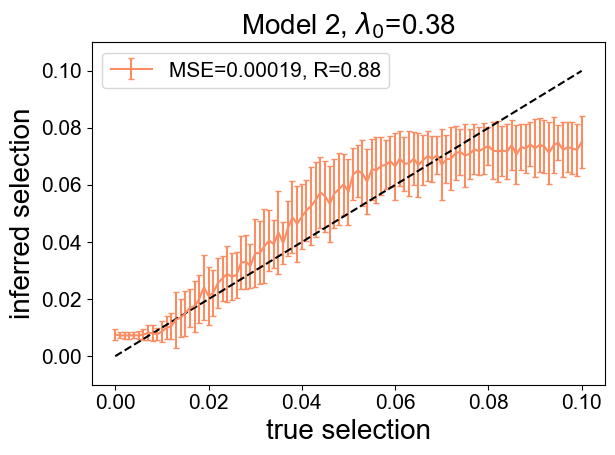

<Figure size 640x480 with 0 Axes>

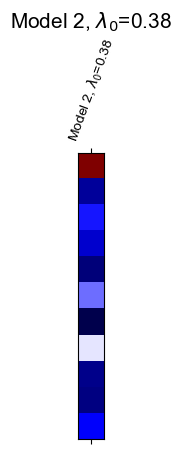

<Figure size 640x480 with 0 Axes>

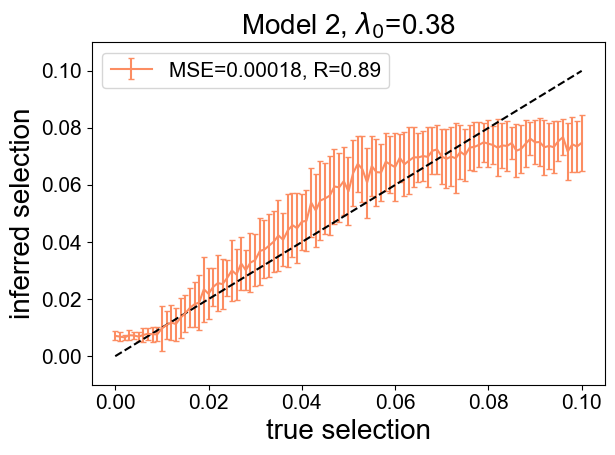

<Figure size 640x480 with 0 Axes>

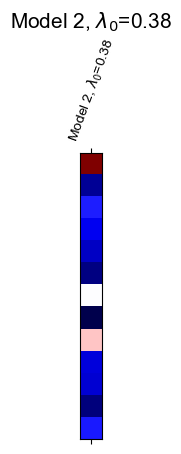

<Figure size 640x480 with 0 Axes>

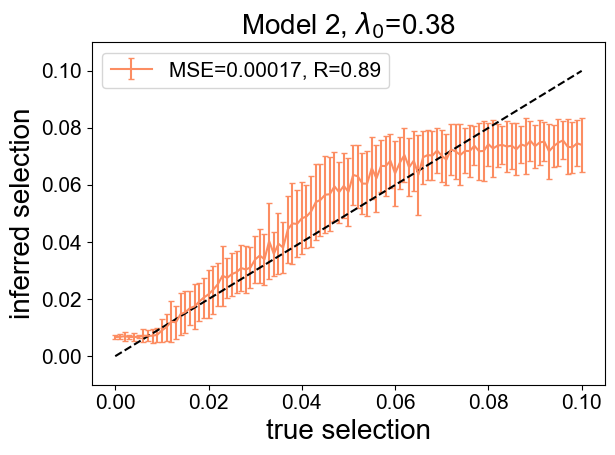

<Figure size 640x480 with 0 Axes>

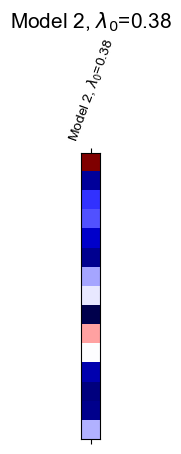

<Figure size 640x480 with 0 Axes>

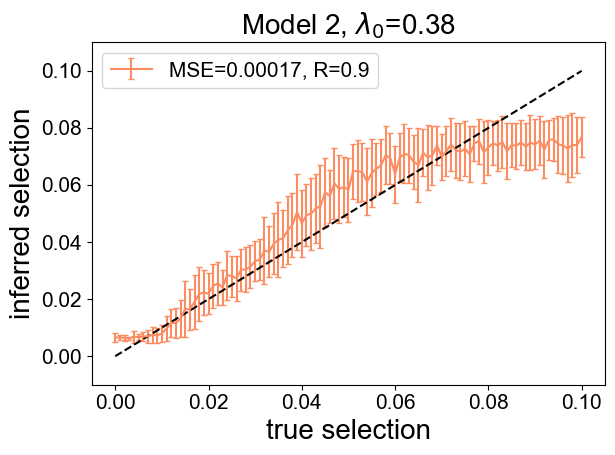

<Figure size 640x480 with 0 Axes>

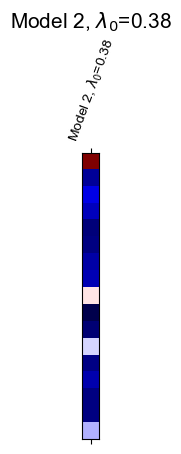

<Figure size 640x480 with 0 Axes>

In [35]:
heatmaps_2 = []
mses_2, Rs_2 = [], []

for no_samples in range(2, 9):
    #plot_abc_accuracy("14Aug", "model_2", "Direct-competition, continual-expansion model", no_samples)
    [h2, mse, R] = plot_abc_accuracy("14Aug", "model_2", "Model 2, "+r'$\lambda_0$'+"=0.38", no_samples, color="#fc8d62", load_names=["highest_death"], var_names=['selection'], objective='reg:squarederror', objective_name='MSE', single_var=True, make_sum_stat_comparison=True)
    heatmaps_2.append(h2)
    mses_2.append(mse)
    Rs_2.append(R)

Now infer selection in TRACERx tumours.

In [38]:
#use ABC to predict selection- assume 1d
def use_abc(model, y_test, y_pred, X_test, input_stats, threshold=0.01):
    num_sims, num_var = y_test.shape
    k = int(threshold*(num_sims-1))+1 #number of simulations to take
    pred_vals = model.predict(input_stats)
    #use L2 error
    dist_from_target = (y_pred - pred_vals)**2 #l2(y_pred_, pred_vals) #L2 distance
    order = np.argpartition(dist_from_target, k) #kth smallest elements will be at position k
    vals, total_error = y_test[order[:k]], np.sum((X_test[order[:k]]-input_stats)**2) #take error as L2 difference between statistics
    inferred_av, inferred_std = np.average(vals), np.std(vals)
    return inferred_av, inferred_std, total_error


In [39]:


patient_index_dict = np.load("patient_index_dict.npy", allow_pickle=True).item() #the index a patient's clinical data is stored in, in the clinical matrix
clinical_var_matrix = np.load("clinical_var_matrix.npy", allow_pickle=True) #clinical data stored at the relevant index

num_samples = np.load("num_samples_by_tumour_name.npy", allow_pickle=True).item() #each patient's ID is the key, the number of relevant samples is the index
#tIDs = np.load("all_tumour_names.npy", allow_pickle=True) #tumour IDs
num_patients = len(clinical_var_matrix)

repeats = 10


assigned_selection = np.zeros((num_patients, repeats, 3, 3)) #record the selection assigned to each patient- along with std and error 

#attributes of each model 

#for each number of samples, train up our model
for r in range(repeats):
    for no_samples in range(2, 9):
        #use 10 90% splits of the training data
        model_1, y_test_1, y_pred_1, X_test_1 = train_model("11Aug", "model_1",  no_samples,  load_names=["highest_death"], objective='reg:squarederror',  single_var=True, test_size=0.9)
        model_2, y_test_2, y_pred_2, X_test_2 = train_model("14Aug", "model_2",  no_samples, load_names=["highest_death"], objective='reg:squarederror',  single_var=True, test_size=0.9)
        model_3, y_test_3, y_pred_3, X_test_3 = train_model("14Aug", "model_3",  no_samples, load_names=['0.4'], objective='reg:squarederror', single_var=True, test_size=0.9)

        models, y_tests, y_preds, X_tests = [model_1, model_2, model_3], [y_test_1, y_test_2, y_test_3], [y_pred_1, y_pred_2, y_pred_3], [X_test_1, X_test_2, X_test_3]
        
        for tumour_name, rel_index in patient_index_dict.items(): #go through each tumour
            num_regions = num_samples[tumour_name] #patient-index is the more restrictive dictionary
            if num_regions == no_samples:
                rel_index = patient_index_dict[tumour_name]
                input_stats = np.array([np.load(stats_filepath+"/"+tumour_name+"_ss_4424.npy", allow_pickle=True)])
                for m in range(3):
                    av, std, total_error = use_abc(models[m], y_tests[m], y_preds[m], X_tests[m], input_stats)
                    assigned_selection[rel_index][r][m] = [av, std, total_error]

np.save("cruk_assigned_selection_with_models.npy", assigned_selection)



In [40]:
patient_index_dict = np.load("patient_index_dict.npy", allow_pickle=True).item() #the index a patient's clinical data is stored in, in the clinical matrix
clinical_var_matrix = np.load("clinical_var_matrix.npy", allow_pickle=True) #clinical data stored at the relevant index

num_samples = np.load("num_samples_by_tumour_name.npy", allow_pickle=True).item() #each patient's ID is the key, the number of relevant samples is the index
#tIDs = np.load("all_tumour_names.npy", allow_pickle=True) #tumour IDs
num_patients = len(clinical_var_matrix)

repeats = 10

assigned_selection = np.load("cruk_assigned_selection_with_models.npy", allow_pickle=True) #these are ordered in the same way as the clinical matrix

combined_selections = np.zeros((num_patients, 3, 3))
for n in range(num_patients):
    for m in range(3):
        avs, stds, errors = assigned_selection[n, :, m, 0], assigned_selection[n, :, m, 1], assigned_selection[n, :, m, 2]
        combined_selections[n][m][0] = np.average(avs)
        combined_selections[n][m][1] = np.sqrt(np.sum(stds**2)/repeats) #average STD
        combined_selections[n][m][2] = np.average(errors) #average total error in models
        



C:\Users\44749\Anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)
C:\Users\44749\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


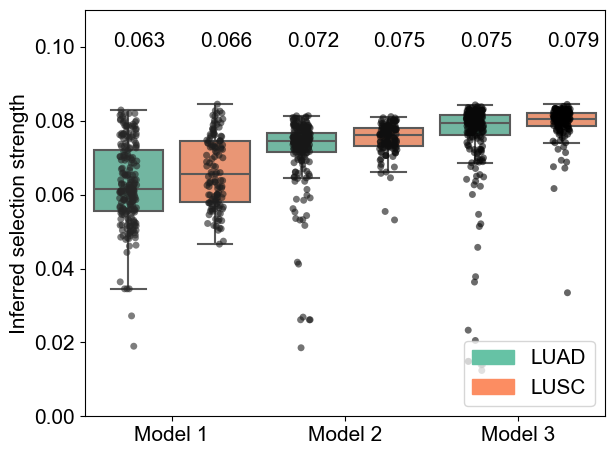

1 v 2 diff 2.720742757505097e-51
2 v 3 diff 2.7009313864021296e-29
3 v 1 diff 3.4271085509332045e-66
1 v 2 diff- LUAD 7.6248426835142015e-28
2 v 3 diff- LUAD 2.0646781379885578e-12
3 v 1 diff- LUAD 7.44770552170703e-33
1 v 2 diff- LUSC 4.5638312618735986e-18
2 v 3 diff- LUSC 2.064911773673908e-19
3 v 1 diff- LUSC 3.3985638058689114e-29


<Figure size 640x480 with 0 Axes>

In [41]:
title_offset=-0.17

#split by LUAD and LUSC
luad_idx = np.where(clinical_var_matrix[:, 2]==0)[0]
lusc_idx = np.where(clinical_var_matrix[:, 2]==1)[0]

#plot three things: one, the distribution of inferred selection levels, in absolute terms- take averages
#then the per-model differences
fig, ax = plt.subplots()
#violinparts = ax.violinplot([combined_selections[:, 0, 0], combined_selections[:, 1, 0], combined_selections[:, 2, 0]], showmeans=True, showextrema=False)
data = [ combined_selections[luad_idx, 0, 0], combined_selections[lusc_idx, 0, 0], 
            combined_selections[luad_idx, 1, 0],combined_selections[lusc_idx, 1, 0], #
                combined_selections[luad_idx, 2, 0], combined_selections[lusc_idx, 2, 0]]
luad_patch = mpl.patches.Patch(color="#66c2a5", label="LUAD")
lusc_patch = mpl.patches.Patch(color="#fc8d62", label="LUSC")
sns.boxplot(data=data,  palette=["#66c2a5", "#fc8d62"]*3, showfliers=False)
sns.stripplot(data=data, color='black', alpha=0.6, jitter=True)
ax.set_xticks([0.5, 2.5, 4.5], ["Model 1", "Model 2", "Model 3"])
ax.legend(handles=[luad_patch, lusc_patch], loc="lower right")
ax.text(title_offset, 0.1, str(np.around(np.average(combined_selections[luad_idx, 0, 0]), decimals=3)))
ax.text(2+title_offset, 0.1, str(np.around(np.average(combined_selections[luad_idx, 1, 0]), decimals=3)))
ax.text(4+title_offset, 0.1, str(np.around(np.average(combined_selections[luad_idx, 2, 0]), decimals=3)))
ax.text(1+title_offset, 0.1, str(np.around(np.average(combined_selections[lusc_idx, 0, 0]), decimals=3)))
ax.text(3+title_offset, 0.1, str(np.around(np.average(combined_selections[lusc_idx, 1, 0]), decimals=3)))
ax.text(5+title_offset, 0.1, str(np.around(np.average(combined_selections[lusc_idx, 2, 0]), decimals=3)))
plt.ylim(0, 0.11)
plt.ylabel("Inferred selection strength")
plt.tight_layout()
plt.show()
fig.savefig(base_filepath+"/figs_1410/tracerx_absolute_predictions.pdf", dpi=300)
plt.clf()

print("1 v 2 diff", ttest_1samp(combined_selections[:, 0, 0]-combined_selections[:, 1, 0], 0).pvalue)
print("2 v 3 diff", ttest_1samp(combined_selections[:, 1, 0]-combined_selections[:, 2, 0], 0).pvalue)
print("3 v 1 diff", ttest_1samp(combined_selections[:, 2, 0]-combined_selections[:, 0, 0], 0).pvalue)

#LUAD ONLY
print("1 v 2 diff- LUAD", ttest_1samp(combined_selections[luad_idx, 0, 0]-combined_selections[luad_idx, 1, 0], 0).pvalue)
print("2 v 3 diff- LUAD", ttest_1samp(combined_selections[luad_idx, 1, 0]-combined_selections[luad_idx, 2, 0], 0).pvalue)
print("3 v 1 diff- LUAD", ttest_1samp(combined_selections[luad_idx, 2, 0]-combined_selections[luad_idx, 0, 0], 0).pvalue)

#LUSC ONLY
print("1 v 2 diff- LUSC", ttest_1samp(combined_selections[lusc_idx, 0, 0]-combined_selections[lusc_idx, 1, 0], 0).pvalue)
print("2 v 3 diff- LUSC", ttest_1samp(combined_selections[lusc_idx, 1, 0]-combined_selections[lusc_idx, 2, 0], 0).pvalue)
print("3 v 1 diff- LUSC", ttest_1samp(combined_selections[lusc_idx, 2, 0]-combined_selections[lusc_idx, 0, 0], 0).pvalue)
